<div style="
    background-color:#2C3E50;
    padding:30px;
    text-align:center;
    border-radius:5px;
">
    <h1 style="
        color:#ECF0F1;
        font-size:36px;
        letter-spacing:2px;
        margin:0;
    ">
        Salary Range Prediction
    </h1>
</div>

#### ---------------------------------------------------------------------------------------------------------------------------------------------------------

<div style="
    border:2px dashed #B0B0B0;
    padding:20px 25px;
    margin:20px 0;
    background-color:#F9F9F9;
">

<b>Problem Statement:</b>  
The project aims to develop a machine learning-based predictive model for estimating salary ranges for job listings as part of efforts to improve and revolutionize talent management. Using historical job posting data, the model predicts both the minimum and maximum annual salary for a given job posting based on factors such as job title, experience, education, career level, job category, agency, and work location.
<br><br>


<b>Project Benefits:</b>  
- Enhanced Recruitment Process: Accurate salary predictions help recruiters align job postings with appropriate salary ranges, attract suitable candidates, and optimize hiring costs.
- Improved Candidate Experience: Providing clear salary expectations upfront increases transparency, improves candidate engagement, and supports better hiring decisions.
- Strategic Decision-Making: Reliable salary predictions help HR teams and organizational leaders make informed decisions about salary budgets, workforce planning, and resource allocation

<b>Deliverables:</b>  
- Predictive Model: Develop a machine learning algorithm capable of forecasting minimum and maximum salary ranges based on job attributes such as title, category, and location.
- Documentation: Prepare comprehensive documentation outlining the methodology, data sources, and technical specifications of the predictive model.
</div>

<div style="
    border:2px dashed #B0B0B0;
    padding:22px 28px;
    margin:25px 0;
    background-color:#FAFAFA;
">


<p>Here is a brief description of each column used in the Salary Range Prediction dataset:</p>

<ol>


| Feature                           | Description                                                                                         |
| --------------------------------- | --------------------------------------------------------------------------------------------------- |
| **Job ID**                        | A unique identifier assigned to each job posting for tracking and managing job listings.            |
| **Agency**                        | The agency responsible for managing city employees and providing support services to city agencies. |
| **Posting Type**                  | Indicates whether the posting is for a new position, transfer, or promotional opportunity.          |
| **# Of Positions**                | Number of available positions for the job.                                                          |
| **Business Title**                | Official job title used by the city.                                                                |
| **Civil Service Title**           | Job title classification based on civil service regulations.                                        |
| **Title Classification**          | Further categorization of the job title.                                                            |
| **Title Code No**                 | Unique code associated with the job title.                                                          |
| **Level**                         | Level or rank of the position.                                                                      |
| **Job Category**                  | Broad field or category of the job, such as administration, finance, or law enforcement.            |
| **Full-Time/Part-Time Indicator** | Specifies whether the position is full-time or part-time.                                           |
| **Career Level**                  | Indicates the career stage, such as entry-level, mid-level, or senior.                              |
| **Salary Range From**             | Minimum salary offered for the position.                                                            |
| **Salary Range To**               | Maximum salary offered for the position.                                                            |
| **Salary Frequency**              | Indicates how frequently the salary is paid, such as annually or monthly.                           |
| **Work Location**                 | Physical location where the position is based.                                                      |
| **Division/Work Unit**            | Specific department or work unit within the agency.                                                 |
| **Job Description**               | Summary of the responsibilities and duties associated with the position.                            |
| **Minimum Qual Requirements**     | Qualifications or criteria required for applicants to be eligible.                                  |
| **Preferred Skills**              | Additional skills or qualifications that are desirable but not mandatory.                           |
| **Additional Information**        | Other relevant information related to the job posting.                                              |
| **To Apply**                      | Instructions provided for applying to the position.                                                 |
| **Hours/Shift**                   | Information about working hours or shifts.                                                          |
| **Recruitment Contact**           | Contact information for recruitment-related inquiries.                                              |
| **Residency Requirement**         | Specifies whether applicants must be residents of New York City.                                    |
| **Posting Date**                  | Date when the job posting was published.                                                            |
| **Post Until**                    | Deadline for submitting applications.                                                               |
| **Posting Updated**               | Date when the job posting was last updated.                                                         |
| **Process Date**                  | Date when the data was processed or recorded.                                                       |


<div style="
    border:2px dashed #B0B0B0;
    padding:20px 28px;
    margin:25px 0;
    background-color:#FAFAFA;
">

<h3 style="margin-top:0;">📌 Task</h3>

- Improve salary benchmarking by accurately estimating the expected salary range for job positions.

- Support recruitment planning by helping organizations set competitive and realistic salary ranges.
  
- Optimize hiring budgets by providing data-driven salary estimates before recruiting.
  
- Increase salary transparency by providing a consistent estimated range for job listings.
  
- Support workforce planning by helping HR teams make better compensation and resource-allocation decisions.
<p>

</p>

</div>

<div style="
    border:2px dashed #B0B0B0;
    padding:20px 28px;
    margin:25px 0;
    background-color:#FAFAFA;
">

<h3 style="margin-top:0;">📊 Evaluation</h3>

<p>
Submissions are evaluated using the <b> R2 score(Coefficient of Determination) </b>, which measures how well the model explains the variation in Salary Ranges . Higher R² values indicate better predictive performance.
</p>

</div>

<hr style="border-top:2px dashed #9A9A9A; margin:30px 0;">

<h1>Import Necessary Libraries</h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split,GridSearchCV, KFold, cross_val_score
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

<h1> Load the Dataset</h1>

In [2]:
df = pd.read_csv("C:/Users/conne/Downloads/Jobs_NYC_Postings.csv")

In [3]:
pd.set_option('display.max_columns', None)
df

,Job ID,Agency,Posting Type,# Of Positions,Business Title,Civil Service Title,Title Classification,Title Code No,Level,Job Category,Full-Time/Part-Time indicator,Career Level,Salary Range From,Salary Range To,Salary Frequency,Work Location,Division/Work Unit,Job Description,Minimum Qual Requirements,Preferred Skills,Additional Information,To Apply,Hours/Shift,Work Location 1,Recruitment Contact,Residency Requirement,Posting Date,Post Until,Posting Updated,Process Date
0,623668,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"Research Analyst, IMAT, Bureau of Maternal Inf...",CITY RESEARCH SCIENTIST,Non-Competitive-5,21744,02,Constituent Services & Community Programs Heal...,F,Experienced (non-manager),82506.0,94882.0,Annual,42-09 28th Street,"Maternal, Infant, & Repr. Hlth","Established in 1805, the New York City Departm...","1. For Assignment Level I (only physical, bio...",Experience in quantitative research methods an...,**IMPORTANT NOTES TO ALL CANDIDATES: Please n...,Apply online with a cover letter to https://a1...,NaN,NaN,NaN,New York City residency is generally required ...,01/23/2024,22-MAY-2024,01/23/2024,03/04/2024
1,608193,DEPT OF DESIGN & CONSTRUCTION,Internal,1,Deputy Director,ADMINISTRATIVE PROJECT MANAGER,Competitive-1,8300B,00,"Policy, Research & Analysis Public Safety, Ins...",F,Experienced (non-manager),58682.0,134570.0,Annual,30-30 Thomson Ave L I City Qns,Pub Bldgs/Transportation,Hours: Full-Time â 35 Hours Work Location: 3...,1. A baccalaureate degree from an accredited c...,Candidates must have excellent management skil...,Authorization to work in the United States is ...,"For City Employees, please go to Employee Self...",35 Hours,"30-30 Thomson Avenue, LIC, NY 11101",NaN,New York City Residency is not required for th...,10/03/2023,NaN,11/29/2023,03/04/2024
2,625094,DEPT OF DESIGN & CONSTRUCTION,Internal,1,Senior Project Manager,ADMINISTRATIVE PROJECT MANAGER,Competitive-1,8300B,00,"Engineering, Architecture, & Planning",F,Experienced (non-manager),58682.0,91405.0,Annual,30-30 Thomson Ave L I City Qns,PUB BLDGS/CPD/Library/Brooklyn,Hours: Full-Time â 35 Hours Work Location: 3...,1. A baccalaureate degree from an accredited c...,Candidates should have at least six years of e...,NaN,NaN,NaN,NaN,NaN,New York City Residency is not required for th...,02/01/2024,NaN,02/01/2024,03/04/2024
3,580593,DEPARTMENT OF TRANSPORTATION,External,1,Procurement Analyst 2,PROCUREMENT ANALYST,Competitive-1,12158,02,"Finance, Accounting, & Procurement",F,Experienced (non-manager),50972.0,82730.0,Annual,55 Water St Ny Ny,Bridge Repair/352 Kent St,Reporting directly to the Director of Bridge R...,1. A baccalaureate degree from an accredited c...,Familiar with and knowledge of Procurement sys...,The City of New York is an inclusive equal opp...,Resumes may be submitted electronically using ...,9:00am â 5:00pm,To be determine.,NaN,New York City residency is generally required ...,04/04/2023,NaN,04/04/2023,03/04/2024
4,624937,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"Deputy Director, HIV Planning Council, Divisio...",CITY RESEARCH SCIENTIST,Non-Competitive-5,21744,03,Constituent Services & Community Programs Heal...,F,Experienced (non-manager),92301.0,106146.0,Annual,42-09 28th Street,Dis-Div. Mgmt. & Sys Coord,"Established in 1805, the New York City Departm...","1. For Assignment Level I (only physical, bio...",At least five yearsâ work experience in the ...,NaN,Apply online with a cover letter to https://a1...,NaN,NaN,NaN,New York City residency is generally required ...,02/06/2024,05-JUN-2024,02/21/2024,03/04/2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5115,570670,DEPT OF HEALTH/MENTAL HYGIENE,External,1,Public Health Nurse III / Communicable Disease...,PUBLIC HEALTH NURSE,Competitive-1,51011,03,Constituent Services & Community Programs Health,F,Experienced (non-manager),84252.0,84252.0,Annual,30-30 47TH AVE,SH Nursing Services & Prof Dev,*** 

In [4]:
# Explore the dataset structure and data types
df.describe(include='all')

,Job ID,Agency,Posting Type,# Of Positions,Business Title,Civil Service Title,Title Classification,Title Code No,Level,Job Category,Full-Time/Part-Time indicator,Career Level,Salary Range From,Salary Range To,Salary Frequency,Work Location,Division/Work Unit,Job Description,Minimum Qual Requirements,Preferred Skills,Additional Information,To Apply,Hours/Shift,Work Location 1,Recruitment Contact,Residency Requirement,Posting Date,Post Until,Posting Updated,Process Date
count,5120.000000,5120,5120,5120.000000,5120,5120,5120,5120,5120,5120,5003,5120,5120.000000,5120.000000,5120,5120,5120,5120,5077,3901,3258,4694,1910,1891,0.0,5120,5120,1504,5120,5120
unique,NaN,59,2,NaN,1781,365,5,388,18,183,2,5,NaN,NaN,3,293,852,2518,445,1639,780,1332,315,268,NaN,80,448,158,404,1
top,NaN,DEPT OF ENVIRONMENT PROTECTION,Internal,NaN,Project Manager,COMMUNITY COORDINATOR,Competitive-1,56058,00,"Engineering, Architecture, & Planning",F,Experienced (non-manager),NaN,NaN,Annual,30-30 Thomson Ave L I City Qns,FIA Operations-NM,1.\tDrive development vehicles and assist in d...,1. A baccalaureate degree from an accredited c...,â¢ Experience with Welfare Management System ...,Authorization to work in the United States is ...,Click the Apply Now button.,35 Hours,55 Water St Ny Ny,NaN,New York City residency is generally required ...,09/29/2023,13-MAR-2024,02/27/2024,03/04/2024
freq,NaN,932,2612,NaN,63,269,3334,269,2107,785,4841,3846,NaN,NaN,4686,434,146,16,269,28,120,170,299,204,NaN,2789,94,78,122,5120
mean,598721.366211,NaN,NaN,2.070898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64625.224123,89978.575734,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,28274.636161,NaN,NaN,5.799227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31378.516179,46732.299939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,469953.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,586358.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51869.000000,64608.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,607060.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,62397.000000,85147.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,621404.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80557.000000,113550.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5120 entries, 0 to 5119
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Job ID                         5120 non-null   int64  
 1   Agency                         5120 non-null   object 
 2   Posting Type                   5120 non-null   object 
 3   # Of Positions                 5120 non-null   int64  
 4   Business Title                 5120 non-null   object 
 5   Civil Service Title            5120 non-null   object 
 6   Title Classification           5120 non-null   object 
 7   Title Code No                  5120 non-null   object 
 8   Level                          5120 non-null   object 
 9   Job Category                   5120 non-null   object 
 10  Full-Time/Part-Time indicator  5003 non-null   object 
 11  Career Level                   5120 non-null   object 
 12  Salary Range From              5120 non-null   f

<h1> Data Preprocessing</h1>

In [6]:
# Check for missing values in each column
df.isnull().sum()

Job ID                              0
Agency                              0
Posting Type                        0
# Of Positions                      0
Business Title                      0
Civil Service Title                 0
Title Classification                0
Title Code No                       0
Level                               0
Job Category                        0
Full-Time/Part-Time indicator     117
Career Level                        0
Salary Range From                   0
Salary Range To                     0
Salary Frequency                    0
Work Location                       0
Division/Work Unit                  0
Job Description                     0
Minimum Qual Requirements          43
Preferred Skills                 1219
Additional Information           1862
To Apply                          426
Hours/Shift                      3210
Work Location 1                  3229
Recruitment Contact              5120
Residency Requirement               0
Posting Date

In [7]:
missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data[missing_data['Missing Count'] > 0].sort_values(
    by='Missing Percentage',
    ascending=False
)

,Missing Count,Missing Percentage
Recruitment Contact,5120,100.000000
Post Until,3616,70.625000
Work Location 1,3229,63.066406
Hours/Shift,3210,62.695312
Additional Information,1862,36.367188
Preferred Skills,1219,23.808594
To Apply,426,8.320312
Full-Time/Part-Time indicator,117,2.285156
Minimum Qual Requirements,43,0.839844


In [8]:
df = df.drop(columns=['Recruitment Contact'])

In [9]:
df[['Work Location', 'Work Location 1']].head(10)

,Work Location,Work Location 1
0,42-09 28th Street,NaN
1,30-30 Thomson Ave L I City Qns,"30-30 Thomson Avenue, LIC, NY 11101"
2,30-30 Thomson Ave L I City Qns,NaN
3,55 Water St Ny Ny,To be determine.
4,42-09 28th Street,NaN
5,"33 Beaver St, New York Ny","33 Beaver St, New York NY"
6,59-17 Junction Blvd Corona Ny,59-17 Junction Blvd Corona NY 11373
7,100 Gold Street,NaN
8,"1 Centre St., N.Y.",NaN
9,15 Metrotech,NaN


In [10]:
df = df.drop(columns=['Work Location 1'])

In [11]:
# Identify and remove duplicate records
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 19


In [12]:
df[df.duplicated(keep=False)].sort_values(
    by='Job ID'
)

,Job ID,Agency,Posting Type,# Of Positions,Business Title,Civil Service Title,Title Classification,Title Code No,Level,Job Category,Full-Time/Part-Time indicator,Career Level,Salary Range From,Salary Range To,Salary Frequency,Work Location,Division/Work Unit,Job Description,Minimum Qual Requirements,Preferred Skills,Additional Information,To Apply,Hours/Shift,Residency Requirement,Posting Date,Post Until,Posting Updated,Process Date
4352,539278,BRONX DISTRICT ATTORNEY,Internal,15,Homicide Assistant District Attorney,ASSISTANT DISTRICT ATTORNEY (S,Exempt-4,30114,00,"Legal Affairs Public Safety, Inspections, & En...",F,Experienced (non-manager),120000.0,167610.0,Annual,198 E161St Street Bronx N.Y.,Homicide-Legal Staff,The Bronx District Attorney is committed to se...,Juris Doctor degree required Minimum of 7 yea...,NaN,NaN,We appreciate your interest in a position with...,NaN,New York State Residency is REQUIRED on first ...,07/11/2022,27-DEC-2024,11/08/2023,03/04/2024
4351,539278,BRONX DISTRICT ATTORNEY,Internal,15,Homicide Assistant District Attorney,ASSISTANT DISTRICT ATTORNEY (S,Exempt-4,30114,00,"Legal Affairs Public Safety, Inspections, & En...",F,Experienced (non-manager),120000.0,167610.0,Annual,198 E161St Street Bronx N.Y.,Homicide-Legal Staff,The Bronx District Attorney is committed to se...,Juris Doctor degree required Minimum of 7 yea...,NaN,NaN,We appreciate your interest in a position with...,NaN,New York State Residency is REQUIRED on first ...,07/11/2022,27-DEC-2024,11/08/2023,03/04/2024
376,542360,BRONX DISTRICT ATTORNEY,Internal,5,ADA - Senior Homicide Counsel,ASSISTANT DISTRICT ATTORNEY (S,Exempt-4,30114,00,"Legal Affairs Public Safety, Inspections, & En...",F,Experienced (non-manager),0.0,180000.0,Annual,198 E161St Street Bronx N.Y.,Homicide-Legal Staff,The Bronx District Attorney is committed to se...,NaN,NaN,**LOAN FORGIVENESS: The federal government pro...,We appreciate the interest and thank all appli...,NaN,New York State Residency is REQUIRED on the fi...,07/25/2022,10-JAN-2025,11/08/2023,03/04/2024
377,542360,BRONX DISTRICT ATTORNEY,Internal,5,ADA - Senior Homicide Counsel,ASSISTANT DISTRICT ATTORNEY (S,Exempt-4,30114,00,"Legal Affairs Public Safety, Inspections, & En...",F,Experienced (non-manager),0.0,180000.0,Annual,198 E161St Street Bronx N.Y.,Homicide-Legal Staff,The Bronx District Attorney is committed to se...,NaN,NaN,**LOAN FORGIVENESS: The federal government pro...,We appreciate the interest and thank all appli...,NaN,New York State Residency is REQUIRED on the fi...,07/25/2022,10-JAN-2025,11/08/2023,03/04/2024
2546,578057,DEPT OF ENVIRONMENT PROTECTION,Internal,1,Director of Procurement,ADMINISTRATIVE STAFF ANALYST (,Competitive-1,1002D,00,"Finance, Accounting, & Procurement",F,Manager,94715.0,136260.0,Annual,59-17 Junction Blvd Corona Ny,ADMINISTRATION,The NYC Department of Environmental Protection...,1. A master's degree from an accredited colleg...,â¢\tExtensive knowledge of the procurement/co...,Appointments are subject to OMB approval. For...,To apply click the Apply Now button,35 hours per week,New York City residency is generally required ...,03/14/2023,NaN,02/26/2024,03/04/2024
2545,578057,DEPT OF ENVIRONMENT PROTECTION,Internal,1,Director of Procurement,ADMINISTRATIVE STAFF ANALYST (,Competitive-1,1002D,00,"Finance, Accounting, & Procurement",F,Manager,94715.0,136260.0,Annual,59-17 Junction Blvd Corona Ny,ADMINISTRATION,The NYC Department of Environmental Protection...,1. A master's degree from an accredited colleg...,â¢\tExtensive knowledge of the procurement/co...,Appointments are subject to OMB approval. For...,To apply click the Apply Now button,35 hours per week,New York City residency is generally required ...,03/14/2023,NaN,02/26/2024,03/04/2024
3399,584407,DEPT OF ENVIRONMENT PROTECTION,Internal,1,Procurement Liaison,PROCUREMENT ANALYST,Competitive-1,12158,02,"Finance, Accounting, & Procurement",NaN,Entry-Level,50972.0,82730.0,Annual,59-17 Junction Blvd Corona Ny,ADMINISTRA

In [13]:
df = df.drop_duplicates().reset_index(drop=True)

In [14]:
print("Duplicate rows after cleaning:", df.duplicated().sum())
print("New shape:", df.shape)

Duplicate rows after cleaning: 0
New shape: (5101, 28)


In [15]:
text_columns = [
    'Additional Information',
    'Preferred Skills',
    'To Apply',
    'Full-Time/Part-Time indicator',
    'Minimum Qual Requirements'
]

df[text_columns] = df[text_columns].fillna('Not Specified')

In [16]:
df['Post Until'].value_counts(dropna=False).head(20)

Post Until
NaN            3607
13-MAR-2024      78
05-MAR-2024      69
29-MAR-2024      45
16-MAR-2024      43
19-MAR-2024      43
25-MAR-2024      42
27-APR-2024      32
14-MAR-2024      31
17-MAR-2024      29
15-MAR-2024      29
24-MAR-2024      25
22-MAR-2024      25
30-MAR-2024      24
11-MAR-2024      24
10-MAR-2024      23
08-MAR-2024      23
18-MAR-2024      22
27-MAR-2024      22
05-APR-2024      22
Name: count, dtype: int64

In [17]:
df[['Posting Date', 'Post Until']].head(20)

,Posting Date,Post Until
0,01/23/2024,22-MAY-2024
1,10/03/2023,NaN
2,02/01/2024,NaN
3,04/04/2023,NaN
4,02/06/2024,05-JUN-2024
5,03/04/2024,NaN
6,01/02/2024,NaN
7,02/23/2024,24-MAR-2024
8,09/28/2023,NaN
9,09/01/2023,NaN


In [18]:
df = df.drop(columns=['Post Until'])

In [19]:
df['Hours/Shift'].value_counts(dropna=False).head(20)

Hours/Shift
NaN                                                                                    3201
35 Hours                                                                                297
35 hours per week/day                                                                   127
35hrs                                                                                    77
35 hours per week                                                                        64
35 hours                                                                                 46
35 hours per week/day (Non-trade titles), 40 hours per week/day (Trade titles only)      44
35 hours Weekly/Day.                                                                     42
Monday â Friday                                                                        40
Unless otherwise indicated, all positions require a five-day workweek.                   38
Normal Business Hours                                               

In [20]:
df[['Hours/Shift']].dropna().head(10)

,Hours/Shift
1,35 Hours
3,9:00am â 5:00pm
9,Normal Business Hours
10,40 hours/Monday-Friday
12,"Unless otherwise indicated, all positions requ..."
15,40 Hours per week / may be required to work sh...
18,9:00am - 5:00pm Monday â Friday; with 30 Min...
19,35 Hours
20,9:00a- 5:00p
21,35 hours per week/day


In [21]:
df = df.drop(columns=['Hours/Shift'])

In [22]:
# Check unique value counts
df.nunique()

Job ID                           2626
Agency                             59
Posting Type                        2
# Of Positions                     35
Business Title                   1781
Civil Service Title               365
Title Classification                5
Title Code No                     388
Level                              18
Job Category                      183
Full-Time/Part-Time indicator       3
Career Level                        5
Salary Range From                 559
Salary Range To                   748
Salary Frequency                    3
Work Location                     293
Division/Work Unit                852
Job Description                  2518
Minimum Qual Requirements         446
Preferred Skills                 1640
Additional Information            781
To Apply                         1333
Residency Requirement              80
Posting Date                      448
Posting Updated                   404
Process Date                        1
dtype: int64

In [23]:
# Check records with zero salary values to identify potentially invalid entries
print("Salary Range From = 0:", (df['Salary Range From'] == 0).sum())

print("Salary Range To = 0:", (df['Salary Range To'] == 0).sum())

Salary Range From = 0: 22
Salary Range To = 0: 0


In [24]:
# Review job postings with zero salary values
df[
    (df['Salary Range From'] == 0) |
    (df['Salary Range To'] == 0)
][['Business Title', 'Salary Range From', 'Salary Range To', 'Salary Frequency']].head(20)

,Business Title,Salary Range From,Salary Range To,Salary Frequency
132,MAINFRAME SYSTEMS PROGRAMMER,0.0,140000.0,Annual
187,FMS REPORTING and BUSINESS INTELLIGENCE ARCHITECT,0.0,100000.0,Annual
373,ADA - Senior Homicide Counsel,0.0,180000.0,Annual
986,Director of BIT Service Desk,0.0,130000.0,Annual
1209,First Executive Assistant District Attorney,0.0,167610.0,Annual
1301,Executive Director Of Fleet,0.0,216876.0,Annual
1505,Security Architect,0.0,150000.0,Annual
1774,Mainframe Systems Programmer,0.0,140000.0,Annual
2123,JOB ADMIN ANALYST,0.0,75000.0,Annual
2505,Security Architect,0.0,150000.0,Annual


In [25]:
df = df[df['Salary Range From'] != 0]

In [26]:
df['Salary Frequency'].value_counts(dropna=False)

Salary Frequency
Annual    4645
Hourly     384
Daily       50
Name: count, dtype: int64

In [27]:
# Create new columns with original salary values
df['Annual_Salary_Range_From'] = df['Salary Range From']
df['Annual_Salary_Range_To'] = df['Salary Range To']


# Hourly to annual
hourly_mask = df['Salary Frequency'] == 'Hourly'

df.loc[hourly_mask, 'Annual_Salary_Range_From'] = (
    df.loc[hourly_mask, 'Salary Range From'] * 8 * 5 * 52
)

df.loc[hourly_mask, 'Annual_Salary_Range_To'] = (
    df.loc[hourly_mask, 'Salary Range To'] * 8 * 5 * 52
)


# Daily to annual
daily_mask = df['Salary Frequency'] == 'Daily'

df.loc[daily_mask, 'Annual_Salary_Range_From'] = (
    df.loc[daily_mask, 'Salary Range From'] * 5 * 52
)

df.loc[daily_mask, 'Annual_Salary_Range_To'] = (
    df.loc[daily_mask, 'Salary Range To'] * 5 * 52
)

In [28]:
df[['Salary Frequency',
    'Salary Range From',
    'Annual_Salary_Range_From',
    'Salary Range To',
    'Annual_Salary_Range_To']].head()

,Salary Frequency,Salary Range From,Annual_Salary_Range_From,Salary Range To,Annual_Salary_Range_To
0,Annual,82506.0,82506.0,94882.0,94882.0
1,Annual,58682.0,58682.0,134570.0,134570.0
2,Annual,58682.0,58682.0,91405.0,91405.0
3,Annual,50972.0,50972.0,82730.0,82730.0
4,Annual,92301.0,92301.0,106146.0,106146.0


<h1> Exploratory Data Analysis</h1>

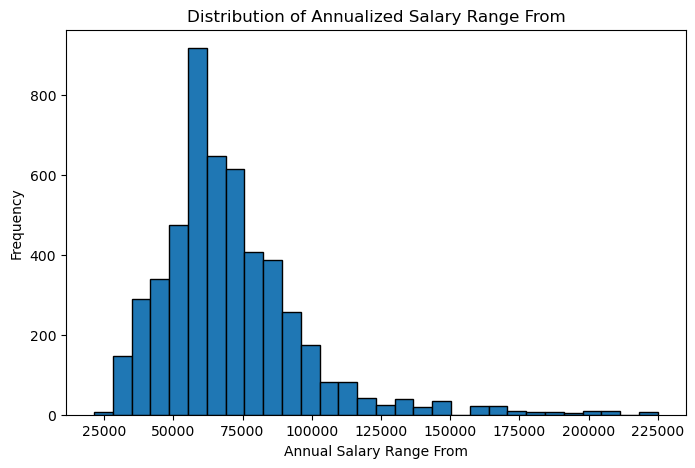

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(df['Annual_Salary_Range_From'].dropna(), bins=30, edgecolor='black')
plt.title('Distribution of Annualized Salary Range From')
plt.xlabel('Annual Salary Range From')
plt.ylabel('Frequency')
plt.show()

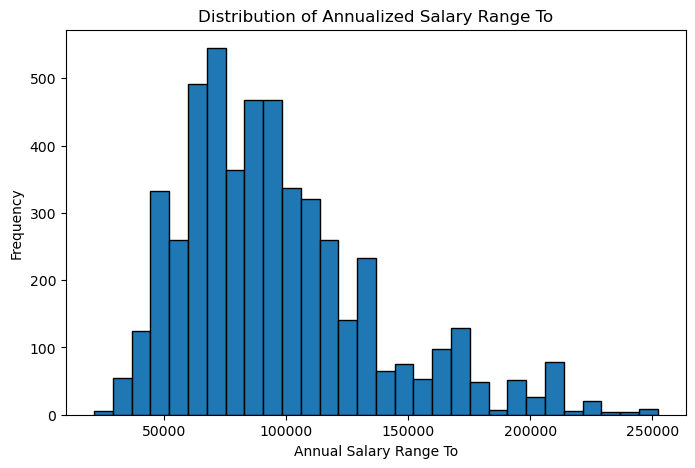

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(df['Annual_Salary_Range_To'].dropna(), bins=30, edgecolor='black')
plt.title('Distribution of Annualized Salary Range To')
plt.xlabel('Annual Salary Range To')
plt.ylabel('Frequency')
plt.show()

In [31]:
df[['Annual_Salary_Range_From', 'Annual_Salary_Range_To']].describe()

,Annual_Salary_Range_From,Annual_Salary_Range_To
count,5079.000000,5079.000000
mean,70704.667916,96167.835189
std,26590.007824,39819.556806
min,21379.800000,21379.800000
25%,55816.000000,67807.500000
50%,64922.000000,89003.000000
75%,81571.000000,115000.000000
max,225000.000000,252165.000000


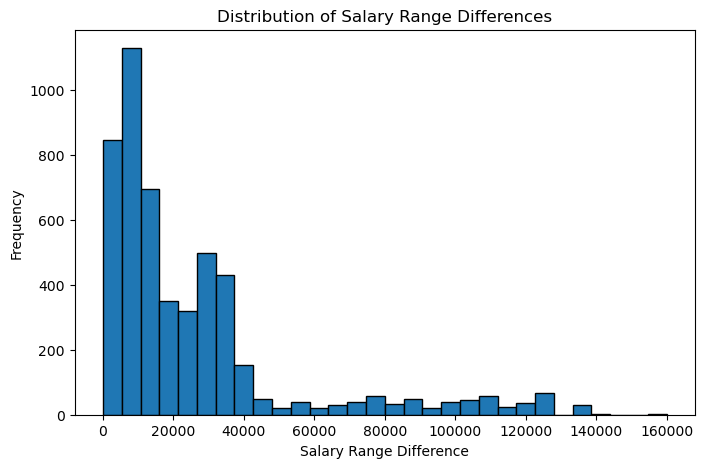

In [32]:
df['Salary_Range_Difference'] = (
    df['Annual_Salary_Range_To'] - df['Annual_Salary_Range_From']
)

plt.figure(figsize=(8, 5))
plt.hist(
    df['Salary_Range_Difference'].dropna(),
    bins=30,
    edgecolor='black'
)

plt.title('Distribution of Salary Range Differences')
plt.xlabel('Salary Range Difference')
plt.ylabel('Frequency')

plt.show()

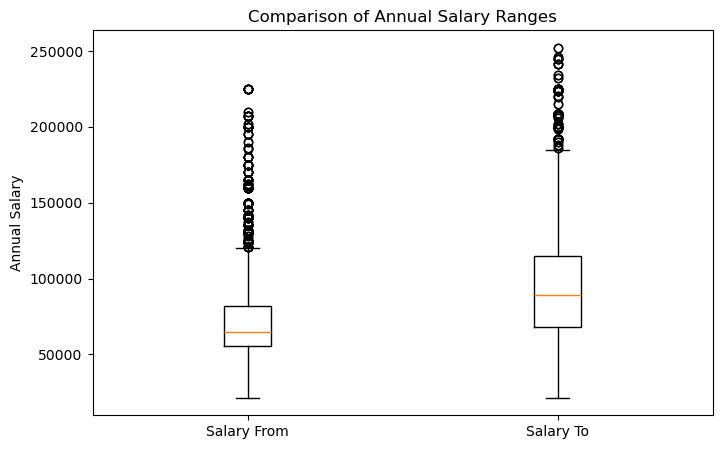

In [33]:
plt.figure(figsize=(8, 5))

plt.boxplot([
    df['Annual_Salary_Range_From'].dropna(),
    df['Annual_Salary_Range_To'].dropna()
])

plt.xticks([1, 2], ['Salary From', 'Salary To'])
plt.title('Comparison of Annual Salary Ranges')
plt.ylabel('Annual Salary')

plt.show()

In [34]:
Q1 = df['Annual_Salary_Range_From'].quantile(0.25)
Q3 = df['Annual_Salary_Range_From'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 17183.5
Upper Bound: 120203.5


In [35]:
outliers_from = df[
    (df['Annual_Salary_Range_From'] < lower_bound) |
    (df['Annual_Salary_Range_From'] > upper_bound)
]

print("Number of outliers:", len(outliers_from))

Number of outliers: 222


In [36]:
outliers_from[
    ['Business Title', 'Agency', 
     'Annual_Salary_Range_From', 
     'Annual_Salary_Range_To']
].sort_values(
    by='Annual_Salary_Range_From',
    ascending=False
).head(20)

,Business Title,Agency,Annual_Salary_Range_From,Annual_Salary_Range_To
2542,"Deputy Commissioner, Environmental Compliance",DEPT OF ENVIRONMENT PROTECTION,225000.0,245000.0
1542,"Deputy Commissioner, Bureau of Customer Services",DEPT OF ENVIRONMENT PROTECTION,225000.0,246000.0
1868,"Deputy Commissioner, Custody Management, Class...",DEPARTMENT OF CORRECTION,225000.0,225000.0
1915,"Deputy Commissioner, Bureau of Customer Services",DEPT OF ENVIRONMENT PROTECTION,225000.0,246000.0
2105,"Deputy Commissioner, Environmental Compliance",DEPT OF ENVIRONMENT PROTECTION,225000.0,245000.0
3361,"Deputy Commissioner, Custody Management, Class...",DEPARTMENT OF CORRECTION,225000.0,225000.0
4351,"Deputy Commissioner, Training & Development",DEPARTMENT OF CORRECTION,225000.0,225000.0
1616,"Deputy Commissioner, Training & Development",DEPARTMENT OF CORRECTION,225000.0,225000.0
2981,First Deputy Commissioner,TAXI & LIMOUSINE COMMISSION,210000.0,245000.0
2943,First Deputy Commissioner,TAXI & LIMOUSINE COMMISSION,210000.0,245000.0


Although the boxplots identified 222 statistical outliers in the minimum annual salary range, inspection of the corresponding job titles, such as Deputy Commissioner and Assistant Commissioner, suggests that many of these observations represent legitimate high salaries associated with senior-level positions. Therefore, the outliers were retained rather than removed.

In [37]:
df

,Job ID,Agency,Posting Type,# Of Positions,Business Title,Civil Service Title,Title Classification,Title Code No,Level,Job Category,Full-Time/Part-Time indicator,Career Level,Salary Range From,Salary Range To,Salary Frequency,Work Location,Division/Work Unit,Job Description,Minimum Qual Requirements,Preferred Skills,Additional Information,To Apply,Residency Requirement,Posting Date,Posting Updated,Process Date,Annual_Salary_Range_From,Annual_Salary_Range_To,Salary_Range_Difference
0,623668,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"Research Analyst, IMAT, Bureau of Maternal Inf...",CITY RESEARCH SCIENTIST,Non-Competitive-5,21744,02,Constituent Services & Community Programs Heal...,F,Experienced (non-manager),82506.0,94882.0,Annual,42-09 28th Street,"Maternal, Infant, & Repr. Hlth","Established in 1805, the New York City Departm...","1. For Assignment Level I (only physical, bio...",Experience in quantitative research methods an...,**IMPORTANT NOTES TO ALL CANDIDATES: Please n...,Apply online with a cover letter to https://a1...,New York City residency is generally required ...,01/23/2024,01/23/2024,03/04/2024,82506.0,94882.0,12376.0
1,608193,DEPT OF DESIGN & CONSTRUCTION,Internal,1,Deputy Director,ADMINISTRATIVE PROJECT MANAGER,Competitive-1,8300B,00,"Policy, Research & Analysis Public Safety, Ins...",F,Experienced (non-manager),58682.0,134570.0,Annual,30-30 Thomson Ave L I City Qns,Pub Bldgs/Transportation,Hours: Full-Time â 35 Hours Work Location: 3...,1. A baccalaureate degree from an accredited c...,Candidates must have excellent management skil...,Authorization to work in the United States is ...,"For City Employees, please go to Employee Self...",New York City Residency is not required for th...,10/03/2023,11/29/2023,03/04/2024,58682.0,134570.0,75888.0
2,625094,DEPT OF DESIGN & CONSTRUCTION,Internal,1,Senior Project Manager,ADMINISTRATIVE PROJECT MANAGER,Competitive-1,8300B,00,"Engineering, Architecture, & Planning",F,Experienced (non-manager),58682.0,91405.0,Annual,30-30 Thomson Ave L I City Qns,PUB BLDGS/CPD/Library/Brooklyn,Hours: Full-Time â 35 Hours Work Location: 3...,1. A baccalaureate degree from an accredited c...,Candidates should have at least six years of e...,Not Specified,Not Specified,New York City Residency is not required for th...,02/01/2024,02/01/2024,03/04/2024,58682.0,91405.0,32723.0
3,580593,DEPARTMENT OF TRANSPORTATION,External,1,Procurement Analyst 2,PROCUREMENT ANALYST,Competitive-1,12158,02,"Finance, Accounting, & Procurement",F,Experienced (non-manager),50972.0,82730.0,Annual,55 Water St Ny Ny,Bridge Repair/352 Kent St,Reporting directly to the Director of Bridge R...,1. A baccalaureate degree from an accredited c...,Familiar with and knowledge of Procurement sys...,The City of New York is an inclusive equal opp...,Resumes may be submitted electronically using ...,New York City residency is generally required ...,04/04/2023,04/04/2023,03/04/2024,50972.0,82730.0,31758.0
4,624937,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"Deputy Director, HIV Planning Council, Divisio...",CITY RESEARCH SCIENTIST,Non-Competitive-5,21744,03,Constituent Services & Community Programs Heal...,F,Experienced (non-manager),92301.0,106146.0,Annual,42-09 28th Street,Dis-Div. Mgmt. & Sys Coord,"Established in 1805, the New York City Departm...","1. For Assignment Level I (only physical, bio...",At least five yearsâ work experience in the ...,Not Specified,Apply online with a cover letter to https://a1...,New York City residency is generally required ...,02/06/2024,02/21/2024,03/04/2024,92301.0,106146.0,13845.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5096,570670,DEPT OF HEALTH/MENTAL HYGIENE,External,1,Public Health Nurse III / Communicable Disease...,PUBLIC HEALTH NURSE,Competitive-1,51011,03,Constituent Services & Community Programs Health,F,Experienced (non-manager),84252.0,84252.0,Annual,30-30 47TH AVE,SH Nursing Services & Prof Dev,*** O

In [38]:
df['# Of Positions'].describe()

count    5079.000000
mean        2.056704
std         5.755037
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       150.000000
Name: # Of Positions, dtype: float64

In [39]:
df['# Of Positions'].value_counts().sort_index()

# Of Positions
1      4067
2       433
3       155
4        88
5        80
6        38
7        39
8        31
9        13
10       33
11        6
12        4
13        5
14        2
15       22
16        4
17        2
18        7
19        3
20        6
21        2
24        4
25        4
26        2
30        2
32        2
34        2
40        3
46        2
60        4
70        6
75        2
81        2
98        2
150       2
Name: count, dtype: int64

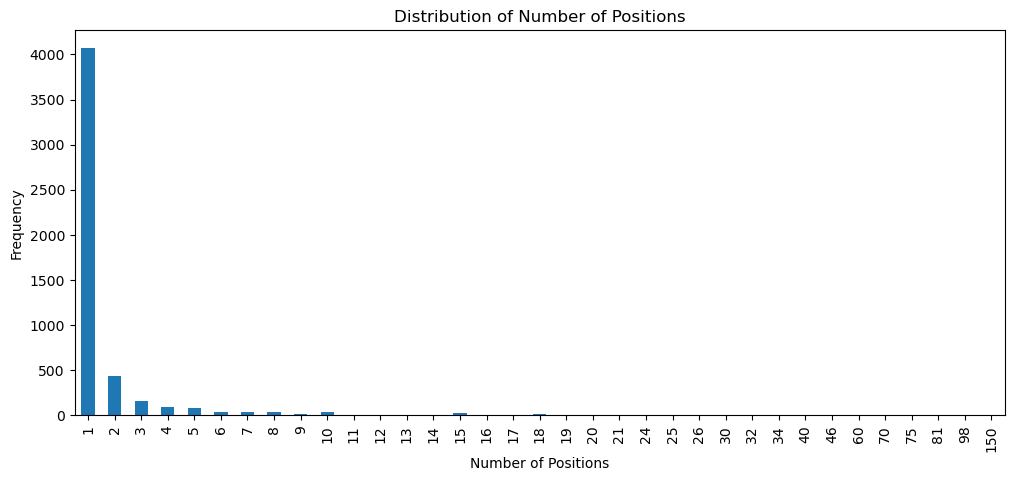

In [40]:
df['# Of Positions'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(12, 5)
)

plt.title('Distribution of Number of Positions')
plt.xlabel('Number of Positions')
plt.ylabel('Frequency')
plt.show()

In [41]:
df[df['# Of Positions'] >= 20][
    ['Business Title', '# Of Positions',
     'Annual_Salary_Range_From', 'Annual_Salary_Range_To']
].sort_values('# Of Positions', ascending=False).head(20)

,Business Title,# Of Positions,Annual_Salary_Range_From,Annual_Salary_Range_To
3725,Child Protective Specialist,150,55463.0,55463.0
1016,Child Protective Specialist,150,55463.0,55463.0
4672,CASE WORKER,98,45329.0,52128.0
2549,CASE WORKER,98,45329.0,52128.0
2426,"Junior Public Health Nurse (Part-Time), Bureau...",81,86715.2,86715.2
1458,"Junior Public Health Nurse (Part-Time), Bureau...",81,86715.2,86715.2
3929,"Public Health Nurse I (Part-Time), Bureau of S...",75,87380.8,87380.8
3072,"Public Health Nurse I (Part-Time), Bureau of S...",75,87380.8,87380.8
3700,Trial Preparation Assistant LV 2- Discovery C...,70,51500.0,51500.0
2015,Trial Preparation Assistant LV 2- Discovery C...,70,51500.0,51500.0


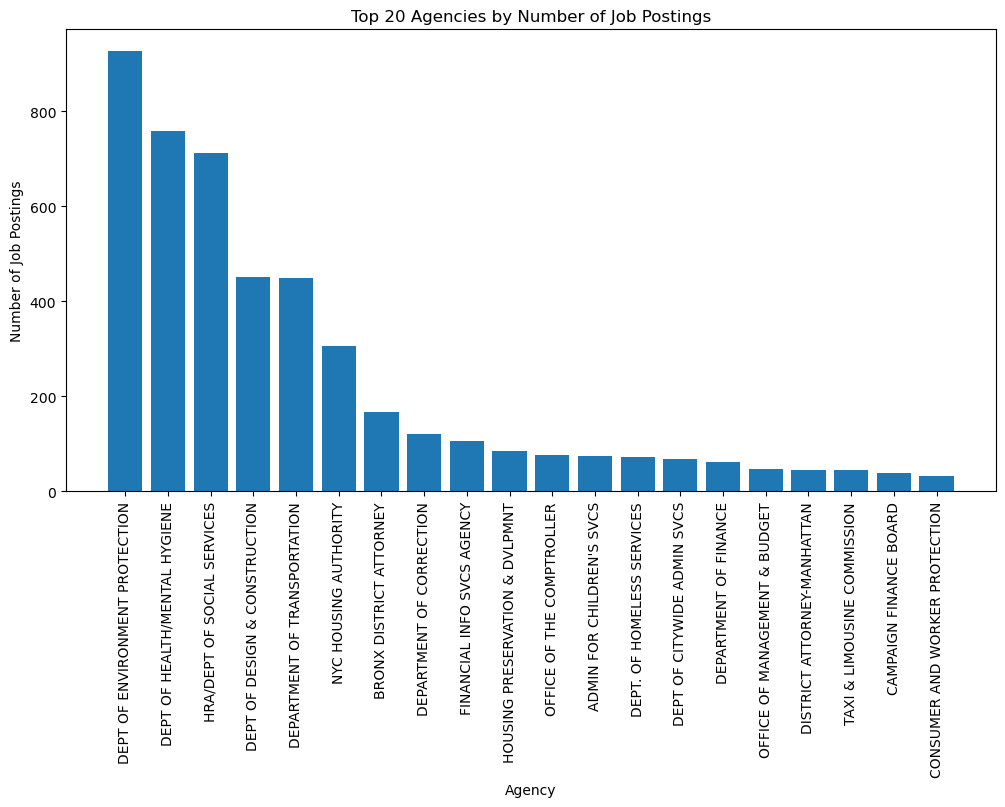

In [42]:
top_20_agencies = df['Agency'].value_counts().head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_20_agencies.index, top_20_agencies.values)

plt.title('Top 20 Agencies by Number of Job Postings')
plt.xlabel('Agency')
plt.ylabel('Number of Job Postings')

plt.xticks(rotation=90)
plt.show()

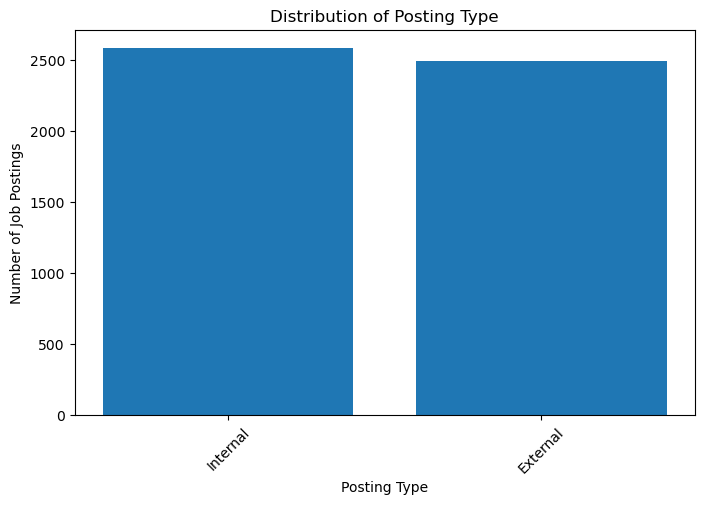

In [43]:
posting_type_counts = df['Posting Type'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(posting_type_counts.index, posting_type_counts.values)

plt.title('Distribution of Posting Type')
plt.xlabel('Posting Type')
plt.ylabel('Number of Job Postings')

plt.xticks(rotation=45)
plt.show()

In [44]:
df['Business Title'].nunique()

1771

In [45]:
df['Business Title'].value_counts().head(20)

Business Title
Project Manager                                              63
CASE MANAGEMENT SUPERVISOR                                   62
ACCOUNTABLE MANAGER                                          58
Deputy Director                                              38
CASE MANAGEMENT TEAM LEADER                                  36
Senior Project Manager                                       30
Director                                                     24
Design Engineer                                              22
Child Care Inspector, Bureau of Childcare                    22
College Aide                                                 20
Project Engineer                                             20
Assistant Civil Engineer                                     20
UNIT CLERK                                                   19
DEPUTY DIRECTOR                                              18
Engineer-In-Charge                                           18
Junior Project Manager   

In [46]:
df['Business Title'] = df['Business Title'].str.strip().str.upper()

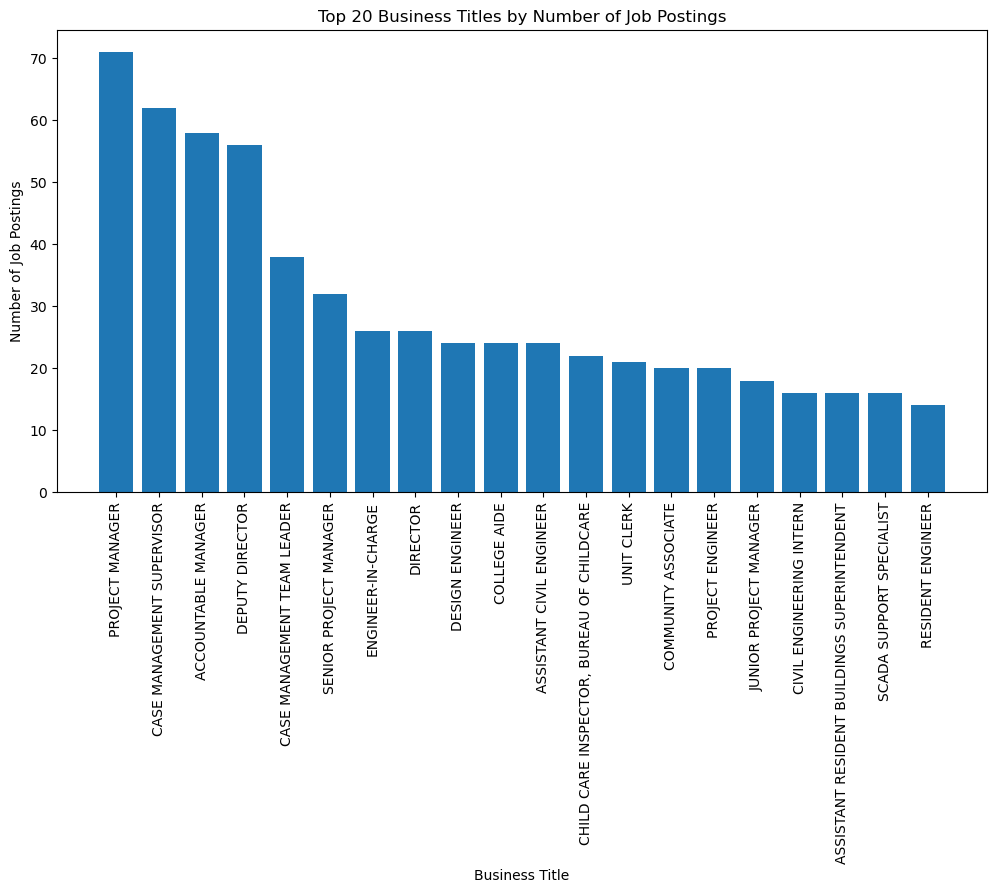

In [47]:
top_20_titles = df['Business Title'].value_counts().head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_20_titles.index, top_20_titles.values)

plt.title('Top 20 Business Titles by Number of Job Postings')
plt.xlabel('Business Title')
plt.ylabel('Number of Job Postings')

plt.xticks(rotation=90)
plt.show()

The Business Title feature contains a large number of unique job titles and exhibits a long-tailed distribution. After standardizing the text by removing extra spaces and converting values to uppercase, duplicate categories caused by capitalization inconsistencies were successfully consolidated. Although most individual job titles occur infrequently, the feature is expected to be highly relevant for predicting salary because job titles reflect differences in responsibilities, skills, and seniority.

In [48]:
# Number of unique values
df['Civil Service Title'].nunique()

364

In [49]:
# Top 20 most frequent values
df['Civil Service Title'].value_counts().head(20)

Civil Service Title
COMMUNITY COORDINATOR             269
CITY RESEARCH SCIENTIST           236
PRINCIPAL ADMINISTRATIVE ASSOC    183
COMMUNITY ASSOCIATE               180
CLERICAL ASSOCIATE                148
ADMINISTRATIVE STAFF ANALYST (    148
AGENCY ATTORNEY                   123
CIVIL ENGINEER                     98
ASSOCIATE PROJECT MANAGER          97
ASSISTANT CIVIL ENGINEER           88
COMPUTER SPECIALIST (SOFTWARE)     84
ADMINISTRATIVE PROJECT MANAGER     79
ASSOCIATE STAFF ANALYST            78
ASSOCIATE JOB OPPORTUNITY SPEC     70
ASSISTANT DISTRICT ATTORNEY (S     66
ASSOCIATE BENEFITS OPPORTUNITY     66
ADMINISTRATIVE ENGINEER            62
CONSTRUCTION PROJECT MANAGER       62
EXECUTIVE AGENCY COUNSEL           61
COLLEGE AIDE (ALL CITY DEPTS)      60
Name: count, dtype: int64

In [50]:
df['Civil Service Title'] = df['Civil Service Title'].str.strip().str.upper()

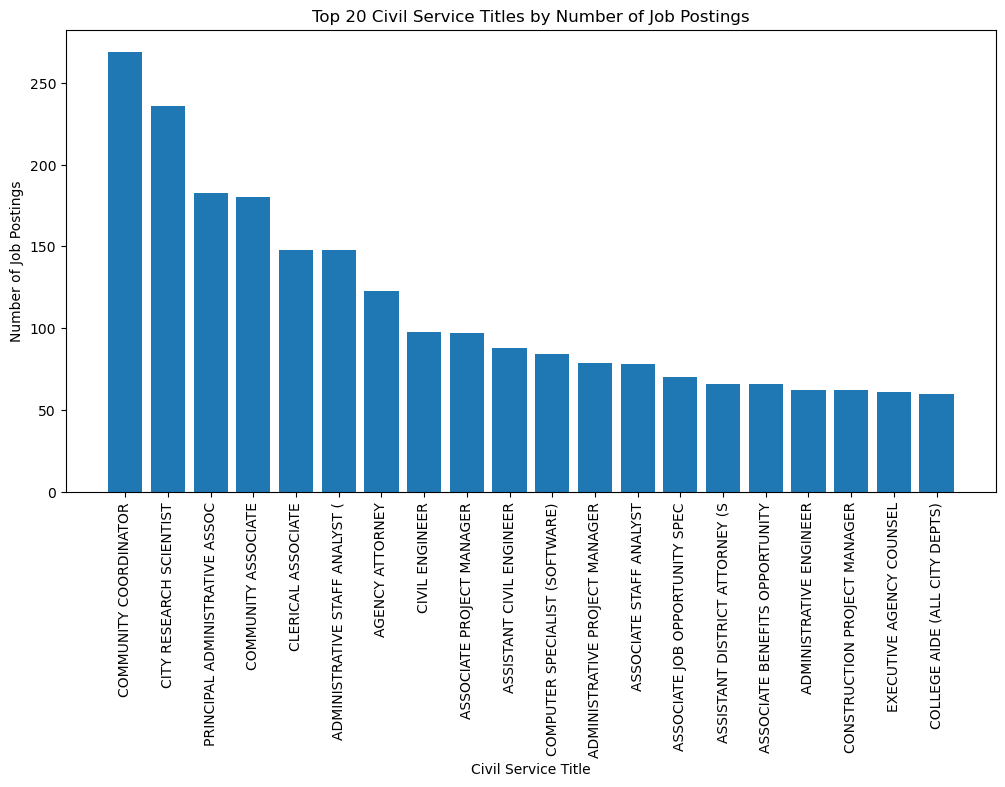

In [51]:
top_20_civil_titles = df['Civil Service Title'].value_counts().head(20)

plt.figure(figsize=(12, 6))
plt.bar(top_20_civil_titles.index, top_20_civil_titles.values)

plt.title('Top 20 Civil Service Titles by Number of Job Postings')
plt.xlabel('Civil Service Title')
plt.ylabel('Number of Job Postings')

plt.xticks(rotation=90)
plt.show()

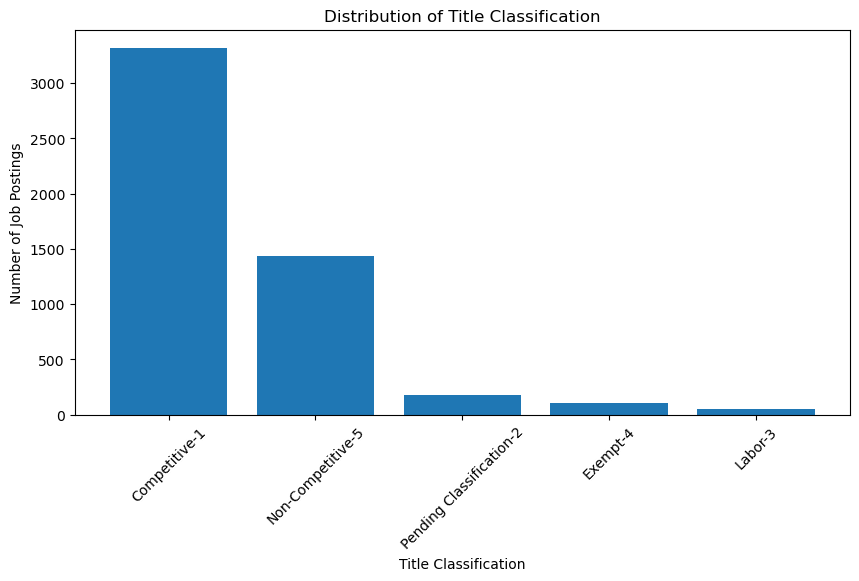

In [52]:
title_class_counts = df['Title Classification'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(title_class_counts.index, title_class_counts.values)

plt.title('Distribution of Title Classification')
plt.xlabel('Title Classification')
plt.ylabel('Number of Job Postings')

plt.xticks(rotation=45)
plt.show()

Most job postings belong to the Competitive classification, followed by Non-Competitive positions. Other classifications represent only a small proportion of the dataset.

In [53]:
print("Number of unique values:", df['Career Level'].nunique())
print(df['Career Level'].unique())

Number of unique values: 5
['Experienced (non-manager)' 'Entry-Level' 'Student' 'Manager' 'Executive']


In [54]:
career_level_counts = df['Career Level'].value_counts()

print(career_level_counts)

Career Level
Experienced (non-manager)    3815
Manager                       581
Entry-Level                   453
Student                       134
Executive                      96
Name: count, dtype: int64


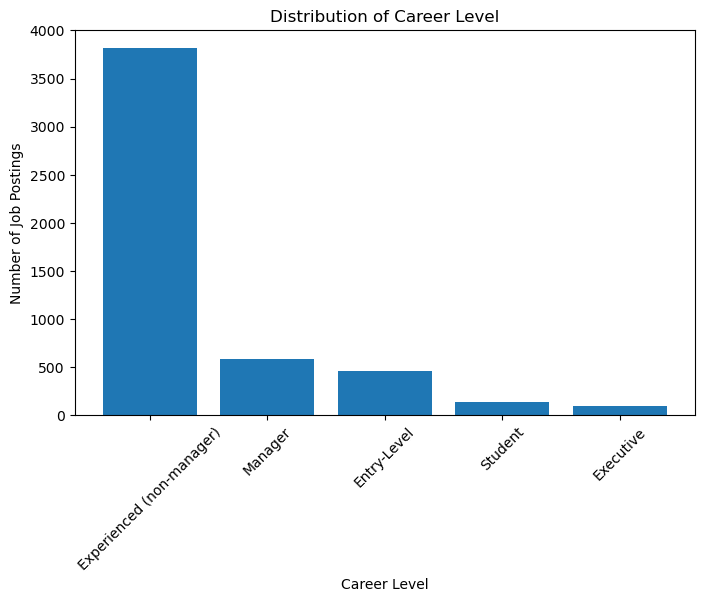

In [55]:
plt.figure(figsize=(8, 5))

plt.bar(career_level_counts.index, career_level_counts.values)

plt.title('Distribution of Career Level')
plt.xlabel('Career Level')
plt.ylabel('Number of Job Postings')

plt.xticks(rotation=45)
plt.show()

Most job opportunities in the dataset target experienced non-managerial professionals, while entry-level, student, and executive positions represent a much smaller share.

In [56]:
df.columns.tolist()


['Job ID',
 'Agency',
 'Posting Type',
 '# Of Positions',
 'Business Title',
 'Civil Service Title',
 'Title Classification',
 'Title Code No',
 'Level',
 'Job Category',
 'Full-Time/Part-Time indicator',
 'Career Level',
 'Salary Range From',
 'Salary Range To',
 'Salary Frequency',
 'Work Location',
 'Division/Work Unit',
 'Job Description',
 'Minimum Qual Requirements',
 'Preferred Skills',
 'Additional Information',
 'To Apply',
 'Residency Requirement',
 'Posting Date',
 'Posting Updated',
 'Process Date',
 'Annual_Salary_Range_From',
 'Annual_Salary_Range_To',
 'Salary_Range_Difference']

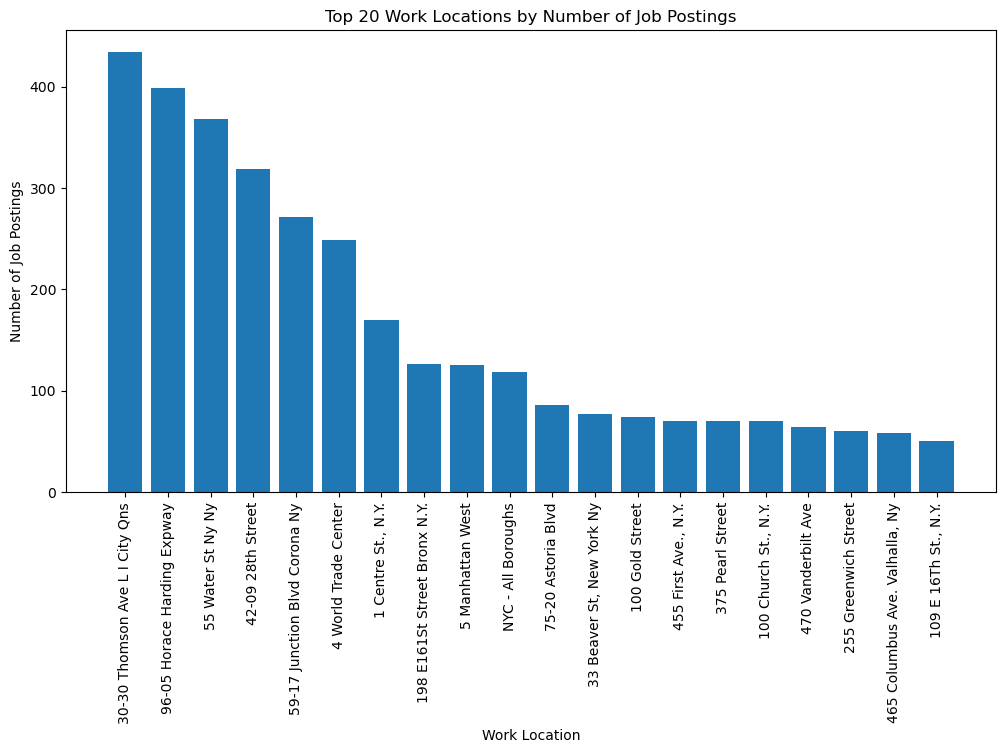

In [57]:
work_location_counts = df['Work Location'].value_counts().head(20)

plt.figure(figsize=(12, 6))
plt.bar(work_location_counts.index, work_location_counts.values)

plt.title('Top 20 Work Locations by Number of Job Postings')
plt.xlabel('Work Location')
plt.ylabel('Number of Job Postings')

plt.xticks(rotation=90)
plt.show()

The highest number of job postings are concentrated at 30-30 Thomson Ave, Long Island City, followed by 96-05 Horace Harding Expressway and 55 Water Street, New York. After the top locations, the number of postings gradually decreases.

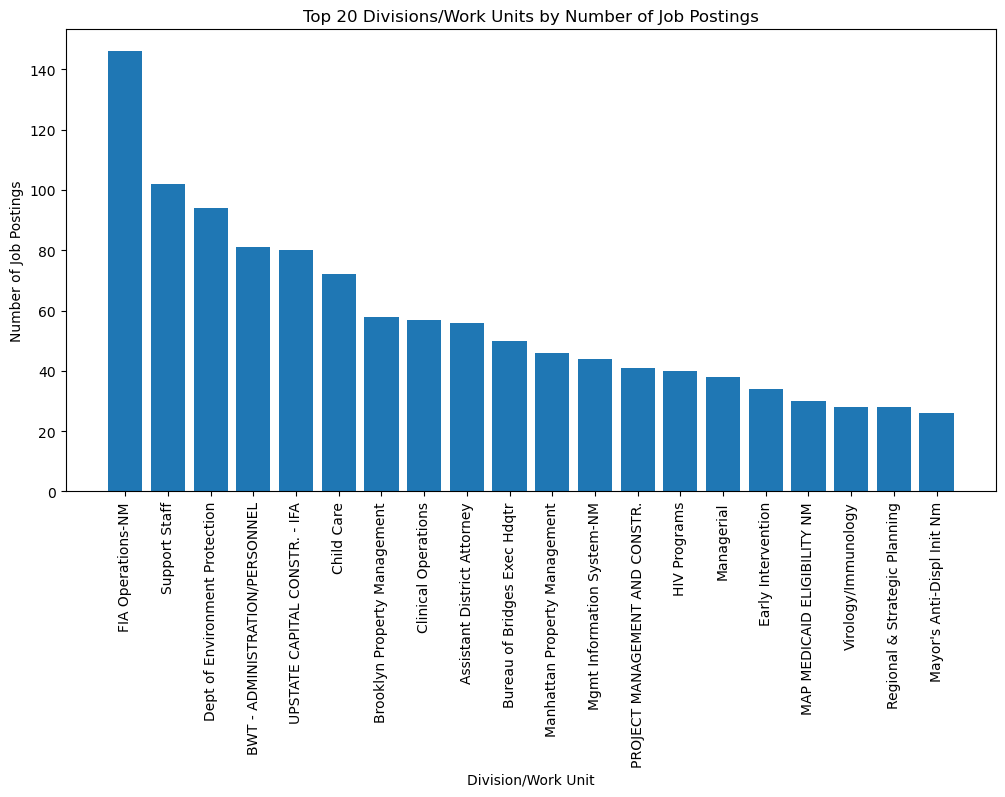

In [58]:
division_counts = df['Division/Work Unit'].value_counts().head(20)

plt.figure(figsize=(12, 6))
plt.bar(division_counts.index, division_counts.values)

plt.title('Top 20 Divisions/Work Units by Number of Job Postings')
plt.xlabel('Division/Work Unit')
plt.ylabel('Number of Job Postings')

plt.xticks(rotation=90)
plt.show()

FIA Operations-NM has the highest number of postings (146).
Support Staff is next (102).
Dept of Environment Protection has 94 postings.
There are many different divisions, indicating that job postings are spread across a large number of specialized work units

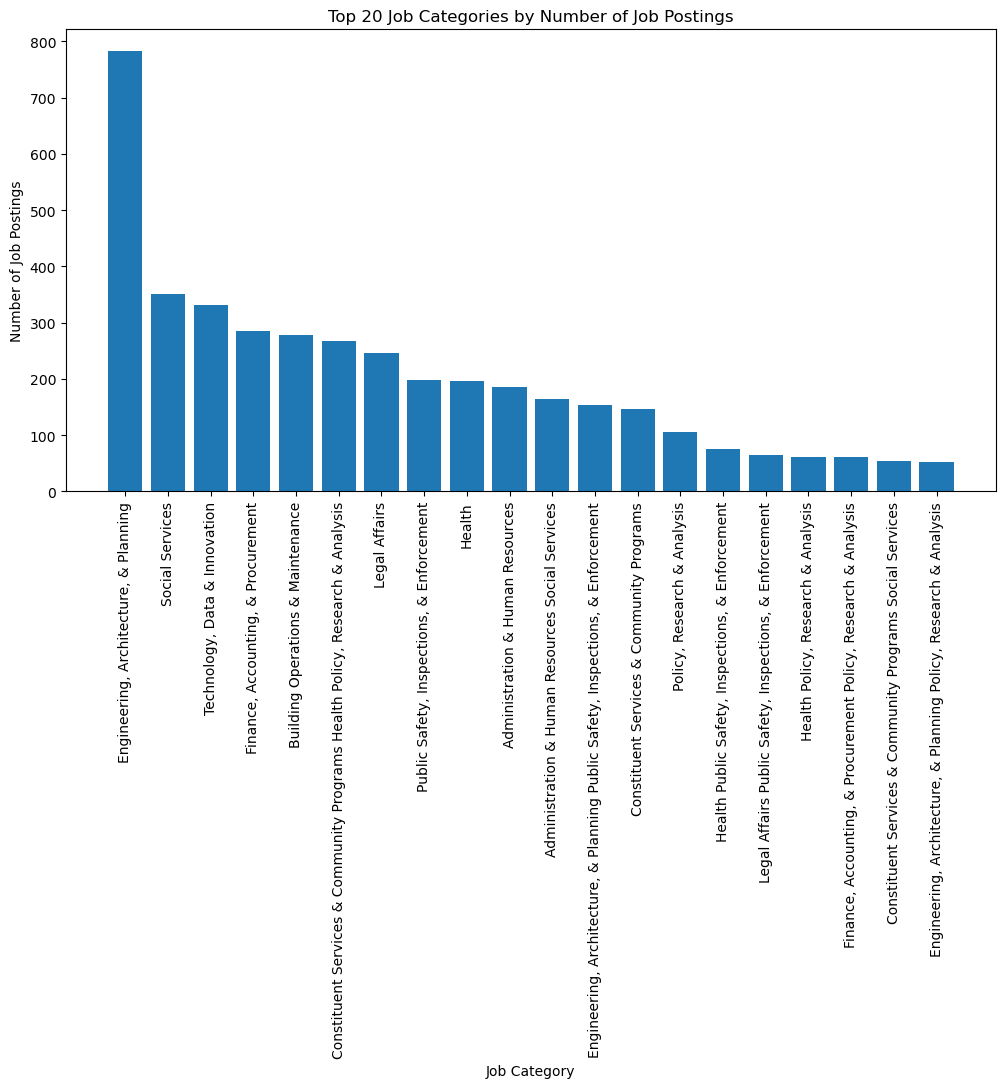

In [59]:
job_category_counts = df['Job Category'].value_counts().head(20)

plt.figure(figsize=(12, 6))
plt.bar(job_category_counts.index, job_category_counts.values)

plt.title('Top 20 Job Categories by Number of Job Postings')
plt.xlabel('Job Category')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=90)

plt.show()


Engineering, Architecture & Planning has the highest number of job postings by a large margin, followed by Social Services and Technology, Data & Innovation. This indicates that the dataset has strong demand across engineering, social services, and technology-related roles.

In [60]:
print(df['Full-Time/Part-Time indicator'].value_counts())
print("Missing values:", df['Full-Time/Part-Time indicator'].isnull().sum())

Full-Time/Part-Time indicator
F                4801
P                 162
Not Specified     116
Name: count, dtype: int64
Missing values: 0


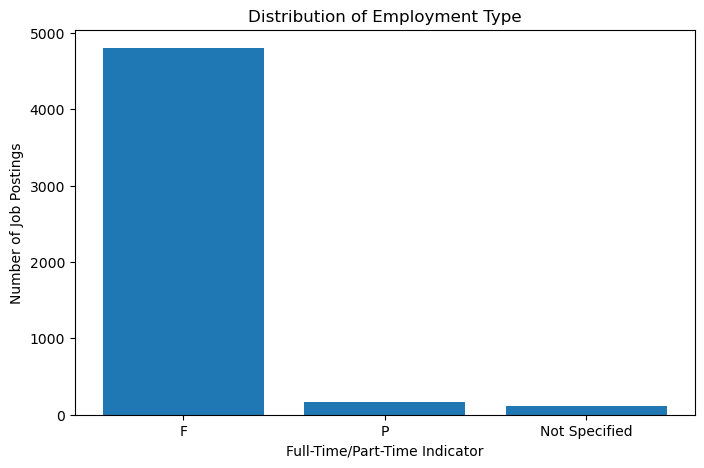

In [61]:
full_time_counts = df['Full-Time/Part-Time indicator'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(full_time_counts.index, full_time_counts.values)

plt.title('Distribution of Employment Type')
plt.xlabel('Full-Time/Part-Time Indicator')
plt.ylabel('Number of Job Postings')

plt.show()

Full-Time (F) jobs dominate the dataset.
Part-Time (P) jobs are comparatively very few.
Some records have Not Specified, representing the values that were originally missing.

In [62]:
df['Preferred Skills'].sample(10, random_state=42).values

array(['1.\tPossession of CDL endorsement (ex: Passenger, Tanker, Tow Truck).  2.\tExcellent communication, organizational and customer service skills.  3.\tAbility to train other employees.  4.\tExperience operating specialized equipment including backhoes, beach equipment, and front-end loaders.  5.\tClean driving record.  6.\tAbility to work rotating shifts, nights, and weekends as needed.',
       'MS Office, good written skills, Energetic, willing to learn, and a team player.',
       'Preference will be given to candidates with at least four years of strong managerial, administrative, or supervisory experience; with design experience related to infrastructure work (i.e., sewer, water mains, roadways), familiarity with troubleshoot hydraulic, geotechnical and structural issues; familiarity with NYCDOT, NYSDOT, and NYCDEP specifications and standards; familiarity with MUTCD and AASHTO; understanding of the NYC street infrastructure system; and knowledge of current and up-to-date en

In [63]:
# Clean and standardize text formatting in the Preferred Skills column
df['Preferred Skills'] = (
    df['Preferred Skills']
    .str.replace(r'â_x0080_¢', ' ', regex=True)
    .str.replace(r'â_x0080__x0099_s', "'", regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [64]:
# Preview cleaned Preferred Skills entries
df['Preferred Skills'].sample(10, random_state=42).values

array(['1. Possession of CDL endorsement (ex: Passenger, Tanker, Tow Truck). 2. Excellent communication, organizational and customer service skills. 3. Ability to train other employees. 4. Experience operating specialized equipment including backhoes, beach equipment, and front-end loaders. 5. Clean driving record. 6. Ability to work rotating shifts, nights, and weekends as needed.',
       'MS Office, good written skills, Energetic, willing to learn, and a team player.',
       'Preference will be given to candidates with at least four years of strong managerial, administrative, or supervisory experience; with design experience related to infrastructure work (i.e., sewer, water mains, roadways), familiarity with troubleshoot hydraulic, geotechnical and structural issues; familiarity with NYCDOT, NYSDOT, and NYCDEP specifications and standards; familiarity with MUTCD and AASHTO; understanding of the NYC street infrastructure system; and knowledge of current and up-to-date engineering m

In [65]:
# Define a list of skills to analyze within job postings
skills = [
    'python',
    'sql',
    'excel',
    'power bi',
    'tableau',
    'powerpoint',
    'microsoft word',
    'microsoft office',
    'access',
    'autocad',
    'adobe creative suite',
    'project management',
    'construction management',
    'data analysis',
    'business process analysis',
    'communication',
    'written communication',
    'oral communication',
    'presentation',
    'teamwork',
    'leadership',
    'organizational skills',
    'analytical skills',
    'customer service',
    'time management',
    'strategic planning',
    'change management',
    'conflict resolution',
    'network',
    'databases'
]

In [66]:
# Count job postings containing each selected skill
skill_counts = {}

for skill in skills:
    skill_counts[skill] = df['Preferred Skills'].str.contains(
        skill,
        case=False,
        na=False
    ).sum()

skill_counts

{'python': np.int64(67),
 'sql': np.int64(246),
 'excel': np.int64(2552),
 'power bi': np.int64(64),
 'tableau': np.int64(51),
 'powerpoint': np.int64(502),
 'microsoft word': np.int64(258),
 'microsoft office': np.int64(706),
 'access': np.int64(342),
 'autocad': np.int64(187),
 'adobe creative suite': np.int64(26),
 'project management': np.int64(456),
 'construction management': np.int64(72),
 'data analysis': np.int64(149),
 'business process analysis': np.int64(18),
 'communication': np.int64(2455),
 'written communication': np.int64(789),
 'oral communication': np.int64(282),
 'presentation': np.int64(328),
 'teamwork': np.int64(53),
 'leadership': np.int64(301),
 'organizational skills': np.int64(471),
 'analytical skills': np.int64(259),
 'customer service': np.int64(137),
 'time management': np.int64(174),
 'strategic planning': np.int64(56),
 'change management': np.int64(23),
 'conflict resolution': np.int64(55),
 'network': np.int64(61),
 'databases': np.int64(134)}

In [67]:
skill_df = pd.DataFrame(
    list(skill_counts.items()),
    columns=['Skill', 'Count']
).sort_values(by='Count', ascending=False)

skill_df

,Skill,Count
2,excel,2552
15,communication,2455
16,written communication,789
7,microsoft office,706
5,powerpoint,502
21,organizational skills,471
11,project management,456
8,access,342
18,presentation,328
20,leadership,301


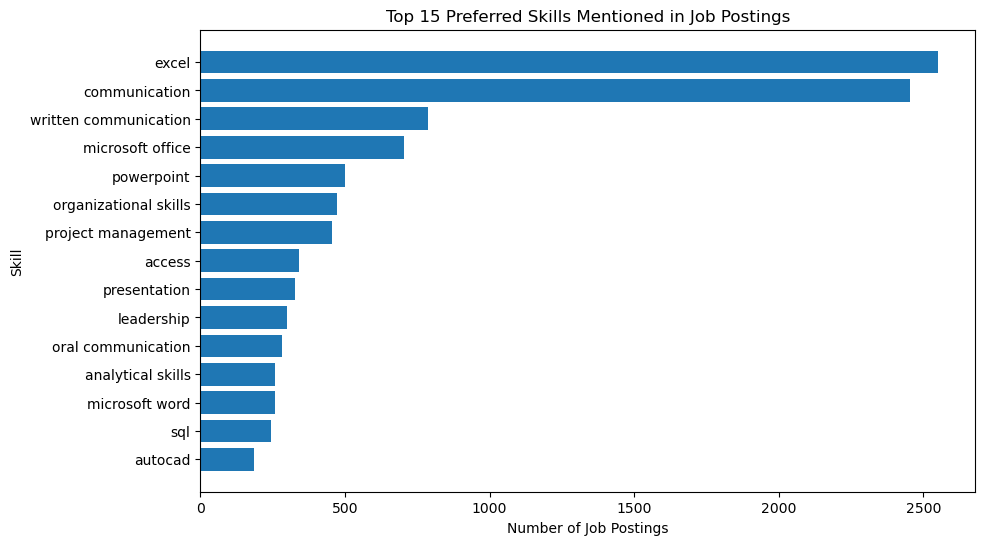

In [68]:
top_skills = skill_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_skills['Skill'], top_skills['Count'])

plt.title('Top 15 Preferred Skills Mentioned in Job Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill')

plt.gca().invert_yaxis()
plt.show()

Excel is by far the most frequently mentioned preferred skill.
Communication is the second most requested skill.
Written communication and oral communication also appear frequently.
Microsoft Office, PowerPoint, and Microsoft Word are common requirements.
Organizational skills and Project Management are important.
Technical skills such as SQL and AutoCAD appear less frequently in the overall dataset.

In [69]:
df['Minimum Qual Requirements'].sample(10, random_state=42).values

array(['1. A four-year high school diploma or its education equivalent and 6 months of full-time satisfactory paid experience in gardening, grounds or tree maintenance, or in the building, construction or maintenance trades; or  2. One year of full-time experience in gardening, grounds or tree maintenance, or in the building, construction or maintenance trades; or  License Requirement:  Possession of a Class B Commercial Driver License valid in the State of New York.  There may be certain age requirements to obtain this license. Employees must maintain the Class B Commercial Driver License during their employment.',
       'For Assignment Level I:  Matriculation at an accredited college or graduate school. Employment is conditioned upon continuance as a student in a college or graduate school.  For Assignment Level II (Information Technology):  Matriculation at an accredited college or graduate school. Employment is conditioned upon continuance as a student in a college or graduate sch

In [70]:
# Extract education levels from minimum qualification requirements
def extract_education(text):
    text = str(text).lower()

    if 'doctorate' in text or 'ph.d' in text:
        return 'Doctorate'
    elif "master's degree" in text or 'masters degree' in text:
        return 'Masters'
    elif 'baccalaureate degree' in text or "bachelor's degree" in text:
        return 'Bachelors'
    elif 'associate degree' in text:
        return 'Associate'
    elif 'high school diploma' in text:
        return 'High School'
    else:
        return 'Not Specified'

df['Education_Level'] = df['Minimum Qual Requirements'].apply(extract_education)


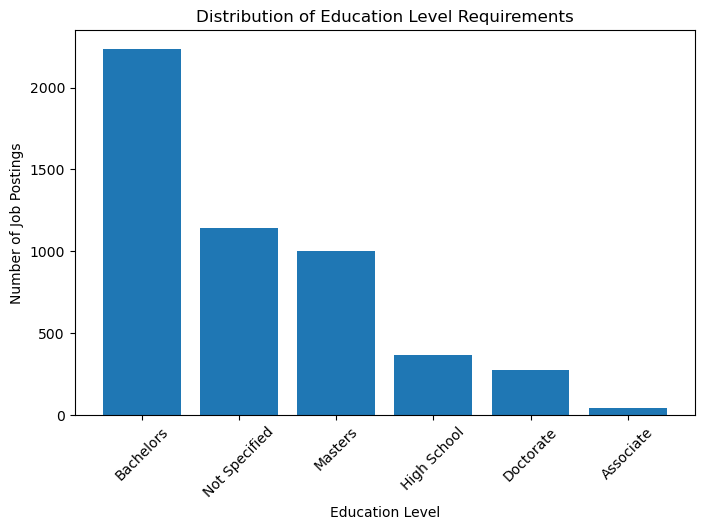

In [71]:
education_counts = df['Education_Level'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(education_counts.index, education_counts.values)

plt.title('Distribution of Education Level Requirements')
plt.xlabel('Education Level')
plt.ylabel('Number of Job Postings')

plt.xticks(rotation=45)
plt.show()

In [72]:
# Extract minimum required experience in years from qualification requirements

def extract_experience_years(text):
    text = str(text).lower()

    years = re.findall(r'(\d+)\s*(?:year|years)', text)
    months = re.findall(r'(\d+)\s*(?:month|months)', text)

    values = []

    for year in years:
        values.append(float(year))

    for month in months:
        values.append(float(month) / 12)

    if values:
        return min(values)

    return None


df['Min_Experience_Years'] = df['Minimum Qual Requirements'].apply(
    extract_experience_years
)

df['Min_Experience_Years'].value_counts().sort_index()

Min_Experience_Years
0.083333       4
0.250000      10
0.500000     318
0.750000      94
1.000000      24
1.500000     342
2.000000      57
3.000000       4
4.000000       9
5.000000      42
6.000000      62
7.000000       4
10.000000     22
15.000000      2
20.000000      2
Name: count, dtype: int64

In [73]:
pd.set_option('display.max_colwidth', None)

df.loc[
    [1001, 852, 3423, 79, 2488, 4014, 4297, 3025, 4015],
    ['Minimum Qual Requirements', 'Min_Experience_Years']
]

,Minimum Qual Requirements,Min_Experience_Years
1001,"Education and Experience Requirements: By the last day of the Application Period you must have: (1) Five years of full-time satisfactory experience as a plasterer; or (2) At least three years of full-time satisfactory experience as a plasterer, plus sufficient fulltime experience as a plastererâs apprentice, or training of a relevant nature acquired in a technical school or trade school or vocational high school approved by a Stateâs Department of Education or a recognized accrediting organization, to make up the equivalent of five years of acceptable experience. Six months of acceptable experience will be credited for each year of apprentice experience or approved trade or vocational high school training.",NaN
852,"At least six years of full-time satisfactory experience in construction management work on capital projects, each one of which must have had a dollar value of at least $15,000, at least eighteen months of which must have been in a managerial or consultative capacity in an organization responsible for the management of construction; and a combination of the following, sufficient to equal a total of ten years of education and experience: a. Full-time satisfactory experience in construction inspection on capital projects, each one of which must have had a dollar value of at least $15,000. One year of acceptable experience will be credited for each year of construction inspection experience up to a maximum of four years. b. Full-time satisfactory experience in building construction as a journeyperson in one or more of the skilled building construction trades. One year of acceptable experience will be credited for each year of journeyperson experience up to a maximum of four years. c. Education in an accredited college leading to a bachelor's degree in architecture, landscape architecture, or air pollution control, chemical, civil including structural and bridge design, electrical, mechanical, or sanitary engineering will be credited on the basis of 30 credits for one year of acceptable experience up to a maximum of four years. A New York State license as a professional engineer or registered architect or a license as a professional engineer or registered architect from a state that has reciprocity with New York State may be substituted for the four years of education and experience described in a, b and c above. However, all candidates must have at least six years of experience in construction management work described above, including at least eighteen months in a managerial or consultative capacity in an organization responsible for the management of construction. License Requirements Possession of a Motor Vehicle Driver License valid in the State of New York. Employees must maintain the license during their employment.",NaN
3423,Qualification Requirements A four-year high school diploma or its educational equivalent approved by a State's department of education or a recognized accrediting organization and one year of satisfactory clerical experience. Skills Requirement Keyboard familiarity with the ability to type at a minimum of 100 key strokes (20 words) per minute.,NaN
79,Qualification Requirements 1. High school graduation or equivalent and three years of experience in community work or community centered activities in an area related to duties described above; or 2. Education and/or experience which is equivalent to 1 above.,NaN
2488,"(1) A baccalaureate degree from an accredited college, including or supplemented by twenty-four (24) semester credits in computer science or a related computer field and two (2) years of satisfactory full-time software experience in designing, programming, debugging, maintaining, implementing, and enhancing computer software applications, systems programming, systems analysis and design, data communication software, or database design and programming, including one year in a project leader capacity or as a major contributor

In [74]:
experience_keywords = [
    'experience',
    'full-time experience',
    'work experience',
    'satisfactory experience'
]

df['Experience_Required'] = df['Minimum Qual Requirements'].apply(
    lambda x: 'Yes' if any(
        keyword in str(x).lower() for keyword in experience_keywords
    ) else 'No'
)

df['Experience_Required'].value_counts()

Experience_Required
Yes    4636
No      443
Name: count, dtype: int64

In [75]:
management_keywords = [
    'managerial',
    'supervisory',
    'executive capacity',
    'administrative capacity',
    'supervision of staff'
]

df['Management_Experience_Required'] = df['Minimum Qual Requirements'].apply(
    lambda x: 'Yes' if any(
        keyword in str(x).lower() for keyword in management_keywords
    ) else 'No'
)

df['Management_Experience_Required'].value_counts()

Management_Experience_Required
No     3340
Yes    1739
Name: count, dtype: int64

In [76]:
df['Additional Information'].sample(10, random_state=42).values

array(['Not Specified',
       "The City of New York is an inclusive equal opportunity employer committed to recruiting and retaining a diverse workforce and providing a work environment that is free from discrimination and harassment based upon any legally protected status or protected characteristic, including but not limited to an individual's sex, race, color, ethnicity, national origin, age, religion, disability, sexual orientation, veteran status, gender identity, or pregnancy.  As a current or prospective employee of the City of New York, you may be eligible for federal loan forgiveness programs and state repayment assistance programs. Please review the notice to see if you may be eligible for programs and how to apply on line at nyc.gov/studentloans or nyc.gov/dcas.  This position is open to qualified persons with a disability who are eligible for the 55-a program.  Please indicate in your resume or cover letter that you would like to be considered for the position under the 55

In [77]:
df['To Apply'].sample(10, random_state=42).values

array(['Not Specified',
       'Resumes may be submitted electronically using the following method:  For City employees only, go to Employee Self Service (ESS), Careers, and Search for Job ID# 583051  For other applicants, go to www.nyc.gov/careers and search for Job ID# 583051  Appointments are subject to OMB approval.  Only candidates selected for an interview will be contacted.  No telephone inquiries please.  * No duplicate applications please.',
       'All applicants, including City Employees: Please go to NYC Government Jobs  Explore Careers  City of New York, go to Search for Open Jobs, and type in the Job ID # listed above. Submit job application as prompted. Do not apply via Employee Self-Service (ESS), e-mail, mail, or fax your resume to DDC directly.',
       'To apply click the Apply Button Now', 'TBD',
       'All resumes are to be submitted electronically.  Current City Employees: Please log into Employee Self Service (ESS) at https://hrb.nycaps.nycnet, follow the Career

In [78]:
df['Residency Requirement'].value_counts(dropna=False)

Residency Requirement
New York City residency is generally required within 90 days of appointment. However, City Employees in certain titles who have worked for the City for 2 continuous years may also be eligible to reside in Nassau, Suffolk, Putnam, Westchester, Rockland, or Orange County. To determine if the residency requirement applies to you, please discuss with the agency representative at the time of interview.    2777
New York City Residency is not required for this position                                                                                                                                                                                                                                                                                                                                                           1284
NYCHA has no residency requirements.                                                                                                                            

In [79]:
df['Residency Requirement'].value_counts().head(20)

Residency Requirement
New York City residency is generally required within 90 days of appointment. However, City Employees in certain titles who have worked for the City for 2 continuous years may also be eligible to reside in Nassau, Suffolk, Putnam, Westchester, Rockland, or Orange County. To determine if the residency requirement applies to you, please discuss with the agency representative at the time of interview.                                                                                                                                                                                                                                                                                                                                                                                2777
New York City Residency is not required for this position                                                                                                                                                    

In [80]:
def clean_residency(text):
    text = str(text).lower().strip()
    
    # Not required
    if ('not required' in text or 
        'no residency requirement' in text or
        'no residency requirements' in text or
        'exempt from' in text):
        return 'Not Required'
    
    # Unknown / TBD
    elif text in ['tbd', 'not specified', 'nan', '']:
        return 'Not Specified'
    
    # Required
    elif 'required' in text:
        return 'Required'
    
    else:
        return 'Not Specified'


df['Residency Requirement'] = df['Residency Requirement'].apply(clean_residency)

df['Residency Requirement'].value_counts()

Residency Requirement
Required         2908
Not Required     2135
Not Specified      36
Name: count, dtype: int64

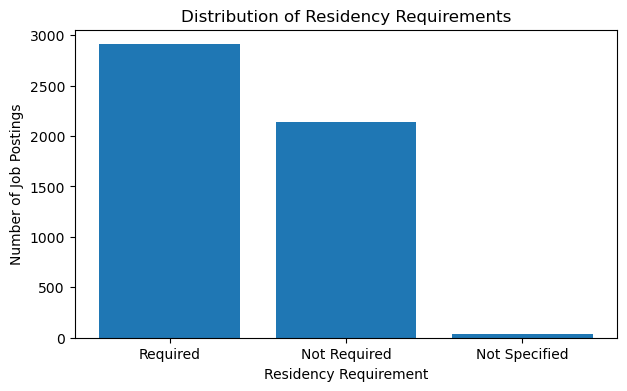

In [81]:
residency_counts = df['Residency Requirement'].value_counts()

plt.figure(figsize=(7, 4))
plt.bar(residency_counts.index, residency_counts.values)

plt.title('Distribution of Residency Requirements')
plt.xlabel('Residency Requirement')
plt.ylabel('Number of Job Postings')

plt.show()

In [82]:
# Convert Posting Date to datetime and check the date range

df['Posting Date'] = pd.to_datetime(df['Posting Date'])

print("Earliest posting:", df['Posting Date'].min())
print("Latest posting:", df['Posting Date'].max())

Earliest posting: 2020-06-30 00:00:00
Latest posting: 2024-03-04 00:00:00


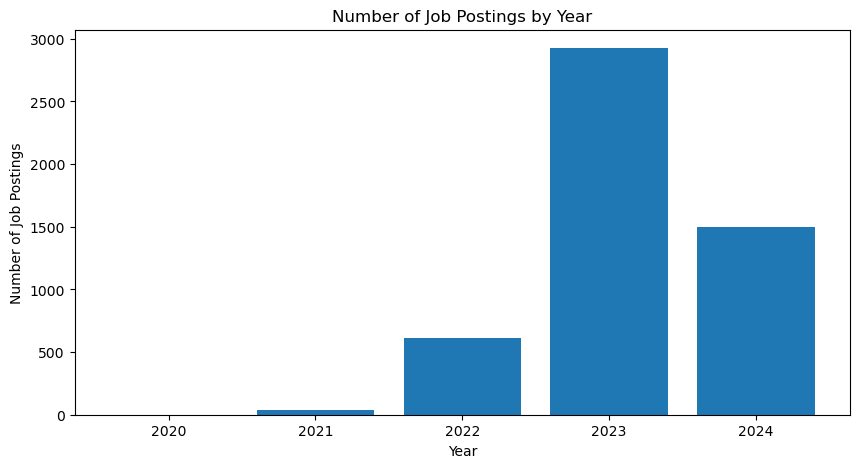

In [83]:
df['Posting_Year'] = df['Posting Date'].dt.year

year_counts = df['Posting_Year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(year_counts.index, year_counts.values)

plt.title('Number of Job Postings by Year')
plt.xlabel('Year')
plt.ylabel('Number of Job Postings')

plt.show()

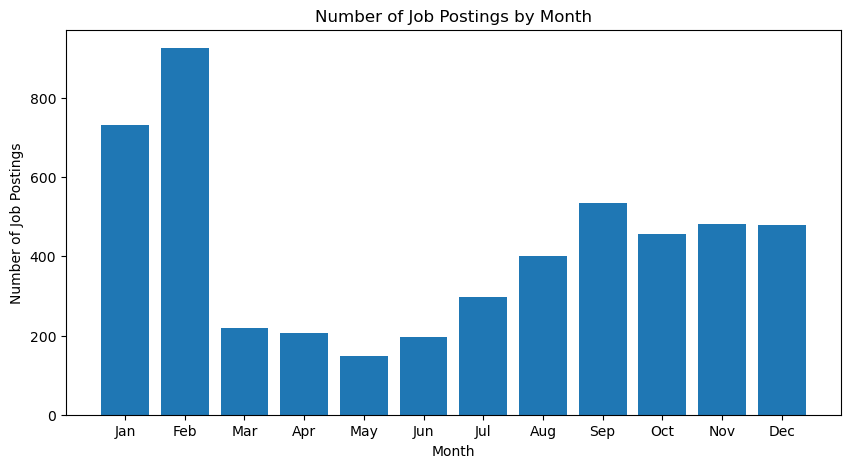

In [84]:
# Extract month from posting date
df['Posting_Month'] = df['Posting Date'].dt.month

# Count job postings by month
month_counts = df['Posting_Month'].value_counts().sort_index()

# Create bar chart
plt.figure(figsize=(10, 5))
plt.bar(month_counts.index, month_counts.values)

plt.title('Number of Job Postings by Month')
plt.xlabel('Month')
plt.ylabel('Number of Job Postings')

plt.xticks(
    range(1, 13),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)

plt.show()

February has the highest number of job postings.
January and September also have relatively high postings.
March has the lowest number of postings.

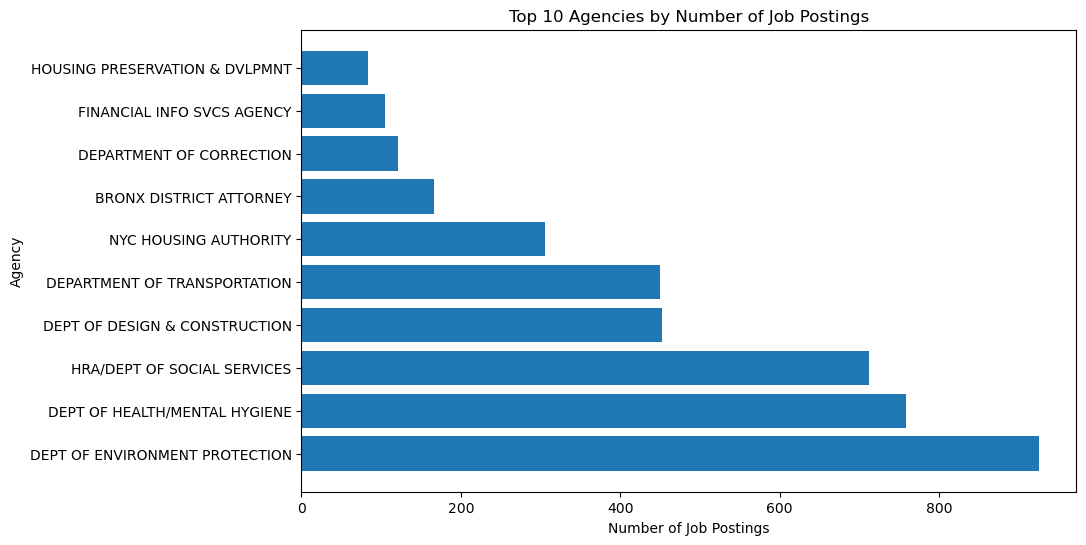

In [85]:
agency_counts = df['Agency'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(agency_counts.index, agency_counts.values)

plt.title('Top 10 Agencies by Number of Job Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('Agency')

plt.show()

Executive roles have the highest median salary and the widest salary range.
Manager roles generally have the second-highest salaries.
Experienced (non-manager) roles have a median salary around 65K, but several high-salary outliers exist.
Entry-Level roles generally have lower salaries, with a median around 50K.
Student positions have the lowest salary distribution.

This shows the trend: salary increases with career seniority.

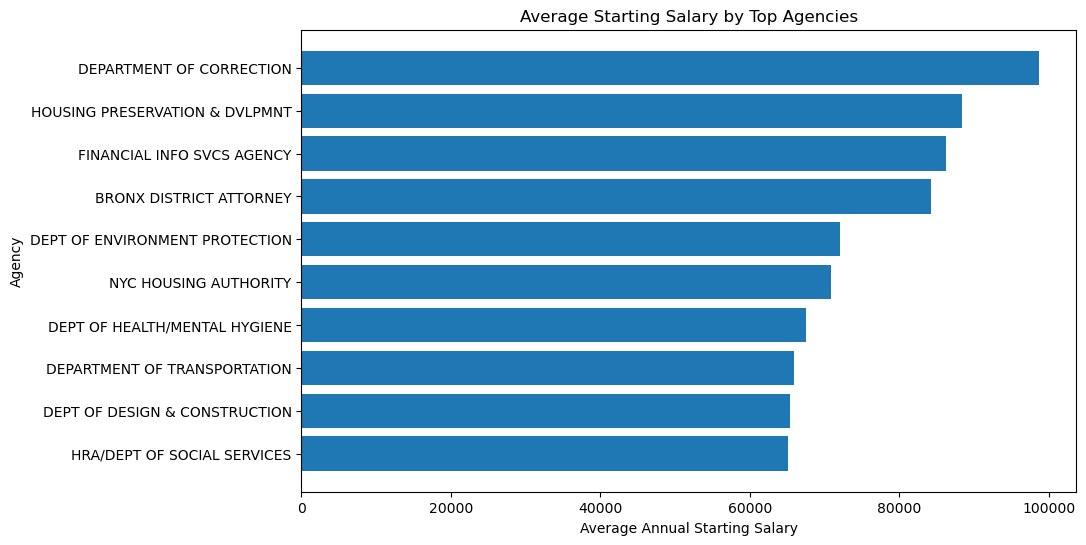

In [86]:
top_agencies = df['Agency'].value_counts().head(10).index

agency_salary = (
    df[df['Agency'].isin(top_agencies)]
    .groupby('Agency')['Annual_Salary_Range_From']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(agency_salary.index, agency_salary.values)

plt.title('Average Starting Salary by Top Agencies')
plt.xlabel('Average Annual Starting Salary')
plt.ylabel('Agency')

plt.show()

Department of Correction has the highest average starting salary, at approximately 98K.
Housing Preservation & Development follows at around 88K.
Financial Information Services Agency and the Bronx District Attorney are also relatively high, around 84K–86K.
HRA/Department of Social Services, Department of Design & Construction, and Department of Transportation have lower average starting salaries among these top agencies, around 65K.

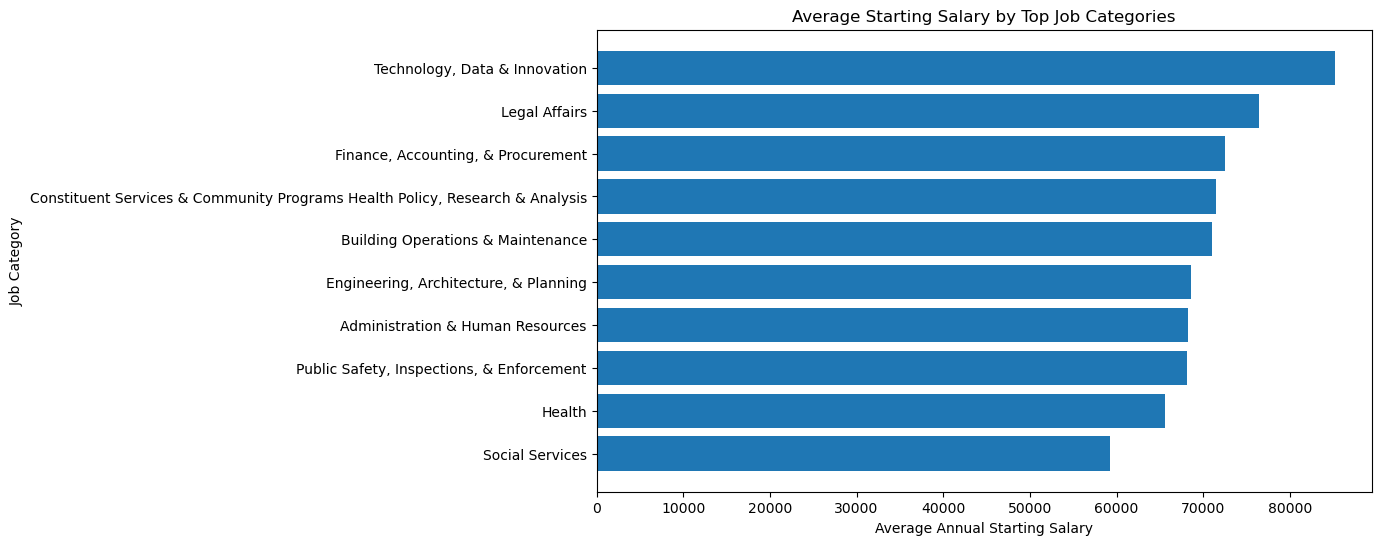

In [87]:
top_categories = df['Job Category'].value_counts().head(10).index

category_salary = (
    df[df['Job Category'].isin(top_categories)]
    .groupby('Job Category')['Annual_Salary_Range_From']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(category_salary.index, category_salary.values)

plt.title('Average Starting Salary by Top Job Categories')
plt.xlabel('Average Annual Starting Salary')
plt.ylabel('Job Category')

plt.show()

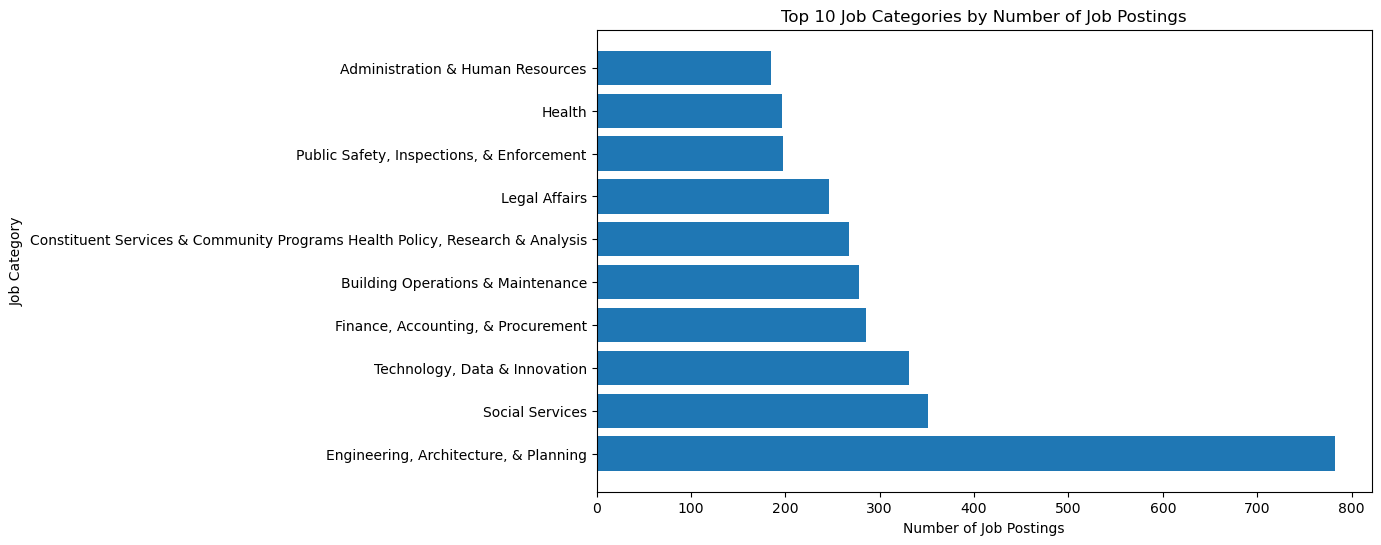

In [88]:
category_counts = df['Job Category'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(category_counts.index, category_counts.values)

plt.title('Top 10 Job Categories by Number of Job Postings')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Category')

plt.show()

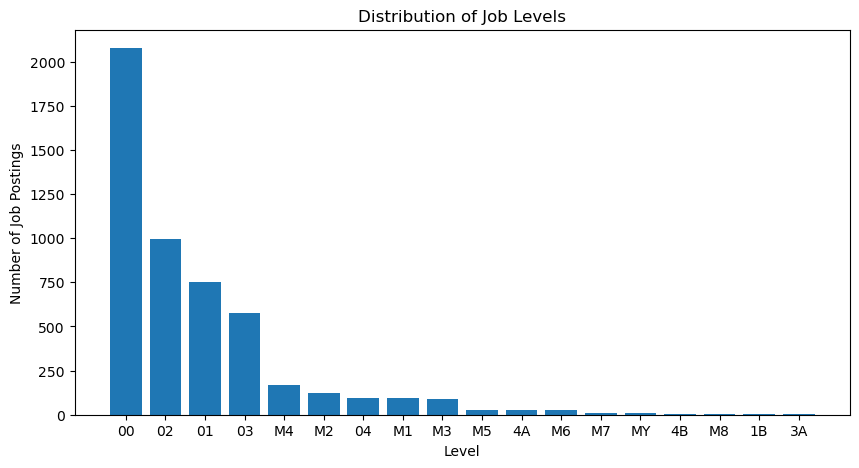

In [89]:
level_counts = df['Level'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(level_counts.index.astype(str), level_counts.values)

plt.title('Distribution of Job Levels')
plt.xlabel('Level')
plt.ylabel('Number of Job Postings')
plt.show()

In [90]:
# Analyze average and median minimum salary by job level
level_salary = (
    df.groupby('Level')['Annual_Salary_Range_From']
    .agg(['mean', 'median', 'count'])
    .sort_values('mean', ascending=False)
)

level_salary

,mean,median,count
Level,,,
M6,192809.666667,197500.0,24
M8,170753.000000,170753.0,4
M7,138437.400000,106729.0,10
M5,123271.642857,113593.5,28
M4,111950.315789,88437.0,171
4A,106830.916667,103026.0,24
MY,105925.000000,107500.0,8
4B,105746.000000,105746.0,4
M3,87666.853933,72038.0,89


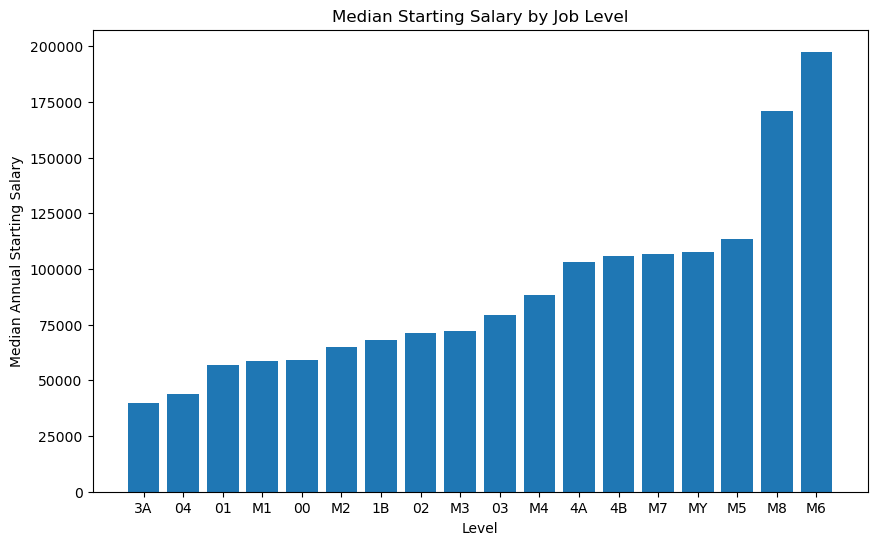

In [91]:
# Visualize median starting salary across different job levels

level_median_salary = (
    df.groupby('Level')['Annual_Salary_Range_From']
    .median()
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.bar(
    level_median_salary.index.astype(str),
    level_median_salary.values
)

plt.title('Median Starting Salary by Job Level')
plt.xlabel('Level')
plt.ylabel('Median Annual Starting Salary')

plt.show()

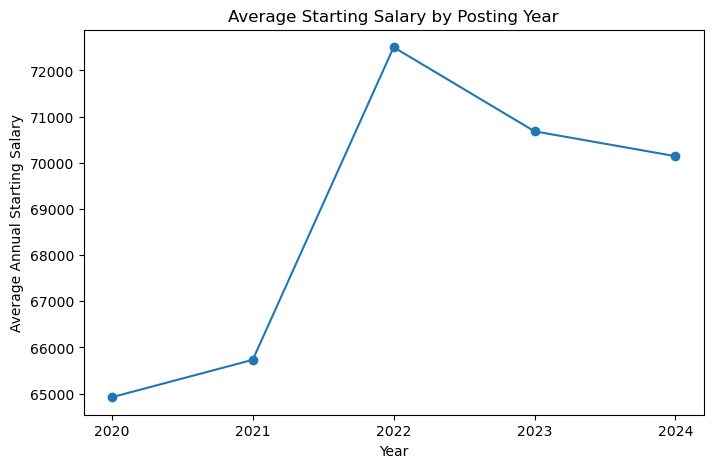

In [92]:
year_salary = df.groupby('Posting_Year')['Annual_Salary_Range_From'].mean()

plt.figure(figsize=(8, 5))
plt.plot(year_salary.index, year_salary.values, marker='o')

plt.title('Average Starting Salary by Posting Year')
plt.xlabel('Year')
plt.ylabel('Average Annual Starting Salary')

plt.xticks(year_salary.index)
plt.show()

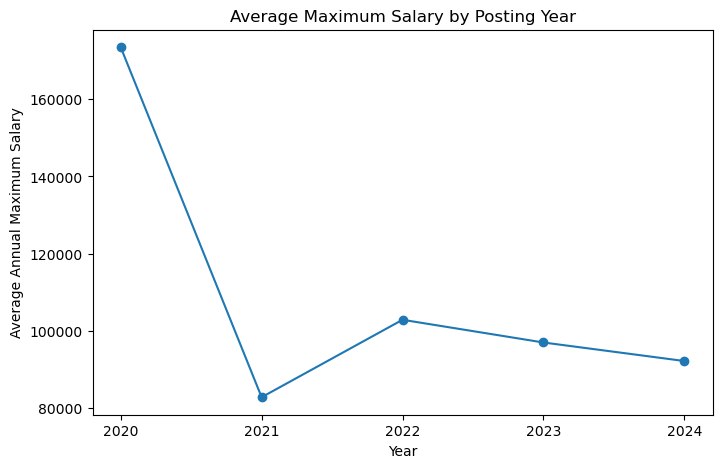

In [93]:
year_salary_to = df.groupby('Posting_Year')['Annual_Salary_Range_To'].mean()

plt.figure(figsize=(8, 5))
plt.plot(year_salary_to.index, year_salary_to.values, marker='o')

plt.title('Average Maximum Salary by Posting Year')
plt.xlabel('Year')
plt.ylabel('Average Annual Maximum Salary')

plt.xticks(year_salary_to.index)
plt.show()

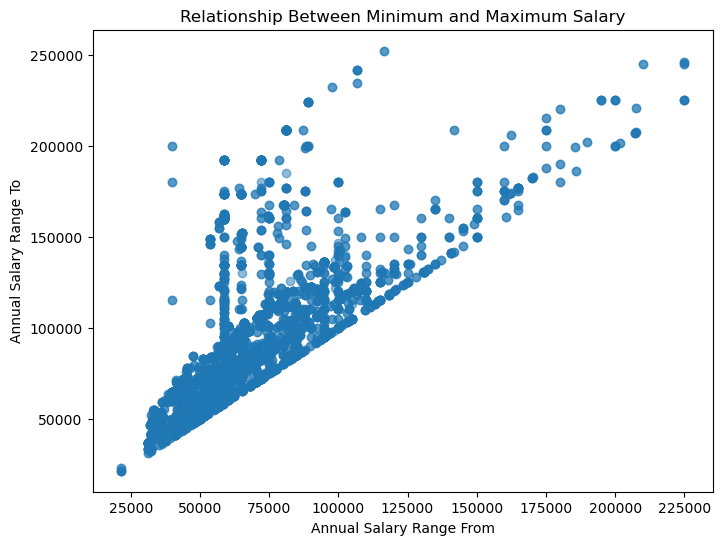

In [94]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Annual_Salary_Range_From'],
    df['Annual_Salary_Range_To'],
    alpha=0.5
)

plt.title('Relationship Between Minimum and Maximum Salary')
plt.xlabel('Annual Salary Range From')
plt.ylabel('Annual Salary Range To')

plt.show()

The scatter plot shows a strong positive relationship between the minimum and maximum annual salary ranges. Jobs offering higher starting salaries generally also offer higher maximum salaries, although several high-salary outliers are present.

### Key Findings from Exploratory Data Analysis

1. The dataset contains job postings from June 2020 to December 2024.

2. Most job postings were made in 2023, followed by 2024. There were comparatively fewer postings in 2020, 2021, and 2022.

3. February had the highest number of job postings, while March had the lowest.

4. Most job postings required residency, while a smaller number did not require residency.

5. Annual starting and maximum salary distributions were positively skewed, with several high-salary outliers.

6. Executive and Manager positions generally had higher salary ranges compared to Entry-Level, Student, and Experienced (Non-manager) positions.

7. The average starting salary increased until 2022 and then showed a moderate decline in 2023 and 2024.

8. The average maximum salary was unusually high in 2020, but this should be interpreted cautiously because there were very few job postings during that year.

9. Technology, Data & Innovation had the highest average starting salary among the top job categories analyzed.

10. Engineering, Architecture, & Planning had the highest number of job postings among the top job categories.

11. The correlation between Annual_Salary_Range_From and Annual_Salary_Range_To was 0.679, indicating a moderately strong positive relationship.

In [95]:
print(df.columns.tolist())

['Job ID', 'Agency', 'Posting Type', '# Of Positions', 'Business Title', 'Civil Service Title', 'Title Classification', 'Title Code No', 'Level', 'Job Category', 'Full-Time/Part-Time indicator', 'Career Level', 'Salary Range From', 'Salary Range To', 'Salary Frequency', 'Work Location', 'Division/Work Unit', 'Job Description', 'Minimum Qual Requirements', 'Preferred Skills', 'Additional Information', 'To Apply', 'Residency Requirement', 'Posting Date', 'Posting Updated', 'Process Date', 'Annual_Salary_Range_From', 'Annual_Salary_Range_To', 'Salary_Range_Difference', 'Education_Level', 'Min_Experience_Years', 'Experience_Required', 'Management_Experience_Required', 'Posting_Year', 'Posting_Month']


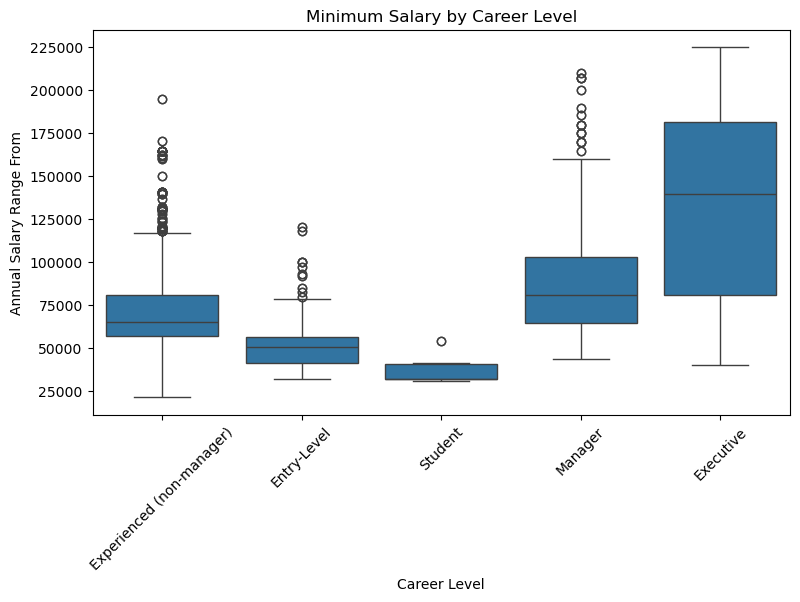

In [96]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Career Level',
    y='Annual_Salary_Range_From'
)

plt.title('Minimum Salary by Career Level')
plt.xlabel('Career Level')
plt.ylabel('Annual Salary Range From')

plt.xticks(rotation=45)
plt.show()

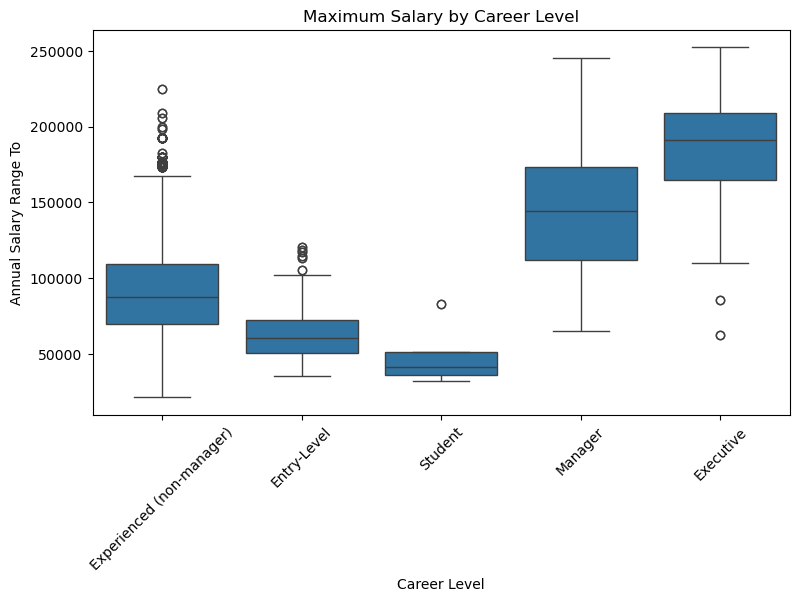

In [97]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Career Level',
    y='Annual_Salary_Range_To'
)

plt.title('Maximum Salary by Career Level')
plt.xlabel('Career Level')
plt.ylabel('Annual Salary Range To')

plt.xticks(rotation=45)
plt.show()

Career level shows a strong association with salary range. Higher career levels, particularly Manager and Executive roles, generally have higher minimum and maximum salaries, making Career Level a potentially important feature for salary range prediction.

In [98]:
features = [
    'Agency',
    'Posting Type',
    '# Of Positions',
    'Business Title',
    'Civil Service Title',
    'Title Classification',
    'Title Code No',
    'Level',
    'Job Category',
    'Full-Time/Part-Time indicator',
    'Career Level',
    'Work Location',
    'Division/Work Unit',
    'Education_Level',
    'Min_Experience_Years',
    'Management_Experience_Required',
    'Experience_Required',
    'Posting_Year',
    'Posting_Month'
]

In [99]:
categorical_cols = df[features].select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Agency: 59 unique values
Posting Type: 2 unique values
Business Title: 1686 unique values
Civil Service Title: 364 unique values
Title Classification: 5 unique values
Title Code No: 387 unique values
Level: 18 unique values
Job Category: 183 unique values
Full-Time/Part-Time indicator: 3 unique values
Career Level: 5 unique values
Work Location: 292 unique values
Division/Work Unit: 849 unique values
Education_Level: 6 unique values
Management_Experience_Required: 2 unique values
Experience_Required: 2 unique values


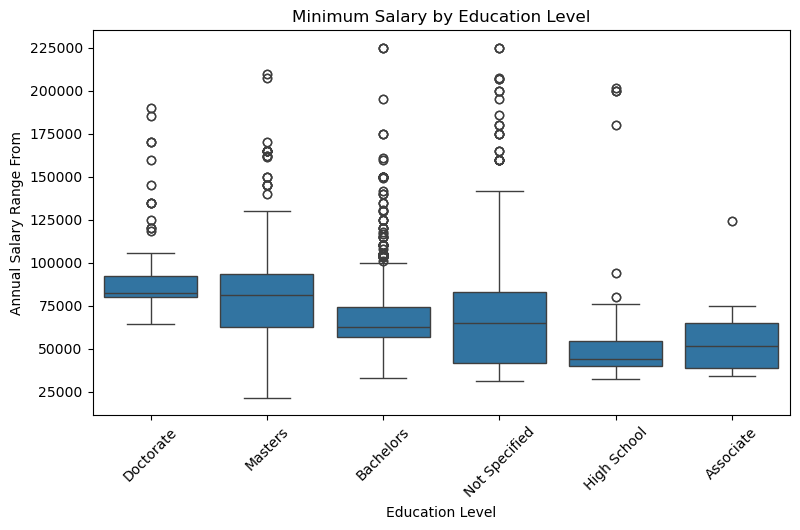

In [100]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Education_Level',
    y='Annual_Salary_Range_From'
)

plt.title('Minimum Salary by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Annual Salary Range From')

plt.xticks(rotation=45)
plt.show()

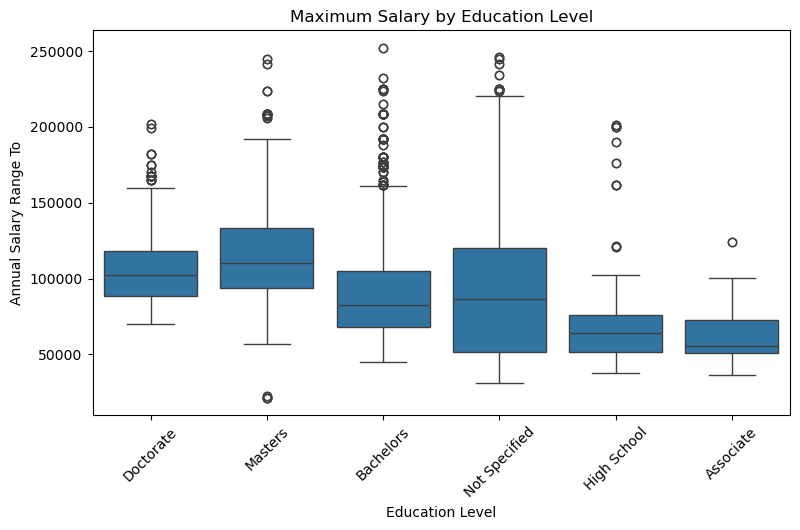

In [101]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Education_Level',
    y='Annual_Salary_Range_To'
)

plt.title('Maximum Salary by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Annual Salary Range To')

plt.xticks(rotation=45)
plt.show()

Education level appears to have a relationship with salary. Master's and Doctorate generally show higher salary ranges, while High School and Associate tend to have lower ranges. There is also substantial variation and several outliers.

In [102]:
posting_type_counts = df['Posting Type'].value_counts()

posting_type_counts

Posting Type
Internal    2583
External    2496
Name: count, dtype: int64

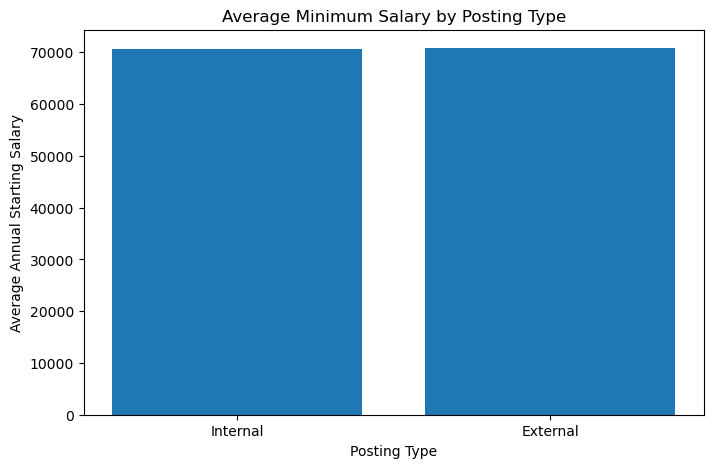

In [103]:
posting_type_salary = (
    df.groupby('Posting Type')['Annual_Salary_Range_From']
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
plt.bar(
    posting_type_salary.index,
    posting_type_salary.values
)

plt.title('Average Minimum Salary by Posting Type')
plt.xlabel('Posting Type')
plt.ylabel('Average Annual Starting Salary')

plt.show()

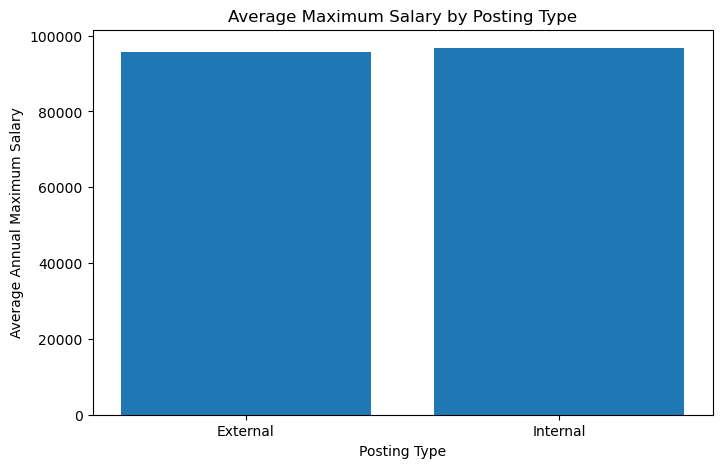

In [104]:
posting_type_salary = (
    df.groupby('Posting Type')['Annual_Salary_Range_To']
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
plt.bar(
    posting_type_salary.index,
    posting_type_salary.values
)

plt.title('Average Maximum Salary by Posting Type')
plt.xlabel('Posting Type')
plt.ylabel('Average Annual Maximum Salary')

plt.show()

Posting Type does not appear to have a strong relationship with starting salary.

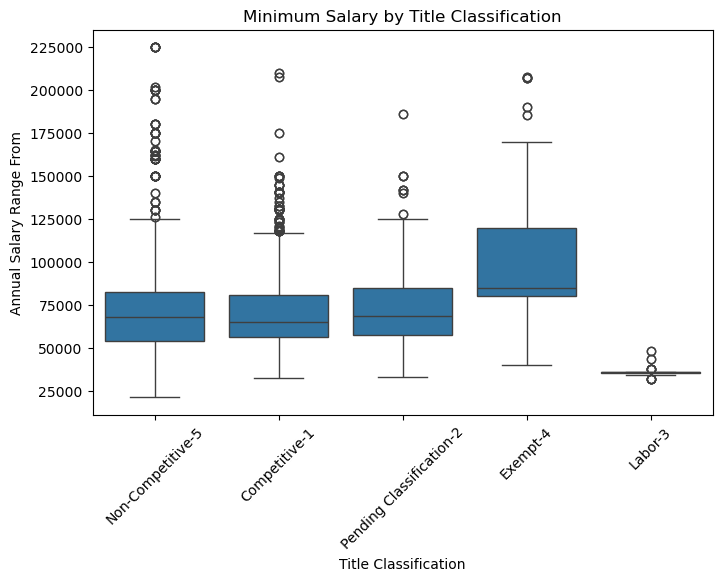

In [105]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Title Classification',
    y='Annual_Salary_Range_From'
)

plt.title('Minimum Salary by Title Classification')
plt.xlabel('Title Classification')
plt.ylabel('Annual Salary Range From')

plt.xticks(rotation=45)
plt.show()

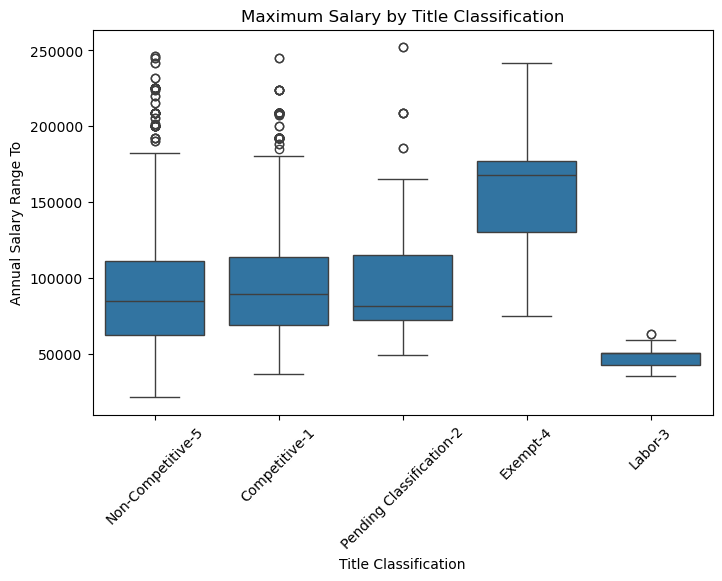

In [106]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Title Classification',
    y='Annual_Salary_Range_To'
)

plt.title('Maximum Salary by Title Classification')
plt.xlabel('Title Classification')
plt.ylabel('Annual Salary Range To')

plt.xticks(rotation=45)
plt.show()

Title classification shows a strong association with salary range. Exempt positions generally have the highest median minimum and maximum salaries, while Labor positions have the lowest. Competitive, Non-Competitive, and Pending Classification positions show relatively similar salary distributions, although all categories contain some high-salary outliers.

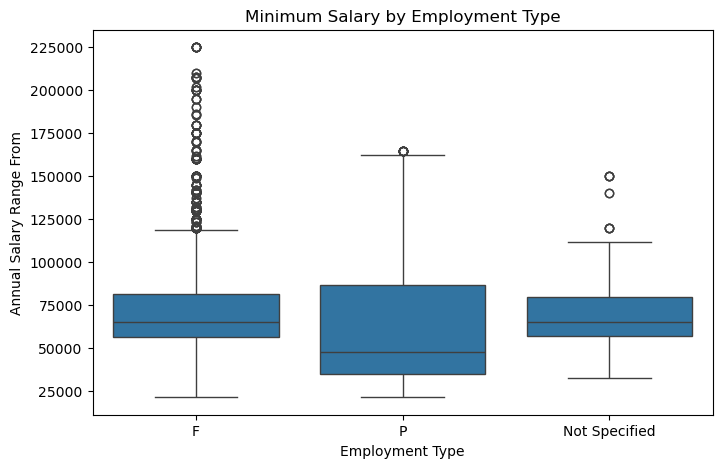

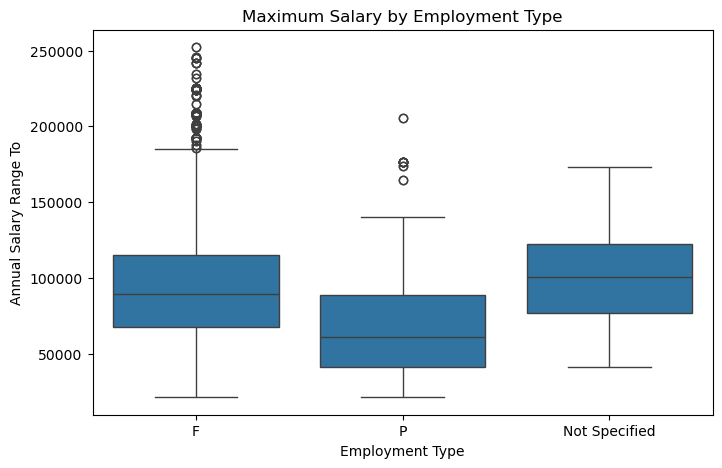

In [107]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Full-Time/Part-Time indicator',
    y='Annual_Salary_Range_From'
)

plt.title('Minimum Salary by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Annual Salary Range From')

plt.show()


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Full-Time/Part-Time indicator',
    y='Annual_Salary_Range_To'
)

plt.title('Maximum Salary by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Annual Salary Range To')

plt.show()

Employment type appears to be associated with salary range. Part-time positions generally have lower median minimum and maximum salaries than full-time positions. 

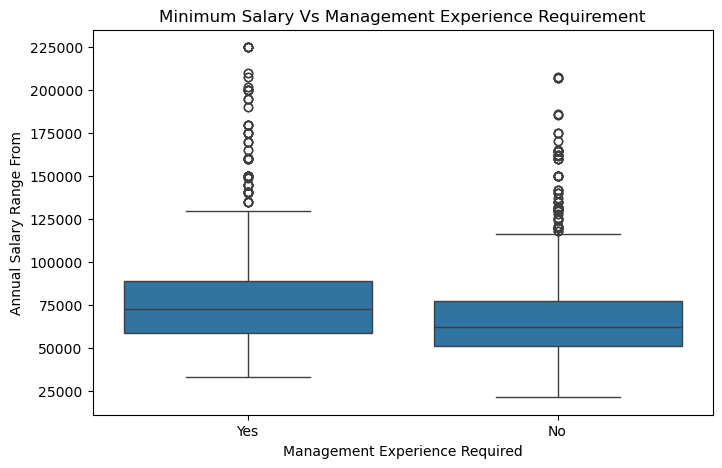

In [108]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Management_Experience_Required',
    y='Annual_Salary_Range_From'
)

plt.title('Minimum Salary Vs Management Experience Requirement')
plt.xlabel('Management Experience Required')
plt.ylabel('Annual Salary Range From')

plt.show()

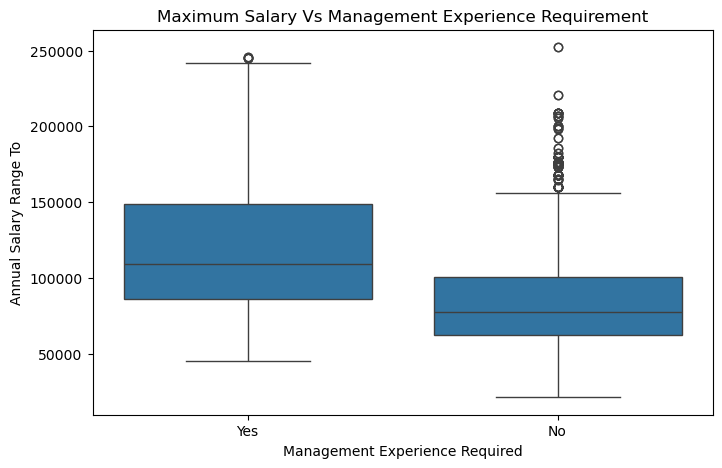

In [109]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Management_Experience_Required',
    y='Annual_Salary_Range_To'
)

plt.title('Maximum Salary Vs Management Experience Requirement')
plt.xlabel('Management Experience Required')
plt.ylabel('Annual Salary Range To')

plt.show()

Management experience is associated with higher salary ranges. Job postings requiring management experience generally have higher median minimum and maximum salaries compared to postings that do not require management experience.

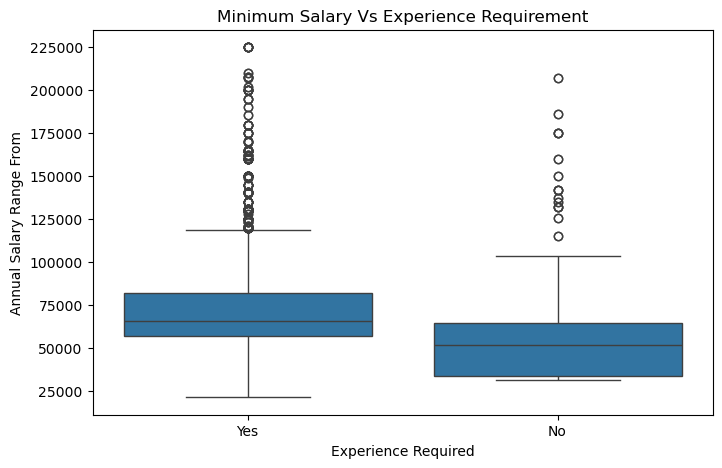

In [110]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Experience_Required',
    y='Annual_Salary_Range_From'
)

plt.title('Minimum Salary Vs Experience Requirement')
plt.xlabel('Experience Required')
plt.ylabel('Annual Salary Range From')

plt.show()

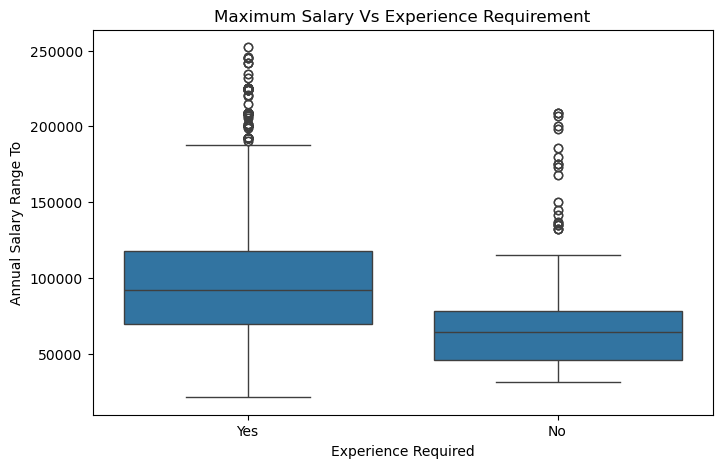

In [111]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Experience_Required',
    y='Annual_Salary_Range_To'
)

plt.title('Maximum Salary Vs Experience Requirement')
plt.xlabel('Experience Required')
plt.ylabel('Annual Salary Range To')

plt.show()

Jobs requiring prior experience generally offer higher minimum and maximum salary ranges. The salary distributions are also wider for positions requiring experience, indicating greater variation in salary levels.

In [112]:
df['Job Category'].value_counts().head(15)

Job Category
Engineering, Architecture, & Planning                                              782
Social Services                                                                    351
Technology, Data & Innovation                                                      331
Finance, Accounting, & Procurement                                                 285
Building Operations & Maintenance                                                  278
Constituent Services & Community Programs Health Policy, Research & Analysis       267
Legal Affairs                                                                      246
Public Safety, Inspections, & Enforcement                                          198
Health                                                                             197
Administration & Human Resources                                                   185
Administration & Human Resources Social Services                                   165
Engineering, Architecture, & P

In [113]:
top_15_categories = df['Job Category'].value_counts().head(15).index

top_15_df = df[df['Job Category'].isin(top_15_categories)]

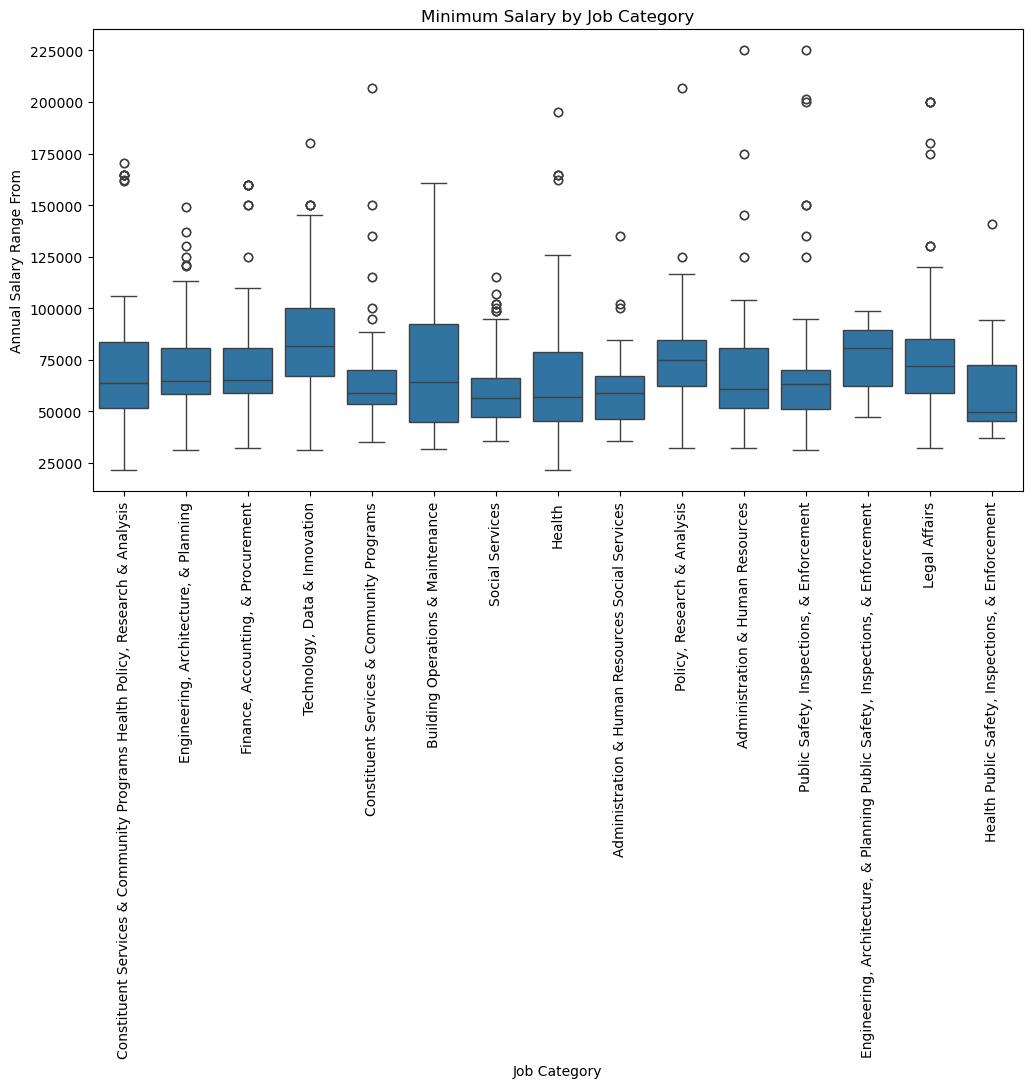

In [114]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=top_15_df,
    x='Job Category',
    y='Annual_Salary_Range_From'
)

plt.title('Minimum Salary by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Annual Salary Range From')

plt.xticks(rotation=90)
plt.show()

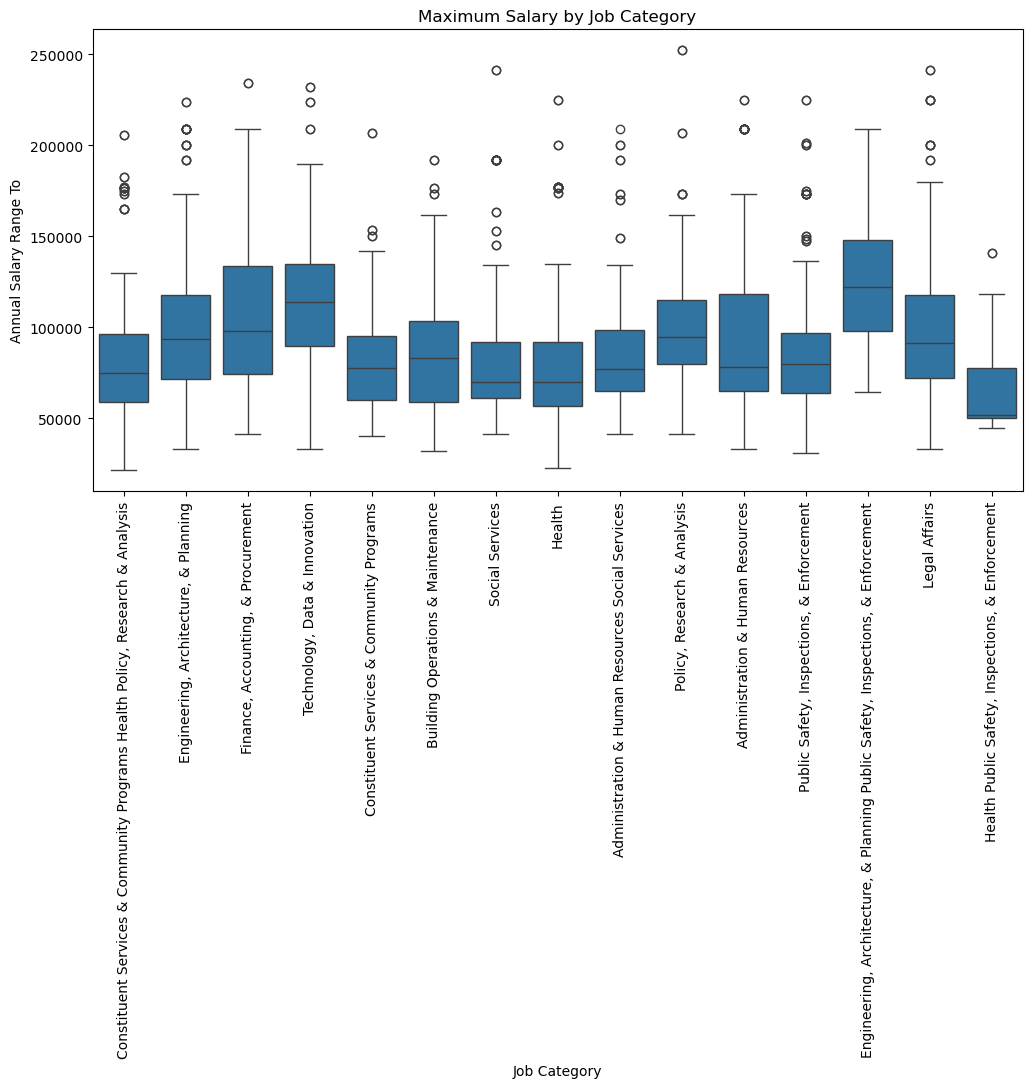

In [115]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=top_15_df,
    x='Job Category',
    y='Annual_Salary_Range_To'
)

plt.title('Maximum Salary by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Annual Salary Range To')

plt.xticks(rotation=90)
plt.show()

ranges, indicating that job category is an important feature for salary range prediction. However, due to its high number of unique categories, appropriate encoding will be required before model training.

In [116]:

top_20_locations = df['Work Location'].value_counts().head(20).index

top_20_df = df[df['Work Location'].isin(top_20_locations)]

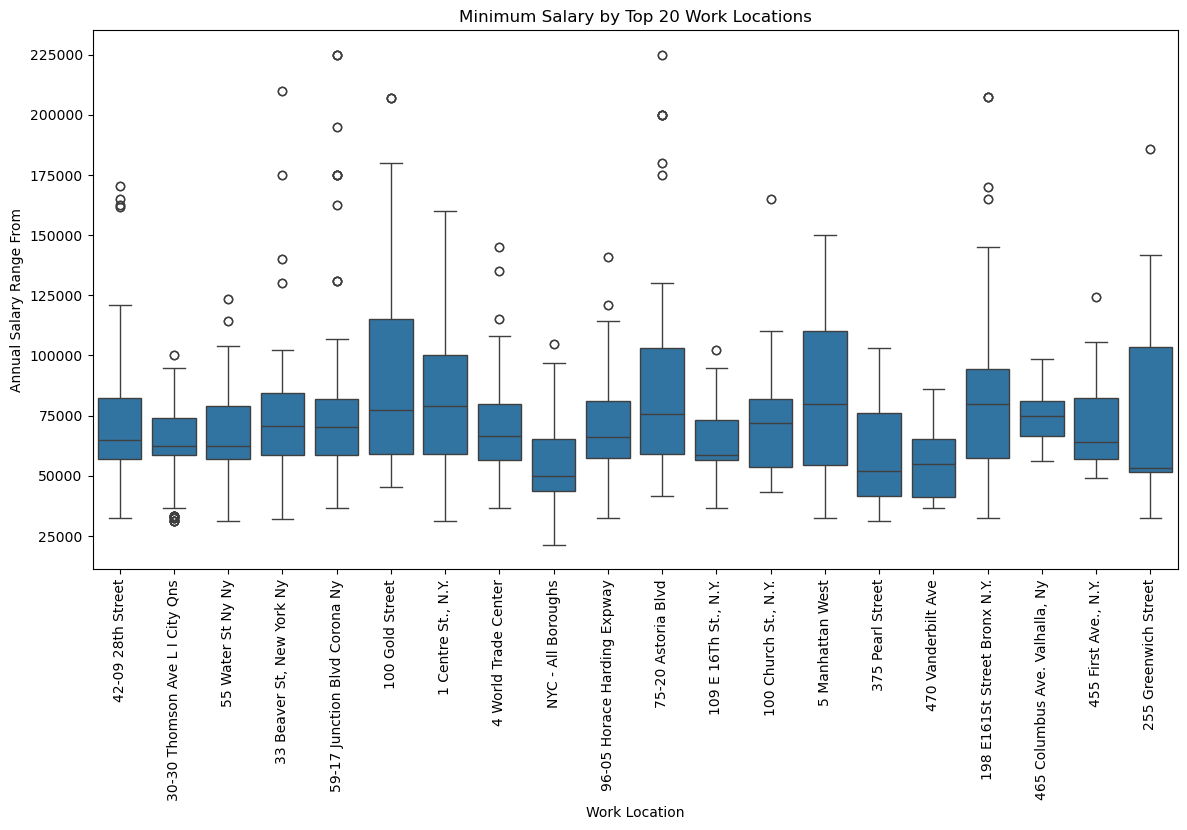

In [117]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=top_20_df,
    x='Work Location',
    y='Annual_Salary_Range_From'
)

plt.title('Minimum Salary by Top 20 Work Locations')
plt.xlabel('Work Location')
plt.ylabel('Annual Salary Range From')

plt.xticks(rotation=90)
plt.show()

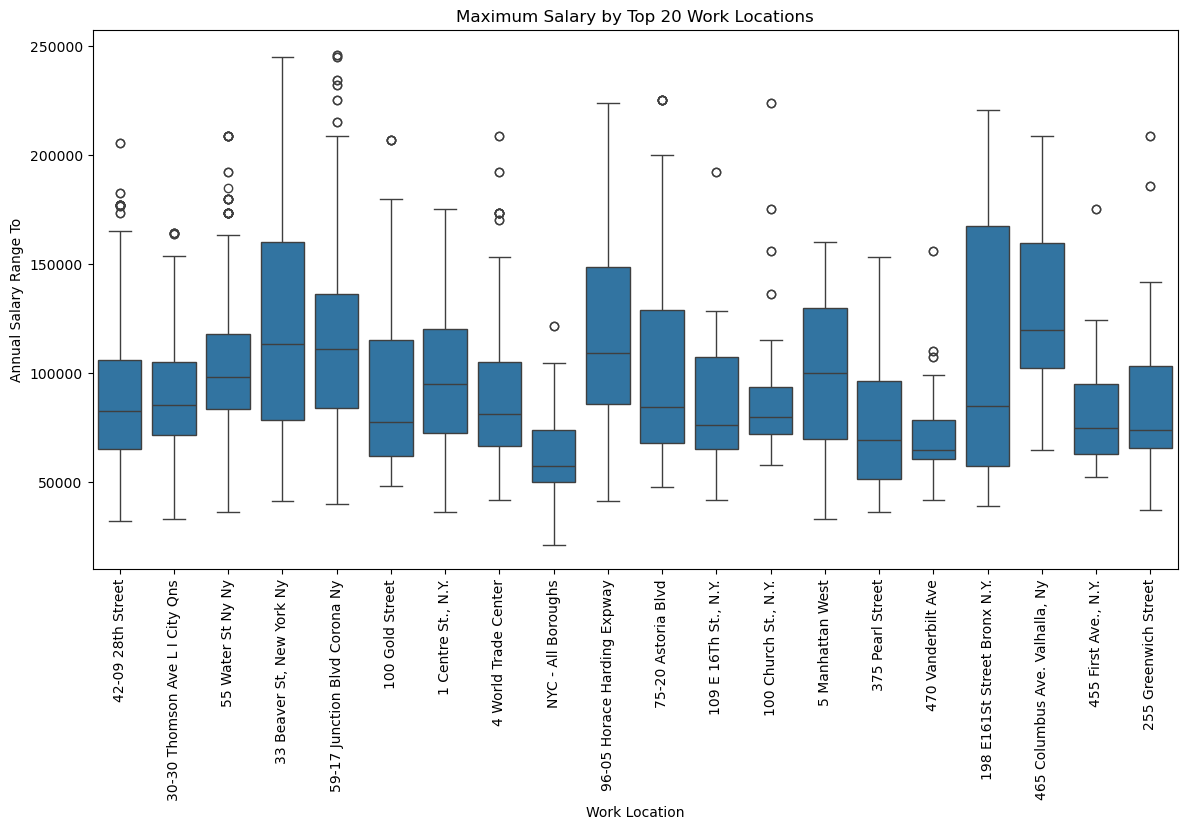

In [118]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=top_20_df,
    x='Work Location',
    y='Annual_Salary_Range_To'
)

plt.title('Maximum Salary by Top 20 Work Locations')
plt.xlabel('Work Location')
plt.ylabel('Annual Salary Range To')

plt.xticks(rotation=90)
plt.show()

In [119]:
top_15_agencies = df['Agency'].value_counts().head(15).index

top_15_agency_df = df[df['Agency'].isin(top_15_agencies)]

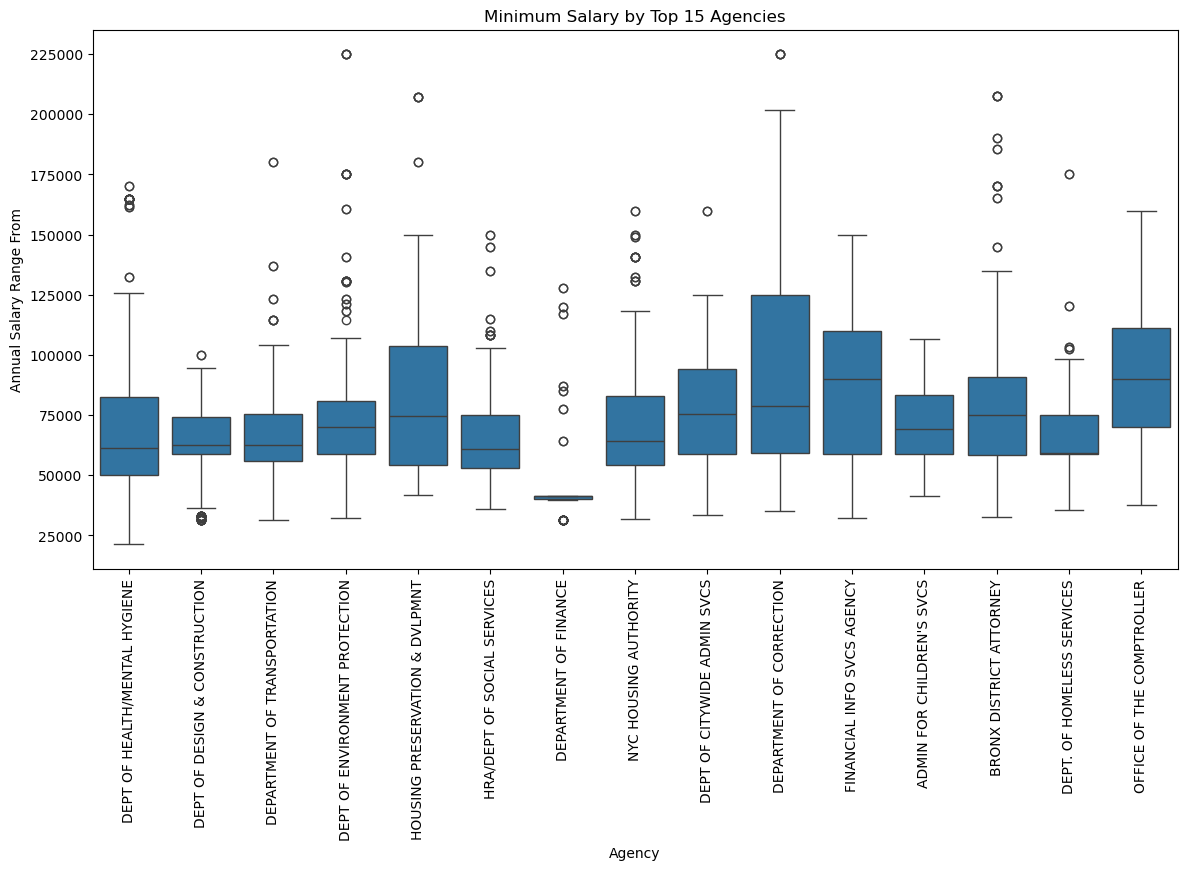

In [120]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=top_15_agency_df,
    x='Agency',
    y='Annual_Salary_Range_From'
)

plt.title('Minimum Salary by Top 15 Agencies')
plt.xlabel('Agency')
plt.ylabel('Annual Salary Range From')
plt.xticks(rotation=90)

plt.show()

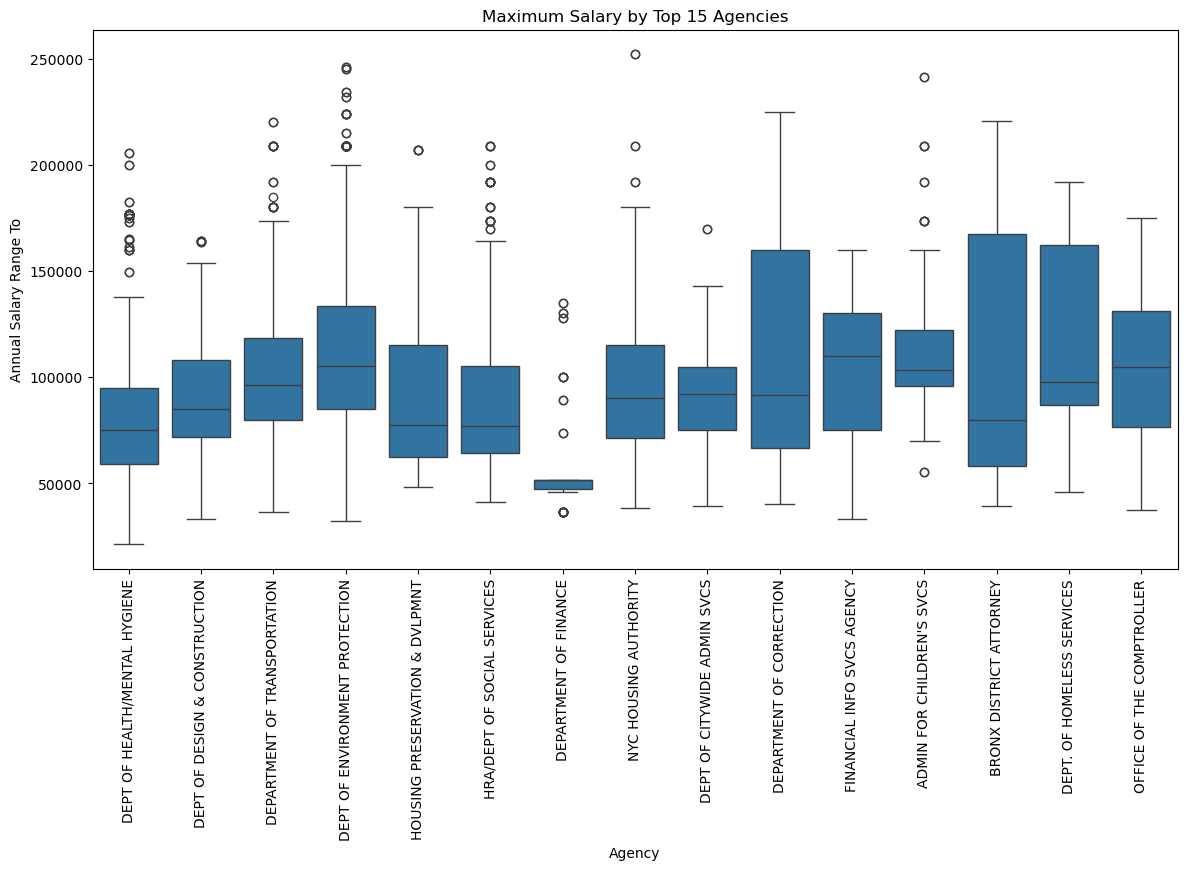

In [121]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=top_15_agency_df,
    x='Agency',
    y='Annual_Salary_Range_To'
)

plt.title('Maximum Salary by Top 15 Agencies')
plt.xlabel('Agency')
plt.ylabel('Annual Salary Range To')
plt.xticks(rotation=90)

plt.show()

Agency appears to be an important categorical feature because salary ranges vary across agencies.

In [122]:
df['Civil Service Title'].nunique()

364

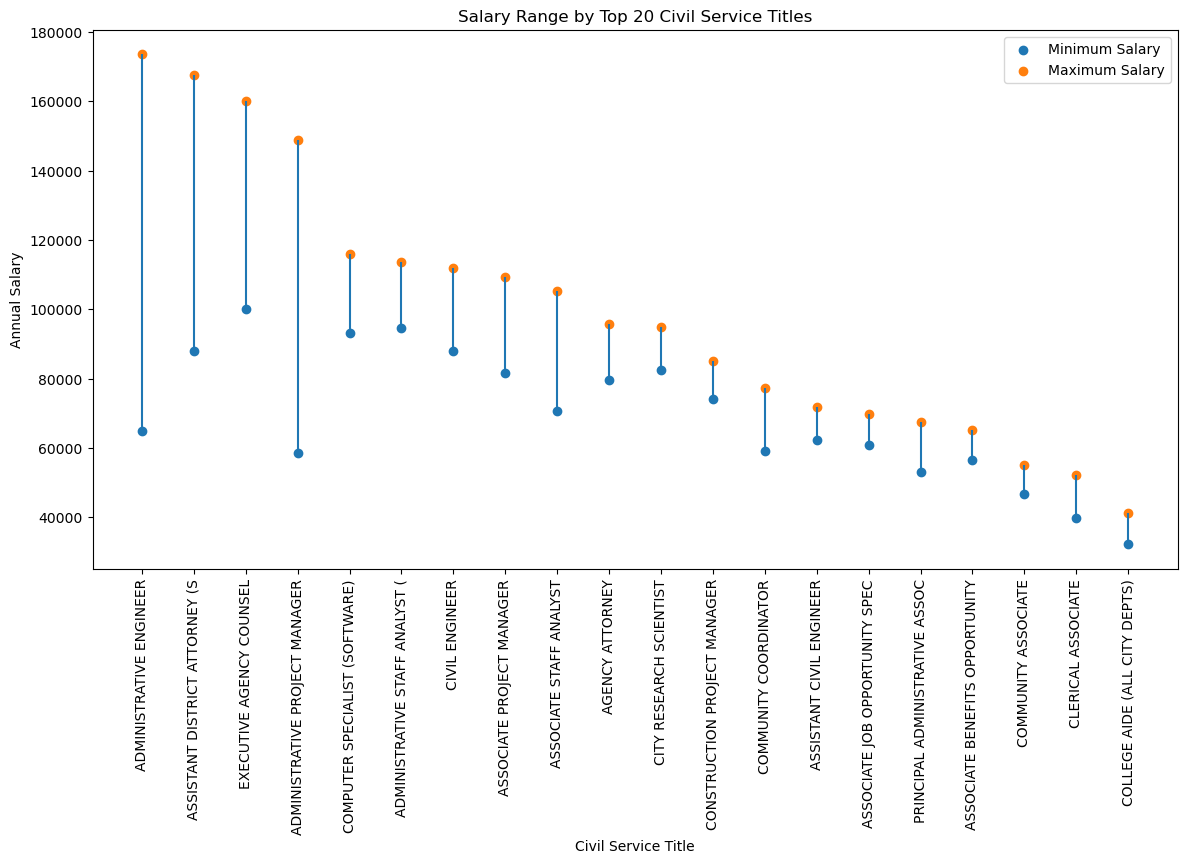

In [123]:
top_20_titles = df['Civil Service Title'].value_counts().head(20).index

plot_df = df[df['Civil Service Title'].isin(top_20_titles)]

salary_range = plot_df.groupby('Civil Service Title').agg(
    Min_Salary=('Annual_Salary_Range_From', 'median'),
    Max_Salary=('Annual_Salary_Range_To', 'median')
).reset_index()

salary_range = salary_range.sort_values('Max_Salary', ascending=False)

plt.figure(figsize=(14, 7))

plt.vlines(
    x=salary_range['Civil Service Title'],
    ymin=salary_range['Min_Salary'],
    ymax=salary_range['Max_Salary']
)

plt.scatter(
    salary_range['Civil Service Title'],
    salary_range['Min_Salary'],
    label='Minimum Salary'
)

plt.scatter(
    salary_range['Civil Service Title'],
    salary_range['Max_Salary'],
    label='Maximum Salary'
)

plt.title('Salary Range by Top 20 Civil Service Titles')
plt.xlabel('Civil Service Title')
plt.ylabel('Annual Salary')

plt.xticks(rotation=90)
plt.legend()
plt.show()

The Top 20 Civil Service Titles show significant variation in salary ranges. Specialized and senior roles generally offer higher salaries, while entry-level roles have lower salary ranges.

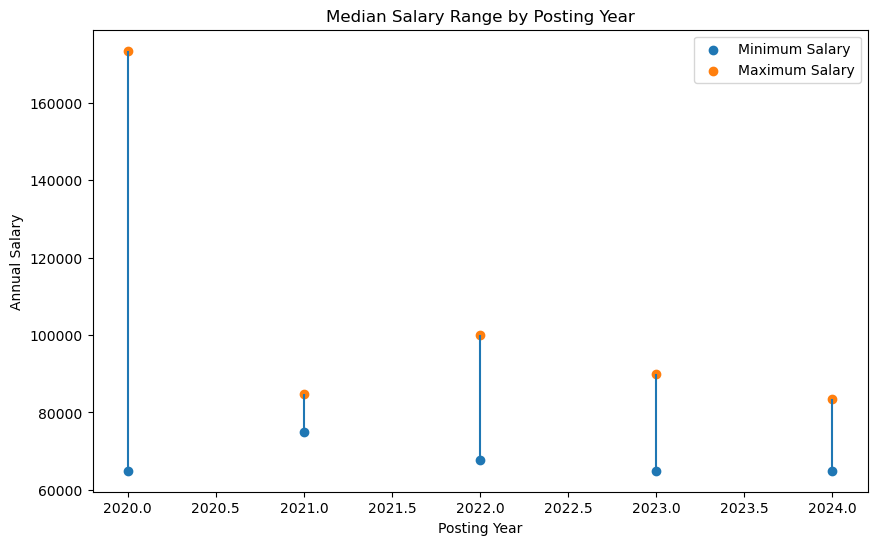

In [124]:
salary_year = df.groupby('Posting_Year').agg(
    Min_Salary=('Annual_Salary_Range_From', 'median'),
    Max_Salary=('Annual_Salary_Range_To', 'median')
).reset_index()

plt.figure(figsize=(10, 6))

plt.vlines(
    x=salary_year['Posting_Year'],
    ymin=salary_year['Min_Salary'],
    ymax=salary_year['Max_Salary']
)

plt.scatter(
    salary_year['Posting_Year'],
    salary_year['Min_Salary'],
    label='Minimum Salary'
)

plt.scatter(
    salary_year['Posting_Year'],
    salary_year['Max_Salary'],
    label='Maximum Salary'
)

plt.title('Median Salary Range by Posting Year')
plt.xlabel('Posting Year')
plt.ylabel('Annual Salary')

plt.legend()
plt.show()

The median salary range was highest in 2020, with a significant drop in later years. From 2021 to 2024, the salary ranges remained relatively more stable, generally between around 65,000 and 100,000.

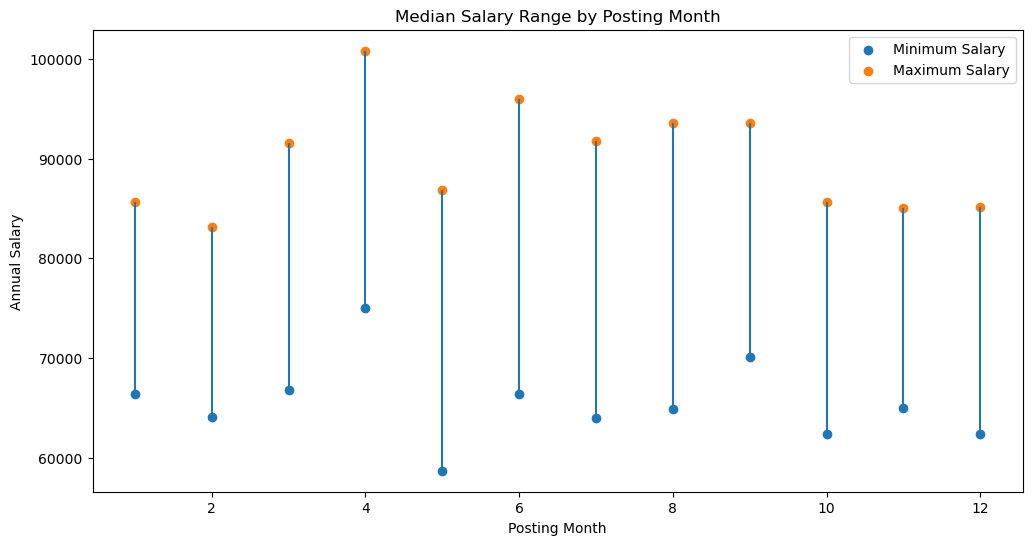

In [125]:
salary_month = df.groupby('Posting_Month').agg(
    Min_Salary=('Annual_Salary_Range_From', 'median'),
    Max_Salary=('Annual_Salary_Range_To', 'median')
).reset_index()

plt.figure(figsize=(12, 6))

plt.vlines(
    x=salary_month['Posting_Month'],
    ymin=salary_month['Min_Salary'],
    ymax=salary_month['Max_Salary']
)

plt.scatter(
    salary_month['Posting_Month'],
    salary_month['Min_Salary'],
    label='Minimum Salary'
)

plt.scatter(
    salary_month['Posting_Month'],
    salary_month['Max_Salary'],
    label='Maximum Salary'
)

plt.title('Median Salary Range by Posting Month')
plt.xlabel('Posting Month')
plt.ylabel('Annual Salary')

plt.legend()
plt.show()

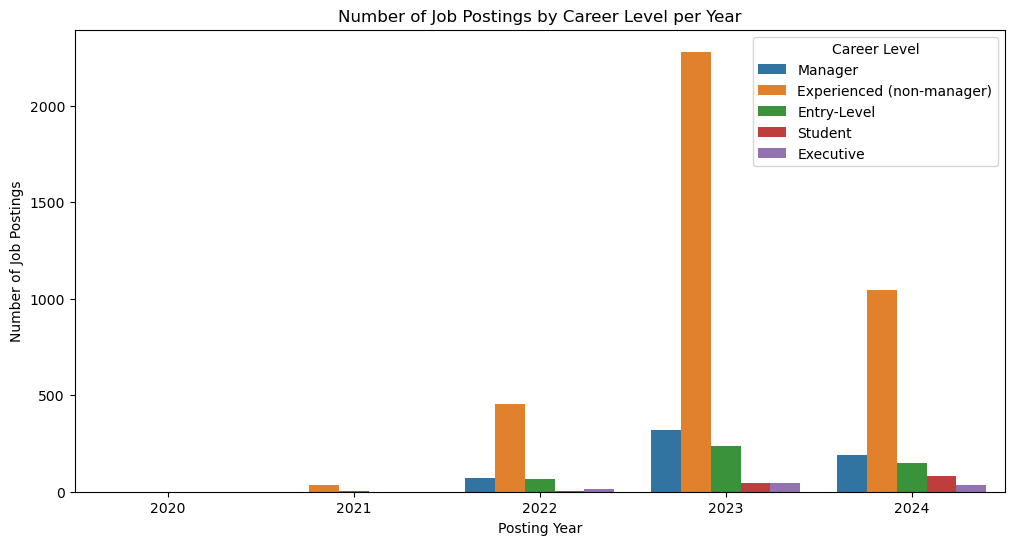

In [126]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x='Posting_Year',
    hue='Career Level'
)

plt.title('Number of Job Postings by Career Level per Year')
plt.xlabel('Posting Year')
plt.ylabel('Number of Job Postings')

plt.legend(title='Career Level')
plt.show()

In [127]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 4


In [128]:
df[df.duplicated(keep=False)].sort_values(
    by='Job ID'
)

Job ID                        Agency Posting Type  # Of Positions  \
4244  627087  DEPARTMENT OF TRANSPORTATION     Internal               1   
4461  627087  DEPARTMENT OF TRANSPORTATION     Internal               1   
126   627596  DEPARTMENT OF TRANSPORTATION     Internal               1   
4783  627596  DEPARTMENT OF TRANSPORTATION     Internal               1   
95    627951  DEPARTMENT OF TRANSPORTATION     Internal               1   
3006  627951  DEPARTMENT OF TRANSPORTATION     Internal               1   
600   628110  DEPARTMENT OF TRANSPORTATION     Internal               1   
2333  628110  DEPARTMENT OF TRANSPORTATION     Internal               1   

                       Business Title             Civil Service Title  \
4244                  AREA SUPERVISOR  AREA SUPERVISOR (HIGHWAY MAINT   
4461                  AREA SUPERVISOR  AREA SUPERVISOR (HIGHWAY MAINT   
126       OER - CLERICAL ASSOCIATE IV              CLERICAL ASSOCIATE   
4783      OER - CLERICAL ASSOCIATE IV              CLERICAL ASSOCIATE   
95    DIRECTOR FOR RIS ADMINISTRATION     ADM CITY PLANNER (NON MGRL)   
3006  DIRECTOR FOR RIS ADMINISTRATION     ADM CITY PLANNER (NON MGRL)   
600               EXECUTIVE ASSISTANT  PRINCIPAL ADMINISTRATIVE ASSOC   
2333              EXECUTIVE ASSISTANT  PRINCIPAL ADMINISTRATIVE ASSOC   

     Title Classification Title Code No Level  \
4244        Competitive-1         91352    01   
4461        Competitive-1         91352    01   
126         Competitive-1         10251    04   
4783        Competitive-1         10251    04   
95          Competitive-1         1005A    00   
3006        Competitive-1         1005A    00   
600         Competitive-1         10124    01   
2333        Competitive-1         10124    01   

                                                                     Job Category  \
4244  Building Operations & Maintenance Public Safety, Inspections, & Enforcement   
4461  Building Operations & Maintenance Public Safety, Inspections, & Enforcement   
126                                     Public Safety, Inspections, & Enforcement   
4783                                    Public Safety, Inspections, & Enforcement   
95         Administration & Human Resources Engineering, Architecture, & Planning   
3006       Administration & Human Resources Engineering, Architecture, & Planning   
600                                              Administration & Human Resources   
2333                                             Administration & Human Resources   

     Full-Time/Part-Time indicator               Career Level  \
4244                             F  Experienced (non-manager)   
4461                             F  Experienced (non-manager)   
126                              F  Experienced (non-manager)   
4783                             F  Experienced (non-manager)   
95                               F  Experienced (non-manager)   
3006                             F  Experienced (non-manager)   
600                              F  Experienced (non-manager)   
2333                             F  Experienced (non-manager)   

      Salary Range From  Salary Range To Salary Frequency  \
4244            74456.0         118530.0           Annual   
4461            74456.0         118530.0           Annual   
126             43728.0          68645.0           Annual   
4783            43728.0          68645.0           Annual   
95              58682.0         159671.0           Annual   
3006            58682.0         159671.0           Annual   
600             51816.0          75903.0           Annual   
2333            51816.0          75903.0           Annual   

                       Work Location              Division/Work Unit  \
4244    5 Dubois Ave., Staten Island    RRM Staten Island (Dubois 1)   
4461    5 Dubois Ave., Staten Island    RRM Staten Island (Dubois 1)   
126                55 Water St Ny Ny  Sidewalk/inspection Management   
4783               55 Water St Ny Ny  Si

In [129]:
df = df.drop_duplicates()

In [130]:
drop_cols = [
    'Job ID',
    'Salary Range From',
    'Salary Range To',
    'Salary Frequency',
    'Job Description',
    'Minimum Qual Requirements',
    'Preferred Skills',
    'Additional Information',
    'To Apply',
    'Residency Requirement',
    'Posting Date',
    'Posting Updated',
    'Process Date',
    'Min_Experience_Years'
]

In [131]:
df.select_dtypes(include='object').columns

Index(['Agency', 'Posting Type', 'Business Title', 'Civil Service Title',
       'Title Classification', 'Title Code No', 'Level', 'Job Category',
       'Full-Time/Part-Time indicator', 'Career Level', 'Salary Frequency',
       'Work Location', 'Division/Work Unit', 'Job Description',
       'Minimum Qual Requirements', 'Preferred Skills',
       'Additional Information', 'To Apply', 'Residency Requirement',
       'Posting Updated', 'Process Date', 'Education_Level',
       'Experience_Required', 'Management_Experience_Required'],
      dtype='object')

In [132]:
df= df.drop(columns=drop_cols)

In [133]:
missing = df.isnull().sum()

print("Columns with missing values:")
print(missing[missing > 0])

Columns with missing values:
Series([], dtype: int64)


In [134]:
df.dtypes

Agency                             object
Posting Type                       object
# Of Positions                      int64
Business Title                     object
Civil Service Title                object
Title Classification               object
Title Code No                      object
Level                              object
Job Category                       object
Full-Time/Part-Time indicator      object
Career Level                       object
Work Location                      object
Division/Work Unit                 object
Annual_Salary_Range_From          float64
Annual_Salary_Range_To            float64
Salary_Range_Difference           float64
Education_Level                    object
Experience_Required                object
Management_Experience_Required     object
Posting_Year                        int32
Posting_Month                       int32
dtype: object

In [135]:
print(df[['Annual_Salary_Range_From',
          'Annual_Salary_Range_To']].describe())

       Annual_Salary_Range_From  Annual_Salary_Range_To
count               5075.000000             5075.000000
mean               70715.335240            96160.332202
std                26595.878893            39821.143589
min                21379.800000            21379.800000
25%                55816.000000            67632.000000
50%                64922.000000            89003.000000
75%                81571.000000           115000.000000
max               225000.000000           252165.000000


In [136]:
print(
    "Invalid salary ranges:",
    (df['Annual_Salary_Range_From'] > df['Annual_Salary_Range_To']).sum()
)

Invalid salary ranges: 0


In [137]:
print("Final shape:", df.shape)

Final shape: (5075, 21)


## Feature Encoding

In [138]:
low_card_cols = [
    'Posting Type',
    'Title Classification',
    'Full-Time/Part-Time indicator',
    'Career Level',
    'Education_Level',
    'Experience_Required',
    'Management_Experience_Required'
]

df_encoded = pd.get_dummies(
    df,
    columns=low_card_cols,
    drop_first=True,
    dtype=int
)

In [139]:
X = df_encoded.drop(
    columns=[
        'Annual_Salary_Range_From',
        'Annual_Salary_Range_To',
        'Salary_Range_Difference'
    ]
)

y_from = df_encoded['Annual_Salary_Range_From']
y_to = df_encoded['Annual_Salary_Range_To']

In [140]:
X.select_dtypes(include='object').columns.tolist()

['Agency',
 'Business Title',
 'Civil Service Title',
 'Title Code No',
 'Level',
 'Job Category',
 'Work Location',
 'Division/Work Unit']

##  Split data into features & target variable

In [141]:
# Split the dataset into training and testing sets for both salary targets
X_train, X_test, y_from_train, y_from_test, y_to_train, y_to_test = train_test_split(
    X,
    y_from,
    y_to,
    test_size=0.2,
    random_state=42
)

In [142]:
high_card_cols = [
    'Agency',
    'Business Title',
    'Civil Service Title',
    'Title Code No',
    'Level',
    'Job Category',
    'Work Location',
    'Division/Work Unit'
]

target_encoder = TargetEncoder(cols=high_card_cols)

X_train[high_card_cols] = target_encoder.fit_transform(
    X_train[high_card_cols],
    y_from_train
)

X_test[high_card_cols] = target_encoder.transform(
    X_test[high_card_cols]
)

In [143]:
X_train.isnull().sum().sort_values(ascending=False).head(20)

Agency                                           0
Title Classification_Pending Classification-2    0
Experience_Required_Yes                          0
Education_Level_Not Specified                    0
Education_Level_Masters                          0
Education_Level_High School                      0
Education_Level_Doctorate                        0
Education_Level_Bachelors                        0
Career Level_Student                             0
Career Level_Manager                             0
Career Level_Experienced (non-manager)           0
Career Level_Executive                           0
Full-Time/Part-Time indicator_P                  0
Full-Time/Part-Time indicator_Not Specified      0
Title Classification_Non-Competitive-5           0
# Of Positions                                   0
Title Classification_Labor-3                     0
Title Classification_Exempt-4                    0
Posting Type_Internal                            0
Posting_Month                  

##  Predictive Modeling – Minimum Salary
---

### Developing
- Linear Regression    
- Random Forest 
- XGBoost
- LightGBM
- CatBoost

---
## Linear Regression 

In [144]:
# Standardize numerical features using the training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [145]:
y_train = y_from_train
y_test = y_from_test

In [146]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

In [147]:
mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = mean_squared_error(y_test, y_pred) ** 0.5
r2_lr = r2_score(y_test, y_pred)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

MAE: 9015.326878991502
RMSE: 13550.734605242988
R² Score: 0.7299139335052821


---

## Random Forest Regressor

In [148]:
rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [149]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest R² Score:", r2_rf)

Random Forest MAE: 2884.844287704432
Random Forest RMSE: 8195.460109385014
Random Forest R² Score: 0.9012076804900273


---

## Extreme Gradient Boosting Regressor

In [150]:
xgb_model = XGBRegressor(random_state=42)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [151]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R² Score:", r2_xgb)

XGBoost MAE: 2406.4806540178574
XGBoost RMSE: 7557.104520960343
XGBoost R² Score: 0.9159984386324898


---

## LightGBM Regressor

In [152]:
lgbm_model = LGBMRegressor(
    random_state=42
)

lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000871 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1393
[LightGBM] [Info] Number of data points in the train set: 4060, number of used features: 29
[LightGBM] [Info] Start training from score 70489.020717


In [153]:
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = mean_squared_error(y_test, y_pred_lgbm) ** 0.5
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("LightGBM MAE:", mae_lgbm)
print("LightGBM RMSE:", rmse_lgbm)
print("LightGBM R² Score:", r2_lgbm)

LightGBM MAE: 3751.82727401291
LightGBM RMSE: 8663.408968866866
LightGBM R² Score: 0.8896037977399973


---

## CatBoost Regressor

In [154]:
cat_model = CatBoostRegressor(
    random_state=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

y_pred_cat = cat_model.predict(X_test)

In [155]:
mae_cat = mean_absolute_error(y_test, y_pred_cat)
rmse_cat = mean_squared_error(y_test, y_pred_cat) ** 0.5
r2_cat= r2_score(y_test, y_pred_cat)

print("CatBoost MAE:", mean_absolute_error(y_test, y_pred_cat))
print("CatBoost RMSE:", mean_squared_error(y_test, y_pred_cat) ** 0.5)
print("CatBoost R²:", r2_score(y_test, y_pred_cat))

CatBoost MAE: 3301.9001681908608
CatBoost RMSE: 8110.233623656937
CatBoost R²: 0.903251725065286


## Model Performance Comparison:

In [156]:
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'LightGBM',
        'CatBoost'
    ],
    'MAE': [
        mae_lr,
        mae_rf,
        mae_xgb,
        mae_lgbm,
        mae_cat
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf,
        rmse_xgb,
        rmse_lgbm,
        rmse_cat
    ],
    'R² Score': [
        r2_lr,
        r2_rf,
        r2_xgb,
        r2_lgbm,
        r2_cat
    ]
})

model_comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9015.326879,13550.734605,0.729914
1,Random Forest,2884.844288,8195.460109,0.901208
2,XGBoost,2406.480654,7557.104521,0.915998
3,LightGBM,3751.827274,8663.408969,0.889604
4,CatBoost,3301.900168,8110.233624,0.903252


In [157]:
X_cv_from = df_encoded.drop(
    columns=[
        'Annual_Salary_Range_From',
        'Annual_Salary_Range_To',
        'Salary_Range_Difference'
    ]
)

y_cv_from = df_encoded['Annual_Salary_Range_From']

In [158]:
high_card_cols_from = X_cv_from.select_dtypes(include='object').columns.tolist()

high_card_cols_from

['Agency',
 'Business Title',
 'Civil Service Title',
 'Title Code No',
 'Level',
 'Job Category',
 'Work Location',
 'Division/Work Unit']

## Cross Validation

In [159]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [162]:
models_cv_from = {
    'Linear Regression': LinearRegression(),
    
    'Random Forest': RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        random_state=42,
        n_jobs=-1
    ),
    'LightGBM': LGBMRegressor(
        random_state=42,
        n_jobs=-1
    ),
    'CatBoost': CatBoostRegressor(
        random_state=42,
        verbose=0
    )
}

results_from = []

for name, model in models_cv_from.items():

    pipeline = Pipeline([
        ('target_encoder', TargetEncoder(cols=high_card_cols_from)),
        ('model', model)
    ])
    # MSE
    mse_scores = cross_val_score(
        pipeline,
        X_cv_from,
        y_cv_from,
        cv=kf,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    # RMSE
    rmse_scores = cross_val_score(
        pipeline,
        X_cv_from,
        y_cv_from,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    r2_scores = cross_val_score(
        pipeline,
        X_cv_from,
        y_cv_from,
        cv=kf,
        scoring='r2',
        n_jobs=-1
    )

    results_from.append({
        'Model': name,
        'Average MSE': -mse_scores.mean(),
        'Average RMSE': -rmse_scores.mean(),
        'Average R²': r2_scores.mean(),
        'R² Std': r2_scores.std()
    })

cv_results_from = pd.DataFrame(results_from)

cv_results_from

,Model,Average MSE,Average RMSE,Average R²,R² Std
0,Linear Regression,1.813244e+08,13461.556408,0.742954,0.016440
1,Random Forest,6.504992e+07,8030.439269,0.907910,0.016300
2,XGBoost,5.620152e+07,7427.626749,0.920549,0.020936
3,LightGBM,6.951241e+07,8304.789478,0.901589,0.016793
4,CatBoost,6.108038e+07,7767.633873,0.913688,0.017951


In [163]:
models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0)
}

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring='neg_root_mean_squared_error'
    )
    
    print(name)
    print("Average RMSE:", -scores.mean())
    print("Standard Deviation:", scores.std())
    print()

Random Forest
Average RMSE: 4476.238856813621
Standard Deviation: 764.5987176237368

XGBoost
Average RMSE: 4510.347134020436
Standard Deviation: 592.3070624650857

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000644 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1357
[LightGBM] [Info] Number of data points in the train set: 3248, number of used features: 29
[LightGBM] [Info] Start training from score 70661.465885
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001338 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1358
[LightGBM] [Info] Number of data points in the train set: 3248, number 

##  Final Model Selection & Hyperparameter Optimization

In [164]:
# Train the XGB regressor model on the training dataset
xgb_pipeline_from = Pipeline([
    ('target_encoder', TargetEncoder(cols=high_card_cols_from)),
    ('model', XGBRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# Perform hyperparameter tuning to improve model performance and generalization
param_grid_from = {
    'model__n_estimators': [100, 200, 300],             # Controls the number of boosting trees to balance bias and variance
    'model__max_depth': [3, 5, 7],                      # Limits tree depth to prevent overfitting.
    'model__learning_rate': [0.01, 0.1],                # Determines how much each tree contributes to the final model.
    'model__subsample': [0.8, 1.0],                     # Uses a fraction of data per tree to improve generalization.
    'model__colsample_bytree': [0.8, 1.0]               # Samples a subset of features for each tree to reduce correlation.
}

# GridSearchCV is used to find the optimal hyperparameters using cross-validation
grid_search_from = GridSearchCV(
    estimator=xgb_pipeline_from,
    param_grid=param_grid_from,
    scoring='r2',
    cv=kf,
    n_jobs=-1,
    verbose=1
)

# Fits the model to the training data
grid_search_from.fit(X_cv_from, y_cv_from)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.1], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,verbose,0


In [165]:
print("Best Parameters:", grid_search_from.best_params_)
print("Best Cross-Validation R²:", grid_search_from.best_score_)

Best Parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best Cross-Validation R²: 0.9296611084109632


In [166]:
# Train the final XGBregressor model using the best parameters
best_xgb_from = grid_search_from.best_estimator_

best_xgb_from.fit(X_train, y_from_train)

y_pred_tuned_from = best_xgb_from.predict(X_test)

In [167]:
# Evaluate model performance on test data
mae_tuned_from = mean_absolute_error(
    y_from_test,
    y_pred_tuned_from
)

rmse_tuned_from = mean_squared_error(
    y_from_test,
    y_pred_tuned_from
) ** 0.5

r2_tuned_from = r2_score(
    y_from_test,
    y_pred_tuned_from
)

print("Tuned XGBoost MAE:", mae_tuned_from)
print("Tuned XGBoost RMSE:", rmse_tuned_from)
print("Tuned XGBoost R²:", r2_tuned_from)

Tuned XGBoost MAE: 2112.119930957512
Tuned XGBoost RMSE: 7376.043822522911
Tuned XGBoost R²: 0.9199754064020386


##  Predictive Modeling – Maximum Salary

---

### Developing
- Linear Regression    
- Random Forest 
- XGBoost
- LightGBM
- CatBoost

In [168]:
# train-test split
X_train_to, X_test_to, y_from_train, y_from_test, y_to_train, y_to_test = train_test_split(
    X,
    y_from,
    y_to,
    test_size=0.2,
    random_state=42
)

In [169]:
# Apply target encoding to high-cardinality features for Salary To prediction
target_encoder_to = TargetEncoder(cols=high_card_cols)

X_train_to[high_card_cols] = target_encoder_to.fit_transform(
    X_train_to[high_card_cols],
    y_to_train
)

X_test_to[high_card_cols] = target_encoder_to.transform(
    X_test_to[high_card_cols]
)

In [170]:
print("X_train_to missing values:", X_train_to.isnull().sum().sum())
print("X_test_to missing values:", X_test_to.isnull().sum().sum())

X_train_to missing values: 0
X_test_to missing values: 0


---

## Linear Regression

In [171]:
scaler_to = StandardScaler()

X_train_to_scaled = scaler_to.fit_transform(X_train_to)
X_test_to_scaled = scaler_to.transform(X_test_to)

In [172]:
lr_model_to = LinearRegression()

lr_model_to.fit(X_train_to_scaled, y_to_train)

y_pred_lr_to = lr_model_to.predict(X_test_to_scaled)

In [173]:
mae_lr_to = mean_absolute_error(y_to_test, y_pred_lr_to)
rmse_lr_to = mean_squared_error(y_to_test, y_pred_lr_to) ** 0.5
r2_lr_to = r2_score(y_to_test, y_pred_lr_to)

print("Linear Regression MAE:", mae_lr_to)
print("Linear Regression RMSE:", rmse_lr_to)
print("Linear Regression R²:", r2_lr_to)

Linear Regression MAE: 13220.563160125048
Linear Regression RMSE: 18365.864205796235
Linear Regression R²: 0.7843648376646192


---

## Random Forest Regressor

In [174]:
rf_model_to = RandomForestRegressor(random_state=42)

rf_model_to.fit(X_train_to, y_to_train)

y_pred_rf_to = rf_model_to.predict(X_test_to)

mae_rf_to = mean_absolute_error(y_to_test, y_pred_rf_to)
rmse_rf_to = mean_squared_error(y_to_test, y_pred_rf_to) ** 0.5
r2_rf_to = r2_score(y_to_test, y_pred_rf_to)

print("Random Forest MAE:", mae_rf_to)
print("Random Forest RMSE:", rmse_rf_to)
print("Random Forest R²:", r2_rf_to)

Random Forest MAE: 4964.416172404409
Random Forest RMSE: 12176.881956703684
Random Forest R²: 0.9052085788822575


---

## Extreme Gradient Boosting Regressor

In [175]:
xgb_model_to = XGBRegressor(random_state=42)

xgb_model_to.fit(X_train_to, y_to_train)

y_pred_xgb_to = xgb_model_to.predict(X_test_to)

mae_xgb_to = mean_absolute_error(y_to_test, y_pred_xgb_to)
rmse_xgb_to = mean_squared_error(y_to_test, y_pred_xgb_to) ** 0.5
r2_xgb_to = r2_score(y_to_test, y_pred_xgb_to)

print("XGBoost MAE:", mae_xgb_to)
print("XGBoost RMSE:", rmse_xgb_to)
print("XGBoost R²:", r2_xgb_to)

XGBoost MAE: 4566.120101339286
XGBoost RMSE: 12011.868919203522
XGBoost R²: 0.9077602725899548


---

## LightGBM Regressor

In [176]:
lgbm_model_to = LGBMRegressor(random_state=42)

lgbm_model_to.fit(X_train_to, y_to_train)

y_pred_lgbm_to = lgbm_model_to.predict(X_test_to)

mae_lgbm_to = mean_absolute_error(y_to_test, y_pred_lgbm_to)
rmse_lgbm_to = mean_squared_error(y_to_test, y_pred_lgbm_to) ** 0.5
r2_lgbm_to = r2_score(y_to_test, y_pred_lgbm_to)

print("LightGBM MAE:", mae_lgbm_to)
print("LightGBM RMSE:", rmse_lgbm_to)
print("LightGBM R²:", r2_lgbm_to)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000457 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1401
[LightGBM] [Info] Number of data points in the train set: 4060, number of used features: 29
[LightGBM] [Info] Start training from score 95900.849458
LightGBM MAE: 6358.716453287372
LightGBM RMSE: 12938.48458993051
LightGBM R²: 0.8929803150558903


---

## CatBoost Regressor

In [177]:
cat_model_to = CatBoostRegressor(
    random_state=42,
    verbose=0
)

cat_model_to.fit(X_train_to, y_to_train)

y_pred_cat_to = cat_model_to.predict(X_test_to)

mae_cat_to = mean_absolute_error(y_to_test, y_pred_cat_to)
rmse_cat_to = mean_squared_error(y_to_test, y_pred_cat_to) ** 0.5
r2_cat_to = r2_score(y_to_test, y_pred_cat_to)

print("CatBoost MAE:", mae_cat_to)
print("CatBoost RMSE:", rmse_cat_to)
print("CatBoost R²:", r2_score(y_to_test, y_pred_cat_to))

CatBoost MAE: 5696.48351937153
CatBoost RMSE: 11952.228758243444
CatBoost R²: 0.9086739580846743


---

## Model Performance Comparison with Cross Validation

In [178]:
X_cv = df_encoded.drop(
    columns=[
        'Annual_Salary_Range_From',
        'Annual_Salary_Range_To',
        'Salary_Range_Difference'
    ]
)

y_cv = df_encoded['Annual_Salary_Range_To']

In [179]:
high_card_cols = X_cv.select_dtypes(include='object').columns.tolist()

high_card_cols

['Agency',
 'Business Title',
 'Civil Service Title',
 'Title Code No',
 'Level',
 'Job Category',
 'Work Location',
 'Division/Work Unit']

In [180]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [182]:
models_cv = {
    'Linear Regression': LinearRegression(),
    
    'Random Forest': RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBRegressor(
        random_state=42,
        n_jobs=-1
    ),
    'LightGBM': LGBMRegressor(
        random_state=42,
        n_jobs=-1
    ),
    'CatBoost': CatBoostRegressor(
        random_state=42,
        verbose=0
    )
}

results = []

for name, model in models_cv.items():

    pipeline = Pipeline([
        ('target_encoder', TargetEncoder(cols=high_card_cols)),
        ('model', model)
    ])

     # MSE
    mse_scores = cross_val_score(
        pipeline,
        X_cv,
        y_cv,
        cv=kf,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    
    # RMSE
    rmse_scores = cross_val_score(
        pipeline,
        X_cv,
        y_cv,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    # R2 Score
    r2_scores = cross_val_score(
        pipeline,
        X_cv,
        y_cv,
        cv=kf,
        scoring='r2',
        n_jobs=-1
    )

    results.append({
        'Model': name,
        'Average MSE': -mse_scores.mean(),
        'Average RMSE': -rmse_scores.mean(),
        'Average R²': r2_scores.mean(),
        'R² Std': r2_scores.std()
    })

cv_results_to = pd.DataFrame(results)

cv_results_to

C:\Users\conne\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Model,Average MSE,Average RMSE,Average R²,R² Std
0,Linear Regression,3.347403e+08,18292.283749,0.788544,0.010221
1,Random Forest,1.474349e+08,12115.993486,0.907144,0.010154
2,XGBoost,1.294258e+08,11345.764678,0.918436,0.010669
3,LightGBM,1.531551e+08,12347.264665,0.903501,0.011264
4,CatBoost,1.410261e+08,11853.371549,0.911121,0.009348


---

## Final Model Selection & Hyperparameter Optimization 

In [183]:
xgb_pipeline = Pipeline([
    ('target_encoder', TargetEncoder(cols=high_card_cols)),
    ('model', XGBRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

grid_search_to = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='r2',
    cv=kf,
    n_jobs=-1,
    verbose=1
)

grid_search_to.fit(X_cv, y_cv)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.1], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 200, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,verbose,0


In [184]:
print("Best Parameters:", grid_search_to.best_params_)
print("Best Cross-Validation R²:", grid_search_to.best_score_)

Best Parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best Cross-Validation R²: 0.9271129146485052


In [185]:
best_xgb_to = grid_search_to.best_estimator_

best_xgb_to.fit(X_train, y_to_train)

y_pred_tuned_to = best_xgb_to.predict(X_test)

In [186]:
mae_tuned_to = mean_absolute_error(y_to_test, y_pred_tuned_to)
rmse_tuned_to = mean_squared_error(y_to_test, y_pred_tuned_to) ** 0.5
r2_tuned_to = r2_score(y_to_test, y_pred_tuned_to)

print("Tuned XGBoost MAE:", mae_tuned_to)
print("Tuned XGBoost RMSE:", rmse_tuned_to)
print("Tuned XGBoost R²:", r2_tuned_to)

Tuned XGBoost MAE: 3939.2990753386703
Tuned XGBoost RMSE: 10448.694388247066
Tuned XGBoost R²: 0.9302055489368275


---

## Feature Importance for Salary Range From

In [187]:
# Extract the trained XGBoost model from the pipeline
xgb_from_model = best_xgb_from.named_steps['model']

# Get feature importance
importance_from = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_from_model.feature_importances_
})

# Sort from most important to least important
importance_from = importance_from.sort_values(
    by='Importance',
    ascending=False
)

importance_from.head(15)

,Feature,Importance
2,Business Title,0.223128
4,Title Code No,0.148430
18,Career Level_Executive,0.135047
23,Education_Level_Doctorate,0.067847
8,Division/Work Unit,0.057456
19,Career Level_Experienced (non-manager),0.046922
3,Civil Service Title,0.044587
27,Experience_Required_Yes,0.042040
26,Education_Level_Not Specified,0.038038
5,Level,0.034693


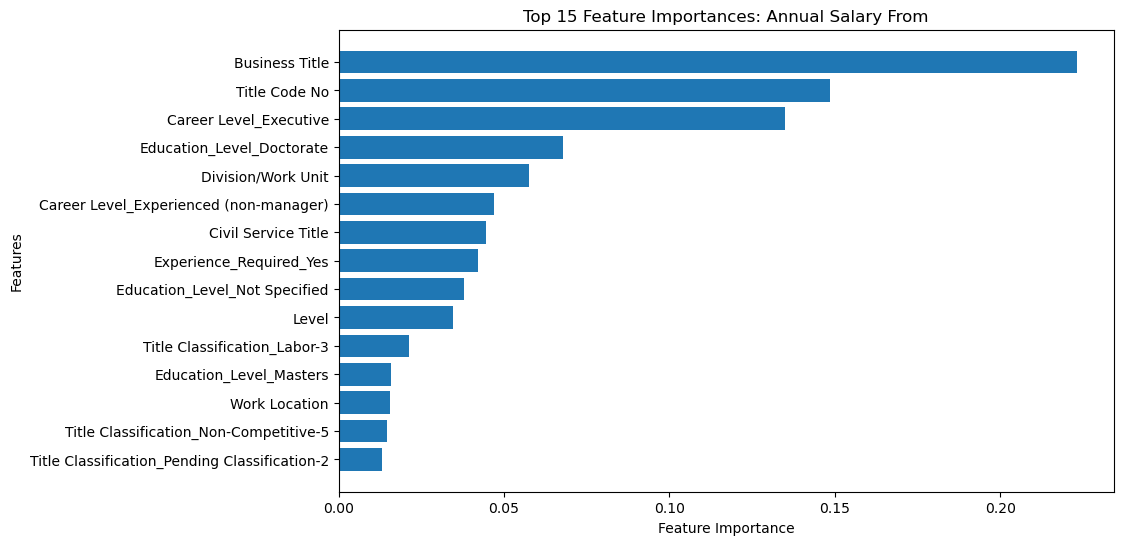

In [188]:
top_from = importance_from.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_from['Feature'],
    top_from['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances: Annual Salary From')

plt.gca().invert_yaxis()

plt.show()

## Feature Importance for Salary Range To

In [189]:
xgb_to_model = best_xgb_to.named_steps['model']

importance_to = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_to_model.feature_importances_
})

importance_to = importance_to.sort_values(
    by='Importance',
    ascending=False
)

importance_to.head(15)

,Feature,Importance
4,Title Code No,0.204155
2,Business Title,0.181868
18,Career Level_Executive,0.125872
5,Level,0.090829
26,Education_Level_Not Specified,0.065526
21,Career Level_Student,0.059609
3,Civil Service Title,0.040677
19,Career Level_Experienced (non-manager),0.026625
25,Education_Level_Masters,0.023577
12,Title Classification_Exempt-4,0.020071


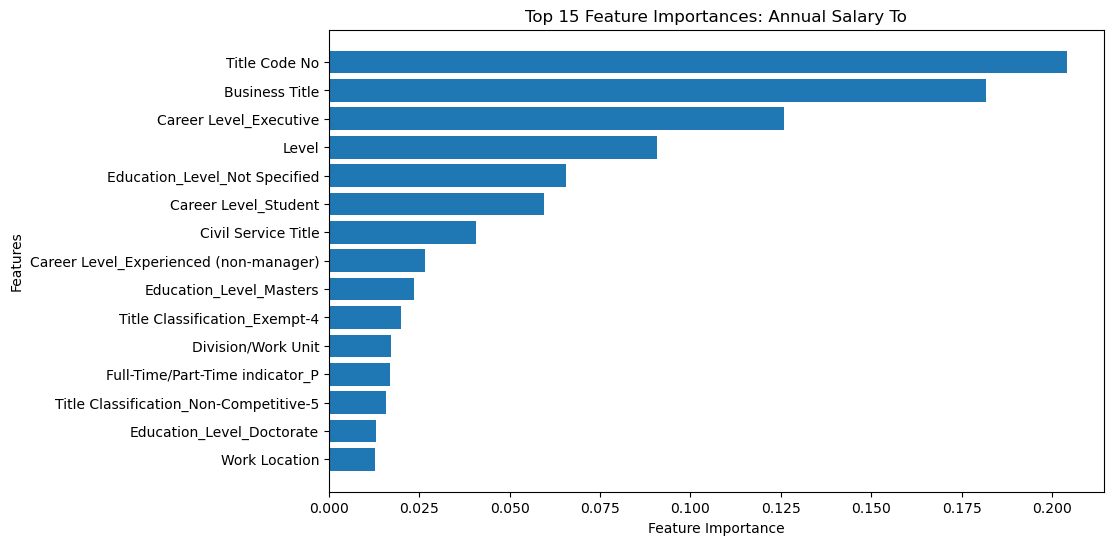

In [190]:
top_to = importance_to.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_to['Feature'],
    top_to['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances: Annual Salary To')

plt.gca().invert_yaxis()

plt.show()

In [191]:
# Get the fitted target encoder
encoder_from = best_xgb_from.named_steps['target_encoder']

# Transform the test data
X_test_from_encoded = encoder_from.transform(X_test)

# Get the trained XGBoost model
xgb_from_model = best_xgb_from.named_steps['model']

## Shap Analysis

In [192]:
explainer_from = shap.TreeExplainer(xgb_from_model)

shap_values_from = explainer_from.shap_values(X_test_from_encoded)

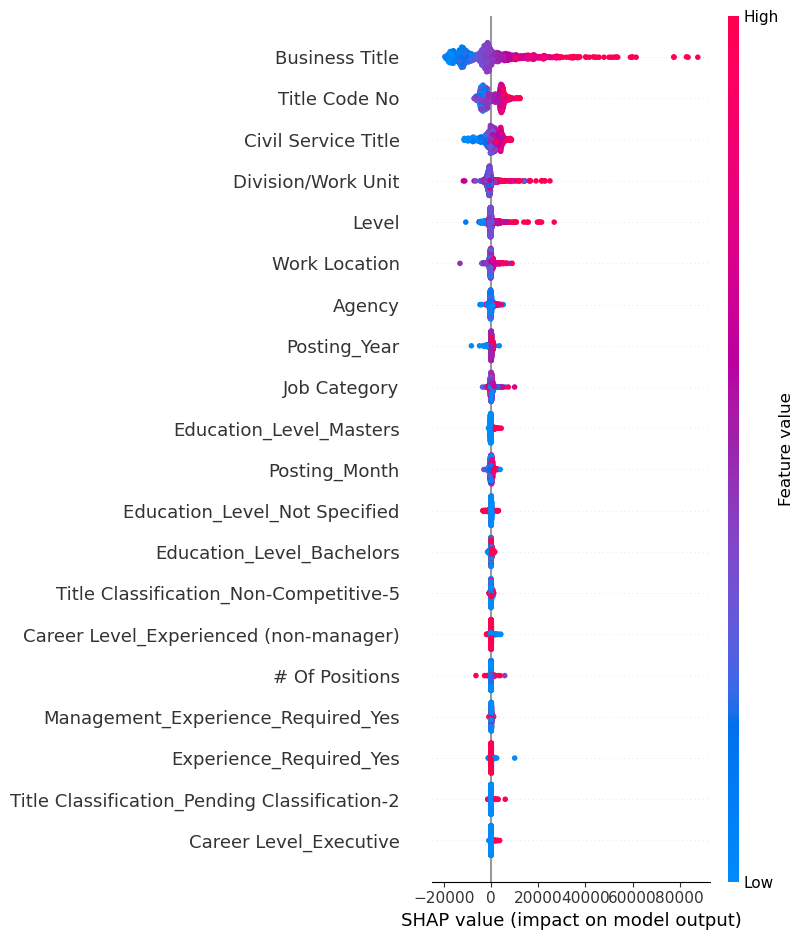

In [193]:
shap.summary_plot(
    shap_values_from,
    X_test_from_encoded,
    feature_names=X_test_from_encoded.columns
)

In [194]:
selected_features_from = [
    'Business Title',
    'Title Code No',
    'Civil Service Title',
    'Level',
    'Division/Work Unit',
    'Career Level_Executive',
    'Career Level_Experienced (non-manager)'
]

### Feature Selection for Minimun Salary Prediction

In [195]:
threshold_from = importance_from['Importance'].max() * 0.01

selected_features_from_threshold = importance_from[
    importance_from['Importance'] >= threshold_from
]['Feature'].tolist()

print("Threshold:", threshold_from)
print("Number of selected features:", len(selected_features_from_threshold))
print(selected_features_from_threshold)

Threshold: 0.0022312842309474947
Number of selected features: 27
['Business Title', 'Title Code No', 'Career Level_Executive', 'Education_Level_Doctorate', 'Division/Work Unit', 'Career Level_Experienced (non-manager)', 'Civil Service Title', 'Experience_Required_Yes', 'Education_Level_Not Specified', 'Level', 'Title Classification_Labor-3', 'Education_Level_Masters', 'Work Location', 'Title Classification_Non-Competitive-5', 'Title Classification_Pending Classification-2', 'Education_Level_Bachelors', 'Career Level_Manager', 'Job Category', 'Agency', 'Management_Experience_Required_Yes', 'Full-Time/Part-Time indicator_P', 'Title Classification_Exempt-4', 'Full-Time/Part-Time indicator_Not Specified', 'Posting_Year', '# Of Positions', 'Education_Level_High School', 'Posting_Month']


In [196]:
X_from_threshold = X_cv_from[
    selected_features_from_threshold
].copy()

In [197]:
high_card_threshold_from = X_from_threshold.select_dtypes(
    include='object'
).columns.tolist()

print(high_card_threshold_from)

['Business Title', 'Title Code No', 'Division/Work Unit', 'Civil Service Title', 'Level', 'Work Location', 'Job Category', 'Agency']


### Training Final Model on Selected Features for Minimum Salary

In [198]:
xgb_threshold_from = Pipeline([
    ('target_encoder', TargetEncoder(cols=high_card_threshold_from)),
    ('model', XGBRegressor(
        colsample_bytree=0.8,
        learning_rate=0.1,
        max_depth=7,
        n_estimators=300,
        subsample=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

In [199]:
# Evaluate the selected Salary From model using cross-validation
rmse_scores = cross_val_score(
    xgb_threshold_from,
    X_from_threshold,
    y_cv_from,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

r2_scores = cross_val_score(
    xgb_threshold_from,
    X_from_threshold,
    y_cv_from,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

print("Average RMSE:", -rmse_scores.mean())
print("RMSE Std:", rmse_scores.std())
print("Average R²:", r2_scores.mean())
print("R² Std:", r2_scores.std())

Average RMSE: 6654.332441929638
RMSE Std: 847.5194815185885
Average R²: 0.936297125450716
R² Std: 0.015993886541364147


In [200]:
X_from_threshold_train = X_from_threshold.loc[X_train.index]
X_from_threshold_test = X_from_threshold.loc[X_test.index]

# Fit the model on the training data
xgb_threshold_from.fit(
    X_from_threshold_train,
    y_from_train
)

# Make Predictions
y_pred_threshold_from = xgb_threshold_from.predict(
    X_from_threshold_test
)

# Evaluate the model performance using test data
mae_threshold_from = mean_absolute_error(
    y_from_test,
    y_pred_threshold_from
)

rmse_threshold_from = mean_squared_error(
    y_from_test,
    y_pred_threshold_from
) ** 0.5

r2_threshold_from = r2_score(
    y_from_test,
    y_pred_threshold_from
)

print("Threshold Model MAE:", mae_threshold_from)
print("Threshold Model RMSE:", rmse_threshold_from)
print("Threshold Model R²:", r2_threshold_from)

Threshold Model MAE: 2024.7274522937191
Threshold Model RMSE: 7356.439043038271
Threshold Model R²: 0.9204002356484012


### Feature Selection for Maximum Salary Prediction

In [201]:
threshold_to = importance_to['Importance'].max() * 0.01

selected_features_to_threshold = importance_to[
    importance_to['Importance'] >= threshold_to
]['Feature'].tolist()

print("Threshold:", threshold_to)
print("Number of selected features:", len(selected_features_to_threshold))
print(selected_features_to_threshold)

Threshold: 0.0020415453612804414
Number of selected features: 28
['Title Code No', 'Business Title', 'Career Level_Executive', 'Level', 'Education_Level_Not Specified', 'Career Level_Student', 'Civil Service Title', 'Career Level_Experienced (non-manager)', 'Education_Level_Masters', 'Title Classification_Exempt-4', 'Division/Work Unit', 'Full-Time/Part-Time indicator_P', 'Title Classification_Non-Competitive-5', 'Education_Level_Doctorate', 'Work Location', 'Education_Level_Bachelors', 'Education_Level_High School', 'Experience_Required_Yes', 'Career Level_Manager', 'Agency', 'Full-Time/Part-Time indicator_Not Specified', 'Posting_Year', 'Job Category', 'Title Classification_Pending Classification-2', 'Posting_Month', 'Management_Experience_Required_Yes', '# Of Positions', 'Title Classification_Labor-3']


In [202]:
X_to_threshold = X_cv[
    selected_features_to_threshold
].copy()

In [203]:
high_card_threshold_to = X_to_threshold.select_dtypes(
    include='object'
).columns.tolist()

print(high_card_threshold_to)

['Title Code No', 'Business Title', 'Level', 'Civil Service Title', 'Division/Work Unit', 'Work Location', 'Agency', 'Job Category']


## Training Final Model on Selected Features for Maximum Salary

In [204]:
# Define the tuned XGBoost pipeline for Salary To prediction
xgb_threshold_to = Pipeline([
    ('target_encoder', TargetEncoder(cols=high_card_threshold_to)),
    ('model', XGBRegressor(
        colsample_bytree=0.8,
        learning_rate=0.1,
        max_depth=7,
        n_estimators=300,
        subsample=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

In [205]:
# Evaluate the selected Salary To model using cross-validation
rmse_scores_to_threshold = cross_val_score(
    xgb_threshold_to,
    X_to_threshold,
    y_cv,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

r2_scores_to_threshold = cross_val_score(
    xgb_threshold_to,
    X_to_threshold,
    y_cv,
    cv=kf,
    scoring='r2',
    n_jobs=-1
)

print("Average RMSE:", -rmse_scores_to_threshold.mean())
print("RMSE Std:", rmse_scores_to_threshold.std())
print("Average R²:", r2_scores_to_threshold.mean())
print("R² Std:", r2_scores_to_threshold.std())

Average RMSE: 10517.594527174942
RMSE Std: 676.8372398268998
Average R²: 0.9300119849928296
R² Std: 0.007646576943815624


In [206]:
# Split the selected features into training and testing sets
X_to_threshold_train = X_to_threshold.loc[X_train.index]
X_to_threshold_test = X_to_threshold.loc[X_test.index]

# Fit the final model
xgb_threshold_to.fit(
    X_to_threshold_train,
    y_to_train
)

y_pred_threshold_to = xgb_threshold_to.predict(
    X_to_threshold_test
)

# Evaluate the model performance on test data
mae_threshold_to = mean_absolute_error(
    y_to_test,
    y_pred_threshold_to
)

rmse_threshold_to = mean_squared_error(
    y_to_test,
    y_pred_threshold_to
) ** 0.5

r2_threshold_to = r2_score(
    y_to_test,
    y_pred_threshold_to
)

print("Threshold Model MAE:", mae_threshold_to)
print("Threshold Model RMSE:", rmse_threshold_to)
print("Threshold Model R²:", r2_threshold_to)

Threshold Model MAE: 3743.355483405173
Threshold Model RMSE: 10706.915440778099
Threshold Model R²: 0.9267132288806097


## Actual vs Predicted for Maximum Salary

In [207]:
y_pred_final_to = y_pred_threshold_to

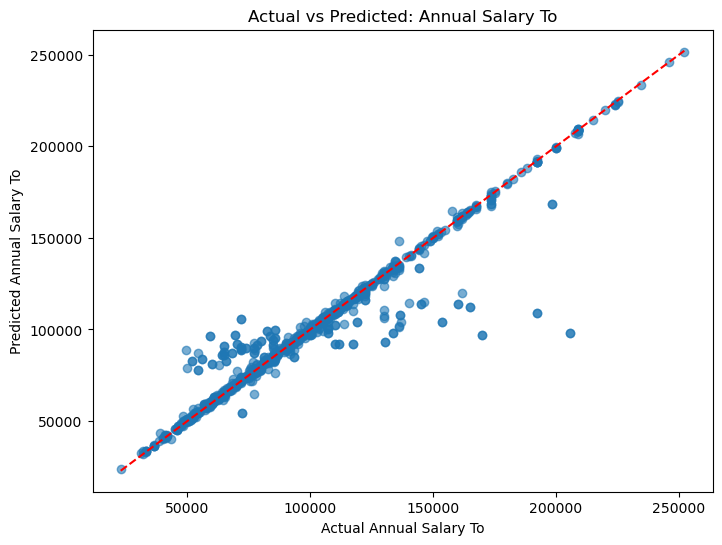

In [208]:
# Plot actual versus predicted maximum salary

plt.figure(figsize=(8, 6))

plt.scatter(
    y_to_test,
    y_pred_final_to,
    alpha=0.6
)

plt.xlabel('Actual Annual Salary To')
plt.ylabel('Predicted Annual Salary To')
plt.title('Actual vs Predicted: Annual Salary To')

plt.plot(
    [y_to_test.min(), y_to_test.max()],
    [y_to_test.min(), y_to_test.max()],
    color='red',
    linestyle='--'
)

plt.show()

## Residual Plot - Maximum Salary

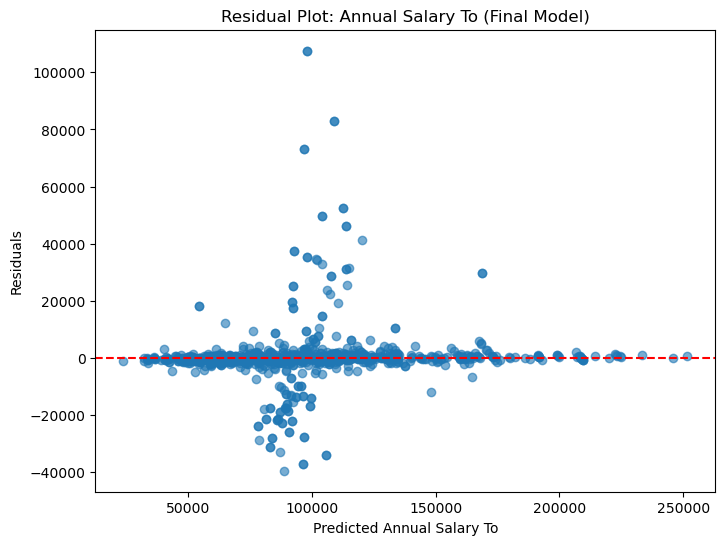

In [209]:
# Calculate residuals
residuals_final_to = y_to_test - y_pred_final_to

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_final_to,
    residuals_final_to,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel('Predicted Annual Salary To')
plt.ylabel('Residuals')
plt.title('Residual Plot: Annual Salary To (Final Model)')

plt.show()

## Actual Vs Predicted - Minimum Salary

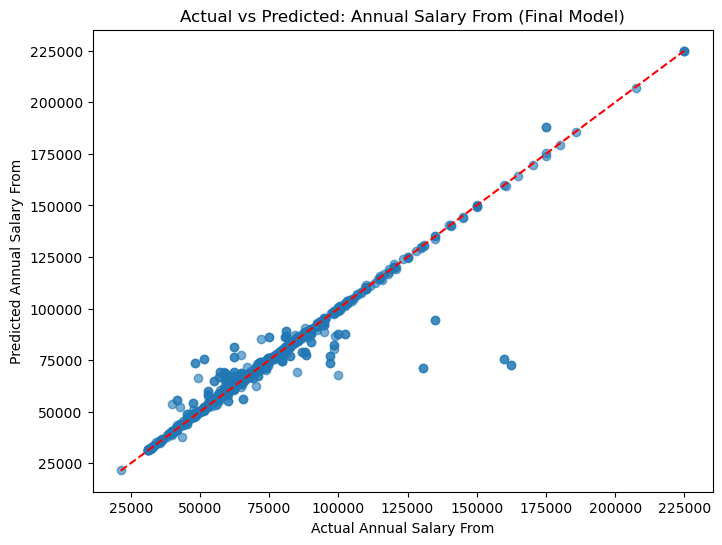

In [210]:
# Final predictions for Annual Salary From
y_pred_final_from = y_pred_threshold_from

plt.figure(figsize=(8, 6))

plt.scatter(
    y_from_test,
    y_pred_final_from,
    alpha=0.6
)

# Perfect prediction line
plt.plot(
    [y_from_test.min(), y_from_test.max()],
    [y_from_test.min(), y_from_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel('Actual Annual Salary From')
plt.ylabel('Predicted Annual Salary From')
plt.title('Actual vs Predicted: Annual Salary From (Final Model)')

plt.show()

## Residual Plot for Minimum Salary

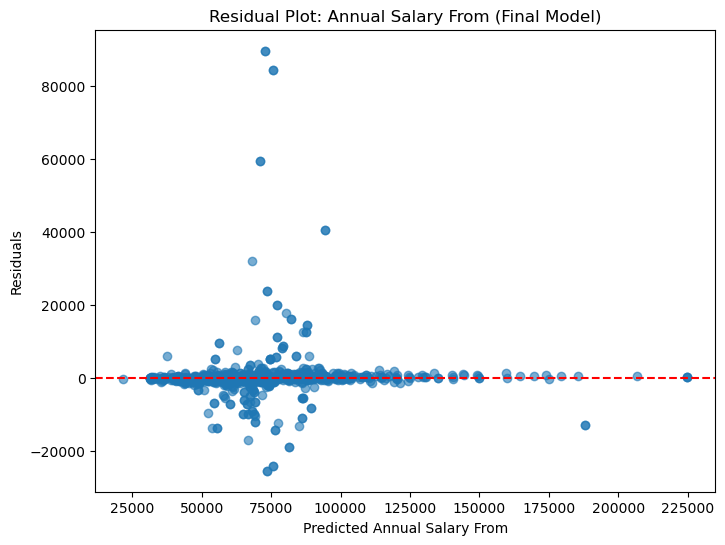

In [211]:
# Calculate residuals
residuals_final_from = y_from_test - y_pred_final_from

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_final_from,
    residuals_final_from,
    alpha=0.6
)

# Zero-residual reference line
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel('Predicted Annual Salary From')
plt.ylabel('Residuals')
plt.title('Residual Plot: Annual Salary From (Final Model)')

plt.show()

## Training Final Models on Complete data

In [212]:
# Train the final Salary From model on the complete dataset

categorical_cols = [
    'Business Title',
    'Title Code No',
    'Division/Work Unit',
    'Civil Service Title',
    'Level',
    'Work Location',
    'Job Category',
    'Agency'
]

final_model_from = Pipeline([
    ('target_encoder', TargetEncoder(cols=categorical_cols)),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    ))
])

final_model_from.fit(
    X[selected_features_from_threshold],
    y_from
)

,steps,"[('target_encoder', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,cols,"['Business Title', 'Title Code No', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20


In [213]:
# Train the final Salary To model on the complete dataset

final_model_to = Pipeline([
    ('target_encoder', TargetEncoder(cols=categorical_cols)),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=7,
        subsample=1.0,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    ))
])

final_model_to.fit(
    X[selected_features_to_threshold],
    y_to
)

,steps,"[('target_encoder', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,verbose,0
,cols,"['Business Title', 'Title Code No', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20
